In [1]:
import os

os.chdir("/mnt/lustre/home/nahnsen/nahfo470/mycode")
print("CWD set to:", os.getcwd())

CWD set to: /mnt/lustre/home/nahnsen/nahfo470/mycode


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# --- 1. Read the Excel sheet ---
data = pd.read_excel(
    "/mnt/lustre/home/nahnsen/nahfo470/mycode/Patient-List.xlsx",
    sheet_name="RNAseq_fpkm",
    engine="openpyxl"
)

In [4]:
# keep column names as-is
data.columns = data.columns.astype(str)

# --- 2. Filter samples (same list used in R) ---
Sample_names = [
  "Sample","X-0933","X-1027","X-1095","X-1119","X-1167","X-1173","X-1210","X-1234","X-1256",
  "X-1270","X-1290","X-1303","X-1329","X-1441","X-1443","X-1479","X-1480","X-1493",
  "X-1500","X-1536","X-1538","X-1855","X-1867","X-2145","X-2182","X-2239","X-2374",
  "X-2403","X-2483","X-2484","X-2514","X-2538","X-2573","X-2659","X-2697","X-2742","X-2761","X-2803",
  "X-2822","X-2846","X-2861","X-2991","X-3019","X-3093","X-3135","X-3196","X-3205",
  "X-3224","X-3239","X-3267","X-3570","X-3671","X-3684","X-3765","X-3792","X-4087","X-4454",
  "X-4484","X-5238","X-5254","X-5405","X-5421","X-5438","X-5441","X-5446","X-5494",
  "X-5495","X-5563","X-5578","X-5594"
]

In [5]:
# sanity check: which requested samples actually exist?
existing = [c for c in Sample_names if c in data.columns]
missing  = [c for c in Sample_names if c not in data.columns]

print("Requested samples:", len(Sample_names))
print("Existing in sheet:", len(existing))
print("Missing from sheet:", missing)


Requested samples: 71
Existing in sheet: 69
Missing from sheet: ['X-0933', 'X-2803']


Shape of X: (68, 22665)
Samples (rows): ['X-1027', 'X-1095', 'X-1119']
Genes (cols): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2LD1', 'A2M']
            A1BG  A1BG-AS1      A1CF     A2LD1       A2M     A2ML1
X-1027  0.189034  0.000000  1.201634  2.897240  0.000000  0.000000
X-1095  0.176323  0.000000  1.937344  2.570463  2.229588  0.056584
X-1119  0.111031  0.000000  1.952334  3.593354  0.000000  0.014355
X-1167  0.238787  0.000000  2.140779  2.097611  0.000000  0.124328
X-1173  0.000000  0.000000  1.985500  3.017922  0.028569  0.137504
X-1210  3.012569  2.077243  0.056584  2.482848  0.000000  0.000000


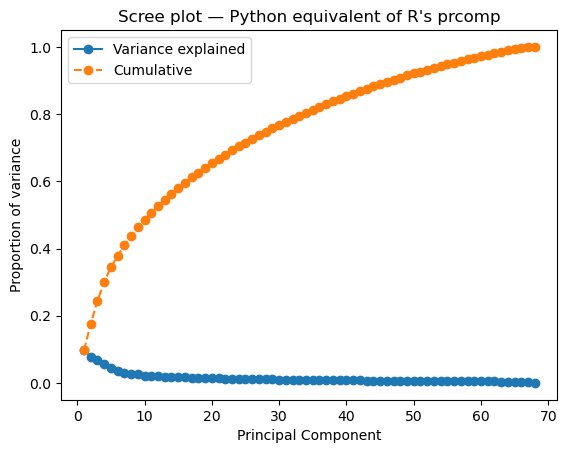

In [6]:
# Keep only those sample columns that exist in the sheet
existing = [col for col in Sample_names if col in data.columns]
filtered = data.loc[:, existing]

# --- 3. Identify gene column ---
GENE_COL = filtered.columns[0]
num_cols = [c for c in filtered.columns if c != GENE_COL]

# --- 4. Log2 transform ---
log_df = filtered.copy()
log_df[num_cols] = np.log2(log_df[num_cols] + 1)


# --- 5. Transpose to (samples × genes) ---
genes = log_df[GENE_COL].astype(str).values
num = log_df[num_cols].to_numpy(dtype=float)
X = num.T  # transpose so rows = samples, cols = genes

X = pd.DataFrame(X, index=num_cols, columns=genes)

print("Shape of X:", X.shape)
print("Samples (rows):", X.index[:3].tolist())
print("Genes (cols):", X.columns[:5].tolist())
print(X.iloc[:6, :6])  # first 6x6 block

# --- 6. Drop zero-variance genes ---
keep = X.var(axis=0, ddof=1) > 0
Xv = X.loc[:, keep]

# --- 7. PCA (center + scale per gene) ---
mu = Xv.mean(axis=0)
sd = Xv.std(axis=0, ddof=1)
Xs = (Xv - mu) / sd

U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
scores = U * S
rotation = Vt.T
sdev = S / np.sqrt(Xs.shape[0] - 1)

pc_names = [f"PC{i+1}" for i in range(rotation.shape[1])]
scores_df = pd.DataFrame(scores, index=Xv.index, columns=pc_names)
rotation_df = pd.DataFrame(rotation, index=Xv.columns, columns=pc_names)
sdev_series = pd.Series(sdev, index=pc_names, name="sdev")

# --- 8. Variance explained ---
var_expl = (sdev_series**2) / (sdev_series**2).sum()
cum_expl = var_expl.cumsum()

# --- 9. Scree plot (same as R) ---
plt.figure()
plt.plot(range(1, len(var_expl)+1), var_expl.values, marker='o', label="Variance explained")
plt.plot(range(1, len(cum_expl)+1), cum_expl.values, marker='o', linestyle='--', label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of variance")
plt.title("Scree plot — Python equivalent of R's prcomp")
plt.legend()
plt.show()


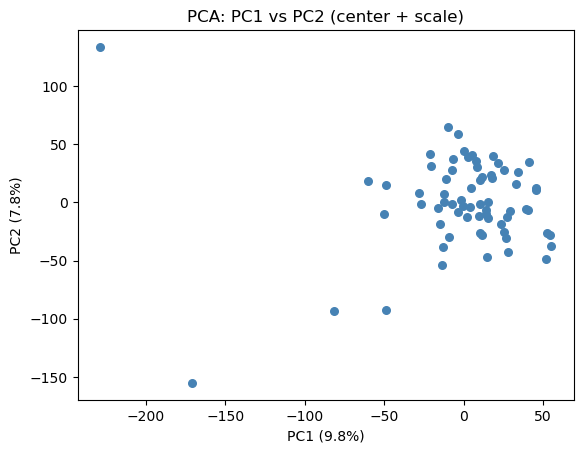

In [7]:
# --- 10. PC1 vs PC2 plot ---
plt.figure()
plt.scatter(scores_df["PC1"], scores_df["PC2"], c='steelblue', s=30)
plt.xlabel(f"PC1 ({var_expl['PC1']*100:.1f}%)")
plt.ylabel(f"PC2 ({var_expl['PC2']*100:.1f}%)")
plt.title("PCA: PC1 vs PC2 (center + scale)")
plt.show()


In [8]:
# --- helper: normalize IDs like in R's norm_id() ---
def norm_id(s):
    s = pd.Series(s, dtype=str).str.strip().str.upper()
    s = s.str.replace(r"[._ ]", "-", regex=True)
    s = s.str.replace(r"-+", "-", regex=True)

    return s

# --- read the categories sheet (PCT curve metrics) ---
pct = pd.read_excel(
    "/mnt/lustre/home/nahnsen/nahfo470/mycode/Patient-List.xlsx",
    sheet_name="PCT curve metrics",
    engine="openpyxl"
)

# --- requested IDs =  Sample_names minus literal "Sample" ---
requested = [s for s in Sample_names if s != "Sample"]

# standardize both sets the same way
req_std   = norm_id(requested)
model_std = norm_id(pct["Model"])

# --- counts / diagnostics (matches your R prints) ---
matched_count = (req_std.isin(model_std)).sum()
print(f"PCT curve metrics — matched: {matched_count} of {len(req_std)}")
missing_in_model = req_std[~req_std.isin(model_std)].tolist()
print("Missing in Model (from your list):", missing_in_model)

# --- 51 IDs = intersection of requested ∩ Model ---
keep_ids = pd.Index(np.intersect1d(req_std.values, model_std.values))
print("keep_ids (n):", len(keep_ids))

PCT curve metrics — matched: 51 of 70
Missing in Model (from your list): ['X-1095', 'X-1480', 'X-1493', 'X-1867', 'X-2697', 'X-2742', 'X-2803', 'X-2991', 'X-3019', 'X-3135', 'X-3196', 'X-3239', 'X-3570', 'X-3765', 'X-4454', 'X-4484', 'X-5441', 'X-5563', 'X-5594']
keep_ids (n): 51


In [9]:

# 0) Ensure prerequisites exist
try:
    X  # DataFrame rows=samples, cols=genes
    keep_ids  # Index/Series of the 51 normalized IDs i want to keep
except NameError as e:
    raise RuntimeError("You must define X and keep_ids before subsetting.") from e

# 2) Normalize both sides
row_ids_norm = norm_id(X.index)
keep_ids_norm = pd.Index(norm_id(keep_ids))

# 3) Diagnostics
print(f"Intended keep_ids: {len(keep_ids_norm)}")
print(f"Unique normalized X rows: {row_ids_norm.nunique()}")




Intended keep_ids: 51
Unique normalized X rows: 68


In [10]:

missing_from_X = keep_ids_norm.difference(pd.Index(row_ids_norm.unique()))
if len(missing_from_X):
    print("⚠️ IDs present in keep_ids but NOT found in X (after normalization):")
    print(list(missing_from_X[:20]))

dups_in_X = row_ids_norm[row_ids_norm.duplicated(keep="first")]
if len(dups_in_X):
    print("⚠️ Duplicated normalized IDs in X (keeping first occurrence):",
          dups_in_X.unique().tolist())

# 4) Build a mapping normalized_id -> original X index (first occurrence kept)
idx_map = pd.Series(X.index, index=row_ids_norm).groupby(level=0).first()

# 5) Select rows in the order of keep_ids; drop missing
selected = idx_map.reindex(keep_ids_norm).dropna()

print(f"Matched rows: {len(selected)} / {len(keep_ids_norm)}")
if len(selected) != len(keep_ids_norm):
    still_missing = keep_ids_norm.difference(selected.index)
    if len(still_missing):
        print("❗Still missing after mapping:", list(still_missing[:20]))

# 6) Subset to X51 (ordered)
X51 = X.loc[selected.values].copy()
print("✅ X51 shape:", X51.shape)

⚠️ IDs present in keep_ids but NOT found in X (after normalization):
['X-0933']
Matched rows: 50 / 51
❗Still missing after mapping: ['X-0933']
✅ X51 shape: (50, 22665)


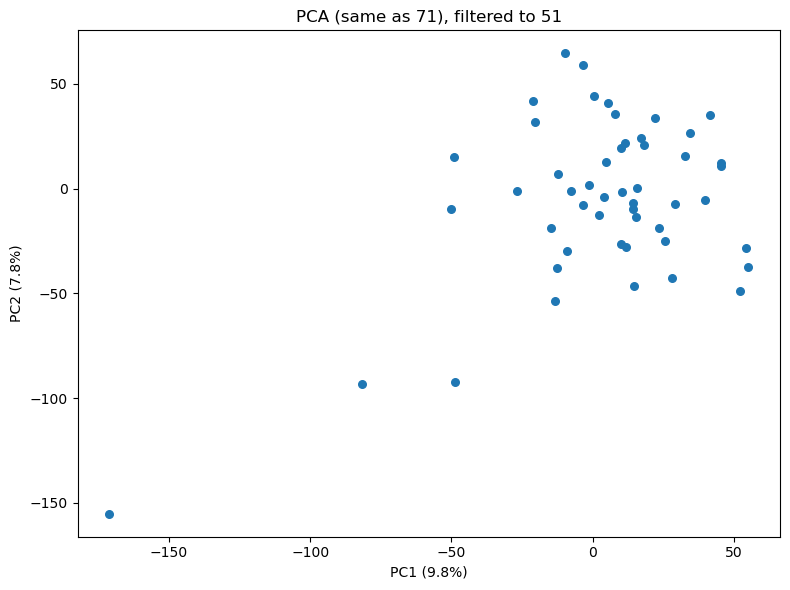

In [11]:
# scores_df: from your SVD on Xv (the 71), shape (71 x PCs), index = sample IDs
# selected: the Series you built mapping keep_ids -> original X index (used for X51)
scores_51 = scores_df.loc[selected.values, ["PC1", "PC2"]].copy()

# plot (identical axes/orientation as the 71 PCA, just fewer points)
plt.figure(figsize=(8,6))
plt.scatter(scores_51["PC1"], scores_51["PC2"], s=30)
plt.xlabel(f"PC1 ({(sdev_series**2/(sdev_series**2).sum())['PC1']*100:.1f}%)")
plt.ylabel(f"PC2 ({(sdev_series**2/(sdev_series**2).sum())['PC2']*100:.1f}%)")
plt.title("PCA (same as 71), filtered to 51")
plt.tight_layout()
plt.show()


In [12]:
# ------------------ INPUTS ------------------
VST30_PATH = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/deseq2_vst.tsv"
ENSEMBL_TO_SYMBOL = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/ensembl_to_symbol.tsv"
OUT_DIR = "/mnt/lustre/home/nahnsen/nahfo470/mycode"

assert isinstance(Xv, pd.DataFrame), "Xv must be samples × genes (FPKM70)."

In [13]:
# ------------------ 1) Load DESeq2 VST (genes x samples, Ensembl rows) ------------------
mat_deseq = pd.read_csv(VST30_PATH, sep=None, engine="python", index_col=0)

# strip Ensembl versions (e.g., ENSG000001.12 -> ENSG000001)
ens = mat_deseq.index.to_series().str.replace(r"\.\d+$", "", regex=True)

# Ensembl -> SYMBOL map
map_df = pd.read_csv(ENSEMBL_TO_SYMBOL, sep="\t")
map_df.columns = [c.upper() for c in map_df.columns]
sym_map = map_df.dropna().drop_duplicates().set_index("ENSEMBL")["SYMBOL"].astype(str)

# map to symbols (keep missing as NA, not "nan")
sym = ens.map(sym_map)
sym = sym.astype("string").str.strip().str.upper()

# replace Ensembl index with SYMBOL, drop missing/empty, collapse duplicates
mat_sym = mat_deseq.copy()
mat_sym.index = sym
mat_sym = mat_sym[mat_sym.index.notna() & (mat_sym.index.str.len() > 0)]
mat_sym = mat_sym.groupby(mat_sym.index).mean(numeric_only=True)

In [14]:
# 2) Align to PCA genes and restrict
genes_in_pca = pd.Index(Xv.columns)  # Xv:  70 FPKM matrix (samples x genes, log2+1, zero-var removed)
genes_use = genes_in_pca.intersection(mat_sym.index)
print("Genes used for projection:", len(genes_use))
if len(genes_use) <= 500:
    raise RuntimeError(f"Too few overlapping genes: {len(genes_use)}")

# reorder to PCA gene order, transpose to samples x genes

genes_ordered = genes_in_pca.intersection(mat_sym.index)  # already in PCA order
Y_new = mat_sym.loc[genes_ordered].T
Xv_restrict = Xv.loc[:, genes_ordered]



Genes used for projection: 17029


In [15]:
# 3) prcomp(center=TRUE, scale.=TRUE) on restricted 70
def prcomp_like(M: pd.DataFrame):
    mu = M.mean(axis=0)
    sd = M.std(axis=0, ddof=1).replace(0, np.nan).fillna(1.0)
    Z  = (M - mu) / sd
    U, S, Vt = np.linalg.svd(Z.values, full_matrices=False)
    scores   = pd.DataFrame(U * S, index=M.index)
    rotation = pd.DataFrame(Vt.T, index=M.columns)
    sdev     = S / np.sqrt(max(Z.shape[0]-1, 1))
    return scores, rotation, sdev, mu, sd

scores_train, rotation_fit, sdev_fit, mu_fit, sd_fit = prcomp_like(Xv_restrict)
scores_train.index.name = "sample"
# name PCs
pc_names = [f"PC{i+1}" for i in range(rotation_fit.shape[1])]
scores_train.columns = pc_names
rotation_fit.columns = pc_names

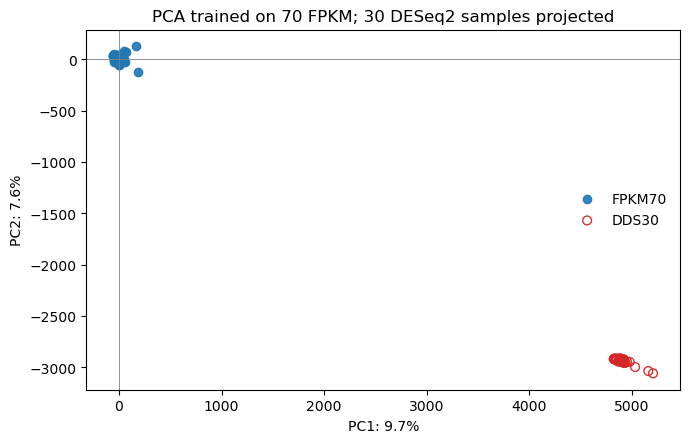

Saved CSV + figures in: /mnt/lustre/home/nahnsen/nahfo470/mycode


In [16]:

# 4) Project the 30 into this PCA (predict)
Y_std = (Y_new - mu_fit) / sd_fit.replace(0, 1.0)
scores_new = pd.DataFrame(Y_std.values @ rotation_fit.values,
                          index=Y_new.index, columns=pc_names)

# Combine first two PCs for plotting
train = scores_train.iloc[:, :2].copy()
new   = scores_new.iloc[:, :2].copy()
train["set"] = "FPKM70"
new["set"]   = "DDS30"
scores_all = pd.concat([train.assign(sample=train.index),
                        new.assign(sample=new.index)], axis=0)

var_exp = (sdev_fit**2) / (sdev_fit**2).sum()
vx1, vx2 = var_exp[0]*100, var_exp[1]*100


# Plot
plt.figure(figsize=(7,6))
plt.scatter(train["PC1"], train["PC2"], s=36, label="FPKM70", alpha=0.9)
plt.scatter(new["PC1"],   new["PC2"],   s=40, facecolors="none", edgecolors="tab:red", label="DDS30", alpha=0.95)
plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(f"PC1: {vx1:.1f}%"); plt.ylabel(f"PC2: {vx2:.1f}%")
plt.title("PCA trained on 70 FPKM; 30 DESeq2 samples projected")
plt.legend(frameon=False)
plt.tight_layout()

# Save like in R (SAVE BEFORE SHOW)
plt.savefig(f"{OUT_DIR}/PCA_train70_project30.pdf")
plt.savefig(f"{OUT_DIR}/PCA_train70_project30.jpg", dpi=300)

plt.show()
plt.close()

scores_all.to_csv(f"{OUT_DIR}/PCA_train70_project30_scores.csv", index=False)
print("Saved CSV + figures in:", OUT_DIR)

In [17]:
# ---------- A) Build gene lengths from GTF (sum of NON-overlapping exon lengths per gene) ----------
GTF_PATH = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/ensembl_GRCh38_v114/Homo_sapiens.GRCh38.114.gtf"
OUT_LEN  = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/gene_lengths_from_gtf.tsv"


# Read minimal GTF columns
gtf = pd.read_csv(
    GTF_PATH, sep="\t", comment="#", header=None,
    names=["chrom","source","feature","start","end","score","strand","frame","attr"],
    usecols=["feature","start","end","attr"]
)


In [18]:
# keep exons
gtf = gtf[gtf["feature"]=="exon"].copy()

def pull(tag, s):
    m = re.search(fr'{tag} "([^"]+)"', s)
    return m.group(1) if m else None

# extract Ensembl gene_id (strip version)
gene_id = gtf["attr"].apply(lambda s: pull("gene_id", s))
gene_id = gene_id.str.replace(r"\.\d+$", "", regex=True)
gtf = gtf.assign(gene_id=gene_id, start=gtf["start"].astype(int), end=gtf["end"].astype(int))
gtf = gtf.dropna(subset=["gene_id"])

# merge overlapping exon intervals per gene and sum
def merged_length(df):
    ivals = df[["start","end"]].sort_values("start").to_numpy()
    total = 0
    cur_s, cur_e = None, None
    for s,e in ivals:
        if cur_s is None:
            cur_s, cur_e = s, e
        elif s <= cur_e + 1:            # overlap/adjacent → extend
            cur_e = max(cur_e, e)
        else:                       # disjoint → commit previous, start new
            total += (cur_e - cur_s + 1)
            cur_s, cur_e = s, e
    if cur_s is not None:
        total += (cur_e - cur_s + 1)
    return total

gene_lengths = (
    gtf.groupby("gene_id", sort=False)
       .apply(merged_length)
       .reset_index(name="length")
)

print(f"Gene lengths computed for: {len(gene_lengths)} genes")
print(gene_lengths["length"].describe())

# save
os.makedirs(os.path.dirname(OUT_LEN), exist_ok=True)
gene_lengths.to_csv(OUT_LEN, sep="\t", index=False)
print("Saved:", OUT_LEN)

Gene lengths computed for: 78894 genes
count     78894.000000
mean       2483.186922
std        3938.413040
min           8.000000
25%         469.250000
50%        1052.000000
75%        3043.750000
max      348398.000000
Name: length, dtype: float64
Saved: /mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/gene_lengths_from_gtf.tsv


/tmp/ipykernel_384911/3464662104.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(merged_length)


In [19]:
# ---------- B) Compute FPKM for 30 patients from merged counts ----------
counts_path  = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/salmon.merged.gene_counts_newid.tsv"
lengths_path = OUT_LEN
out_fpkm     = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/fpkm_30patients.tsv"

# Read counts and lengths
counts30     = pd.read_csv(counts_path, sep="\t")
gene_lengths = pd.read_csv(lengths_path, sep="\t")

print("Counts columns (first 6):", counts30.columns[:6].tolist())
print("Lengths columns:", gene_lengths.columns.tolist())
print(f"Counts: {counts30.shape[0]} genes x {counts30.shape[1]-2} samples (expected first cols: gene_id, gene_name)")
print(f"Lengths: {gene_lengths.shape[0]} genes")


Counts columns (first 6): ['gene_id', 'gene_name', 'sample1', 'sample2', 'sample3', 'sample4']
Lengths columns: ['gene_id', 'length']
Counts: 78894 genes x 35 samples (expected first cols: gene_id, gene_name)
Lengths: 78894 genes


In [20]:
# Merge on gene_id
m = counts30.merge(gene_lengths, on="gene_id", how="inner")
print("Genes after merge:", m.shape[0])

# Identify sample columns (everything except gene_id, gene_name, length)
sample_cols = [c for c in m.columns if c not in ("gene_id","gene_name","length")]

# Library sizes per sample
lib_sizes = m[sample_cols].sum(axis=0, skipna=True)
print("Samples:", len(lib_sizes))
print(lib_sizes.head())

# CPM then FPKM
cpm = m[sample_cols].div(lib_sizes / 1e6, axis=1)
fpkm_mat = cpm.div(m["length"] / 1000, axis=0)

# Reattach identifiers and write
fpkm = pd.concat(
    [m[["gene_id","gene_name"]].reset_index(drop=True), fpkm_mat.reset_index(drop=True)],
    axis=1
)
fpkm.to_csv(out_fpkm, sep="\t", index=False)
print("Saved FPKM to:", out_fpkm)

# Tiny preview
preview_cols = ["gene_id","gene_name"] + sample_cols[:3]
print(fpkm.loc[:4, preview_cols])


Genes after merge: 78894
Samples: 35
sample1    2.507394e+06
sample2    6.124524e+06
sample3    7.748996e+06
sample4    1.128049e+07
sample5    4.809542e+06
dtype: float64
Saved FPKM to: /mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/fpkm_30patients.tsv
           gene_id gene_name    sample1    sample2    sample3
0  ENSG00000000003    TSPAN6  35.832212  21.157656  22.448255
1  ENSG00000000005      TNMD   1.080814   0.000000   0.349726
2  ENSG00000000419      DPM1   7.137192  13.166444   7.053425
3  ENSG00000000457     SCYL3   3.128912   4.127615   3.506052
4  ENSG00000000460     FIRRM   3.072988   5.333201   3.847713


In [21]:

# --- 1) Path ---
fpkm_path = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/fpkm_30patients.tsv"

# --- 2) Read the 30-patient FPKM ---
fpkm30 = pd.read_csv(fpkm_path, sep="\t")
# keep column names as-is
fpkm30.columns = fpkm30.columns.astype(str)

fpkm30 = fpkm30.dropna(subset=["gene_name"])
fpkm30 = fpkm30[fpkm30["gene_name"].astype(str).str.strip() != ""]

# --- 3) Identify sample columns ---
sample_cols = [c for c in fpkm30.columns if c not in ("gene_id","gene_name")]
print("Detected samples:", len(sample_cols))
print("First few sample cols:", sample_cols[:8])

# --- 4) Aggregate by gene_name (mean across duplicates) ---
dup_syms = fpkm30["gene_name"].duplicated().sum()
print("Duplicate gene symbols to aggregate:", dup_syms)

# group by gene_name and take mean of sample columns
fpkm_by_symbol = (
    fpkm30[["gene_name"] + sample_cols]
    .groupby("gene_name", as_index=False)
    .mean(numeric_only=True)
)

# --- 5) Build samples × genes matrix (transpose) ---
Y = fpkm_by_symbol.set_index("gene_name").T  # samples x genes
Y.index.name = None  # row names are sample IDs already
Y = Y.apply(pd.to_numeric, errors="coerce")
print("Matrix dims (samples x genes):", Y.shape)
print("Example genes:", list(Y.columns[:10]))
print("Example samples:", list(Y.index[:5]))

# --- 6) Log2 transform to match 70-sample PCA preprocessing ---
Y_log = np.log2(Y + 1)

# --- 7) Quick QC ---
print("Any NA in Y_log? ", np.isnan(Y_log.values).sum())
print("Range of Y_log values:", float(np.nanmin(Y_log.values)), "to", float(np.nanmax(Y_log.values)))


Detected samples: 35
First few sample cols: ['sample1', 'sample2', 'sample3', 'sample4', 'sample5', 'sample6', 'sample7', 'sample8']
Duplicate gene symbols to aggregate: 1628
Matrix dims (samples x genes): (35, 77266)
Example genes: ['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2ML1-AS1']
Example samples: ['sample1', 'sample2', 'sample3', 'sample4', 'sample5']
Any NA in Y_log?  0
Range of Y_log values: 0.0 to 17.63667651321674


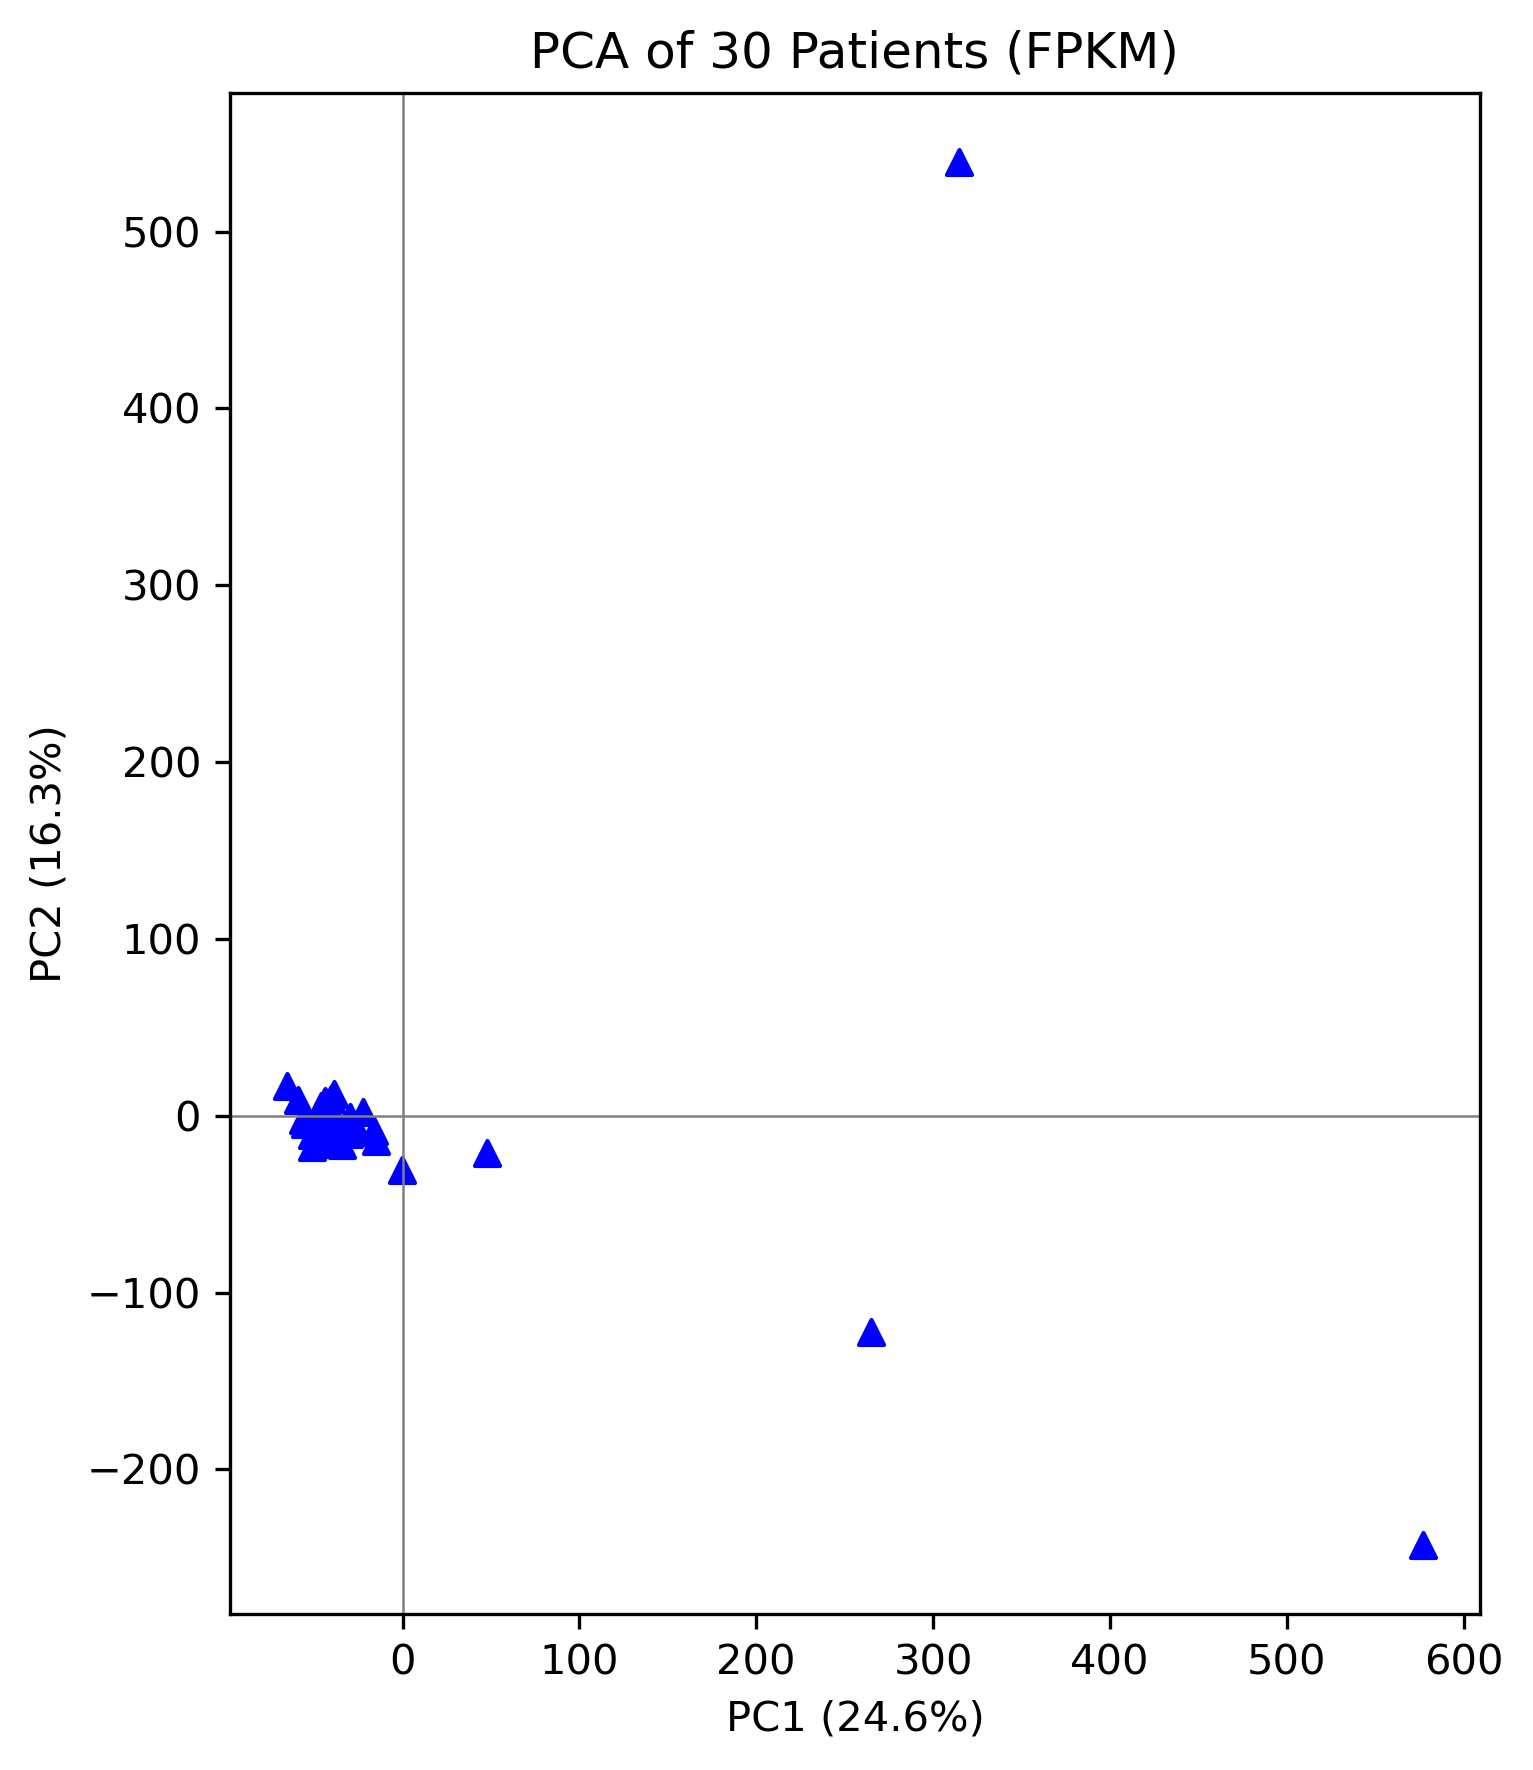

Saved: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_30patients.jpg


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1) Drop zero-variance genes (columns) ---
# Y_log is samples × genes (from the previous step)
keep = (pd.DataFrame(Y_log).var(axis=0, ddof=1) > 0)
Yv = pd.DataFrame(Y_log).loc[:, keep].copy()

# --- 2) PCA (center + scale per gene, like prcomp(center=TRUE, scale.=TRUE)) ---
scaler = StandardScaler(with_mean=True, with_std=True)
Z = scaler.fit_transform(Yv)        # standardize columns
pca30 = PCA()                       # full PCA
scores30 = pca30.fit_transform(Z)   # samples × PCs

# variance explained
var_ratio = pca30.explained_variance_ratio_
pc1_pct = var_ratio[0] * 100.0
pc2_pct = var_ratio[1] * 100.0


# --- 3) Plot + save in one go ---
out_jpg = "/mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_30patients.jpg"

plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(scores30[:, 0], scores30[:, 1], marker="^", color="blue")
plt.xlabel(f"PC1 ({pc1_pct:.1f}%)")
plt.ylabel(f"PC2 ({pc2_pct:.1f}%)")
plt.title("PCA of 30 Patients (FPKM)")
plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()

plt.savefig(out_jpg, dpi=300)
plt.show()
plt.close()
print("Saved:", out_jpg)

In [23]:
# 1) Common genes
genes51 = pd.Index(X51.columns)
common_genes = pd.Index(Y_log.columns).intersection(genes51)
if len(common_genes) <= 500:
    raise ValueError(f"Too few common genes ({len(common_genes)}).")

# 2) Align X51 and Y30 to same genes (and same order!)
common_genes = genes51.intersection(common_genes)  # keeps PCA gene order
X51c = X51.loc[:, common_genes].copy()
Y30c = pd.DataFrame(Y_log, copy=True).loc[:, common_genes].copy()

# 3) Fit PCA(51) ONLY on common genes
mu_51 = X51c.mean(axis=0)
sd_51 = X51c.std(axis=0, ddof=1).replace(0, np.nan).fillna(1.0)

Z51 = (X51c - mu_51) / sd_51
U, S, Vt = np.linalg.svd(Z51.values, full_matrices=False)

pc_names = [f"PC{i+1}" for i in range(Vt.shape[0])]
rotation_51 = pd.DataFrame(Vt.T, index=common_genes, columns=pc_names)

# 4) Project Y30
Y30_scaled = (Y30c - mu_51) / sd_51
Y30_proj = pd.DataFrame(
    Y30_scaled.values @ rotation_51.values,
    index=Y30_scaled.index,
    columns=pc_names
)

print("Projected 30 samples (first 5 rows, PC1–PC2):")
print(Y30_proj.iloc[:5, :2])

Projected 30 samples (first 5 rows, PC1–PC2):
                PC1        PC2
sample1  172.923918 -40.724830
sample2  160.393524 -49.775262
sample3  192.940886 -57.959374
sample4  199.880395 -41.272645
sample5  214.998030 -25.631434


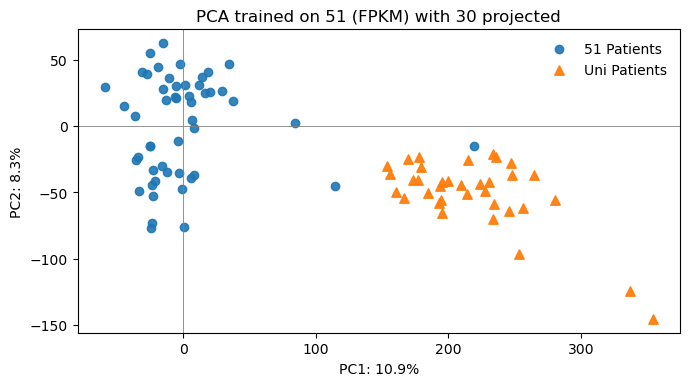

✅ Saved figure + scores to: /mnt/lustre/home/nahnsen/nahfo470/mycode


In [24]:
# --- 0) Ensure : explained-variance for PCA(51) ---
try:
    var_exp51  # already exists
except NameError:
    # Recompute from the PCA(51) trained on common_genes (X51c)
    Z51 = (X51c - mu_51) / sd_51
    U, S, Vt = np.linalg.svd(Z51.values, full_matrices=False)
    sdev_51 = S / np.sqrt(max(Z51.shape[0] - 1, 1))
    var_exp51 = (sdev_51**2) / (sdev_51**2).sum()

# --- 1) Scores for the 51 training samples (PC1–PC2) ---
# scores = (X - center)/scale  @ rotation   
scores51_full = ((X51c - mu_51) / sd_51) @ rotation_51
scores51 = scores51_full.iloc[:, :2].copy()
scores51.columns = ["PC1", "PC2"]
scores51["sample"] = scores51.index
scores51["set"] = "51 Patients"

# --- 2) Scores for the 30 projected samples (PC1–PC2) ---
scores30 = Y30_proj.iloc[:, :2].copy()
scores30.columns = ["PC1", "PC2"]
scores30["sample"] = scores30.index
scores30["set"] = "Uni Patients"

# --- 3) Combine for plotting ---
scores_all = pd.concat([
    scores51.loc[:, ["sample","PC1","PC2","set"]],
    scores30.loc[:, ["sample","PC1","PC2","set"]],
], axis=0, ignore_index=True)

# --- 4) Plot (51=circles, 30=triangles)
plt.figure(figsize=(7,6))

mask_51  = scores_all["set"] == "51 Patients"
mask_uni = scores_all["set"] == "Uni Patients"

plt.scatter(scores_all.loc[mask_51,  "PC1"],
            scores_all.loc[mask_51,  "PC2"],
            s=36, alpha=0.9, label="51 Patients", marker="o")

plt.scatter(scores_all.loc[mask_uni, "PC1"],
            scores_all.loc[mask_uni, "PC2"],
            s=46, alpha=0.95, label="Uni Patients", marker="^")

plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)
plt.gca().set_aspect('equal', adjustable='box')
pc1_pct = float(var_exp51[0] * 100.0)
pc2_pct = float(var_exp51[1] * 100.0)
plt.xlabel(f"PC1: {pc1_pct:.1f}%")
plt.ylabel(f"PC2: {pc2_pct:.1f}%")
plt.title("PCA trained on 51 (FPKM) with 30 projected")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# --- 5) Save figure + coordinates ---
out_dir = "/mnt/lustre/home/nahnsen/nahfo470/mycode"
os.makedirs(out_dir, exist_ok=True)

plt.figure(figsize=(7,6))
plt.scatter(scores_all.loc[mask_51,  "PC1"], scores_all.loc[mask_51,  "PC2"],
            s=36, alpha=0.9, label="51 Patients", marker="o")
plt.scatter(scores_all.loc[mask_uni, "PC1"], scores_all.loc[mask_uni, "PC2"],
            s=46, alpha=0.95, label="Uni Patients", marker="^")
plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(f"PC1: {pc1_pct:.1f}%"); plt.ylabel(f"PC2: {pc2_pct:.1f}%")
plt.title("PCA trained on 51 (FPKM) with 30 projected")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "PCA_train51_project30_noLabels.jpg"), dpi=300)
plt.close()

scores_all.to_csv(os.path.join(out_dir, "PCA_train51_project30_scores.csv"), index=False)
print("✅ Saved figure + scores to:", out_dir)


Selected Uni kept: 15 / 16
Missing (normalized): ['smaple20']


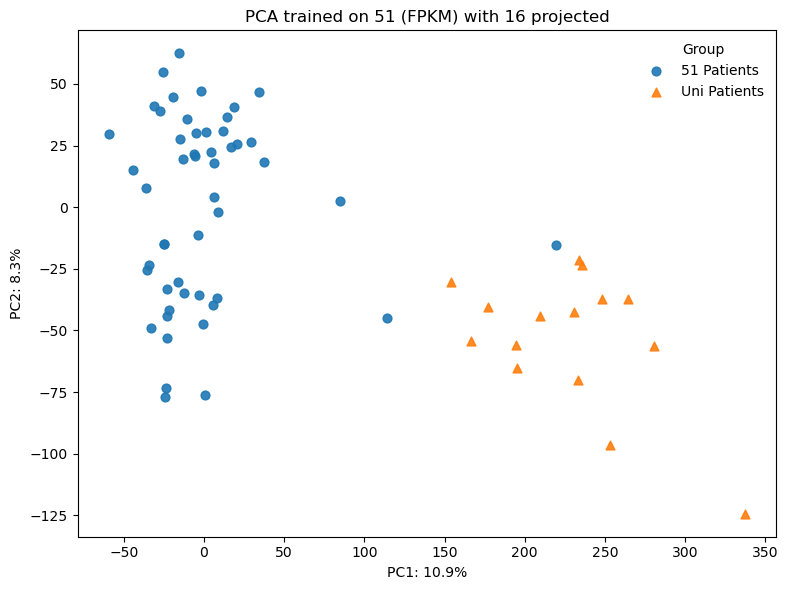

Saved figure + scores to: /mnt/lustre/home/nahnsen/nahfo470/mycode


In [25]:
import re, os
import matplotlib.pyplot as plt
import pandas as pd

patients_keep = [
  "sample9","sample10","sample13","sample14",
  "sample16","sample17","sample19","smaple20",
  "sample21","sample24","sample23","sample26",
  "sample27","sample30","sample31","sample32"
]

def norm_uni_id(x):
    s = str(x).strip().lower()
    s = re.sub(r"[._ ]", "", s)
    s = re.sub(r"-+", "", s)
    return s

# --- filter to 16 using normalized IDs ---
scores30 = scores30.copy()
scores30["ID_std"] = scores30["sample"].map(norm_uni_id)

keep_std = {norm_uni_id(x) for x in patients_keep}
scores16 = scores30[scores30["ID_std"].isin(keep_std)].copy()

print("Selected Uni kept:", len(scores16), "/ 16")
missing = sorted(keep_std - set(scores30["ID_std"]))
if missing:
    print("Missing (normalized):", missing)

# --- combine: all 51 + selected 16 ---
scores_51_16 = pd.concat([
    scores51.loc[:, ["sample", "PC1", "PC2", "set"]],
    scores16.loc[:, ["sample", "PC1", "PC2", "set"]]
], ignore_index=True)

marker_map = {"51 Patients": "o", "Uni Patients": "^"}

fig, ax = plt.subplots(figsize=(8, 6))
for group, df_g in scores_51_16.groupby("set"):
    ax.scatter(df_g["PC1"], df_g["PC2"],
               label=group,
               marker=marker_map.get(group, "o"),
               s=40, alpha=0.9)

pc1_pct = float(var_exp51[0]) * 100
pc2_pct = float(var_exp51[1]) * 100
ax.set_title("PCA trained on 51 (FPKM) with 16 projected")
ax.set_xlabel(f"PC1: {pc1_pct:.1f}%")
ax.set_ylabel(f"PC2: {pc2_pct:.1f}%")

ax.legend(title="Group", frameon=False)
ax.grid(False)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
plt.show()

out_dir = "/mnt/lustre/home/nahnsen/nahfo470/mycode"
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "PCA_train51_project16_noLabels.jpg"),
            dpi=300, bbox_inches="tight")
scores_51_16.to_csv(os.path.join(out_dir, "PCA_train51_project16_scores.csv"),
                    index=False)
print("Saved figure + scores to:", out_dir)

In [26]:
import pandas as pd
import re
from pathlib import Path

base = Path("/mnt/lustre/home/nahnsen/nahfo470/mycode")

# --- Load PCA scores (rows = samples, cols = PCs). R wrote row names -> first column.
scores = pd.read_csv(base / "pca_scores.csv")

# Find/standardize the sample column
if "sample" in scores.columns:
    pass
else:
    # first column is rownames from R (often 'Unnamed: 0' or similar)
    scores = scores.rename(columns={scores.columns[0]: "sample"})

# Keep only sample + PC* columns
pc_cols = [c for c in scores.columns if re.match(r"^PC\d+$", str(c))]
scores = scores[["sample"] + pc_cols].copy()

# --- Load metadata (sample, batch)
meta = pd.read_csv(base / "metadata_samples.csv")  # has 'sample' and 'batch'
df = scores.merge(meta, on="sample", how="left")

print("PCA rows:", df.shape[0], "| PCs:", len(pc_cols))
print(df.head(3))


PCA rows: 85 | PCs: 85
   sample        PC1        PC2        PC3        PC4        PC5        PC6  \
0  X-1027 -11.132342  23.027804 -18.586583  39.262523 -32.637430  31.300833   
1  X-1119   3.231461   4.810058 -30.261094  60.763041  15.187854  -6.192909   
2  X-1167 -19.552289 -47.834261 -21.011768  32.881859  46.033431  14.205311   

         PC7        PC8       PC9  ...       PC77      PC78      PC79  \
0 -25.318089  11.433695  8.557399  ...  -0.674705 -0.941545 -1.025150   
1   6.927180   1.390055 -7.555946  ...  16.047253  4.498792 -3.967574   
2  -1.999001  26.241341 -5.396903  ...  -2.513439  3.760856  7.286672   

       PC80      PC81      PC82      PC83      PC84          PC85        batch  
0  3.684232 -1.692274  0.503716 -2.310491  3.677873 -2.666270e-14  51 Patients  
1  5.451244 -2.826406 -1.175981  1.524180  3.574977  1.550930e-14  51 Patients  
2  2.796500 -1.166292  3.437188  2.225776  4.098304  2.386286e-13  51 Patients  

[3 rows x 87 columns]


In [27]:
import pandas as pd
ve = pd.read_csv("/mnt/lustre/home/nahnsen/nahfo470/mycode/pca_variance_explained.csv")  # column: var_explained
if "var_explained" not in ve.columns: ve.columns = ["var_explained"]
print("PC1:", ve.var_explained.iloc[0]*100, "%")
print("PC2:", ve.var_explained.iloc[1]*100, "%")
print("Top 10 cumulative %:", (ve.var_explained.iloc[:10].sum()*100))


PC1: 10.1391914785302 %
PC2: 6.956812375749501 %
Top 10 cumulative %: 45.670647467059204


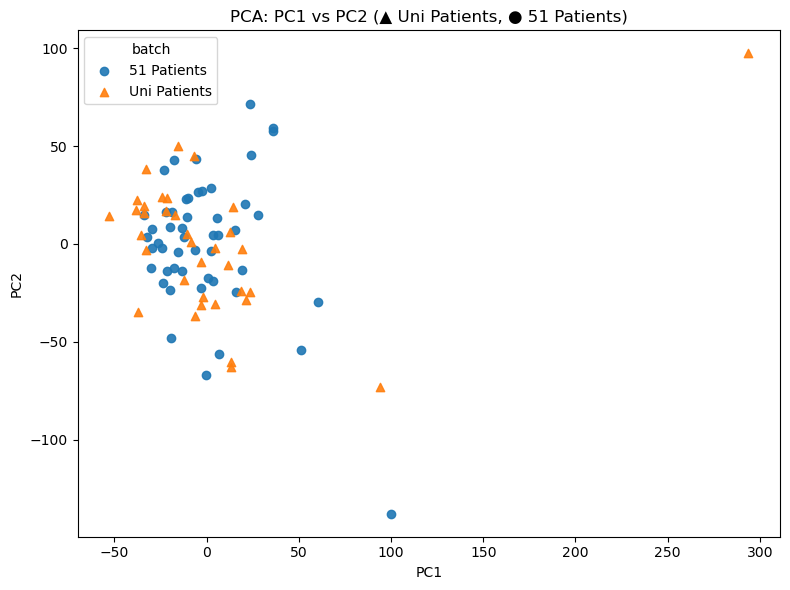

In [28]:
import re
import matplotlib.pyplot as plt

# pick PC1/PC2
pc_cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                 key=lambda x: int(re.sub(r"\D","", x)))
pc1, pc2 = pc_cols[0], pc_cols[1]

# use 'set' if present, else fall back to 'batch'
group_col = "set" if "set" in df.columns else "batch"

# shapes: triangles for Uni, circles for 51
marker_map = {"Uni Patients": "^", "51 Patients": "o"}
default_marker = "o"

fig, ax = plt.subplots(figsize=(8,6))
for grp, sub in df.groupby(group_col):
    ax.scatter(sub[pc1], sub[pc2],
               marker=marker_map.get(grp, default_marker),
               alpha=0.9, label=str(grp))

ax.legend(title=group_col, loc="best")
ax.set_title("PCA: PC1 vs PC2 (▲ Uni Patients, ● 51 Patients)")
ax.set_xlabel(pc1)
ax.set_ylabel(pc2)
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_linewidth(0.8)
plt.tight_layout(); plt.show()


Sheet1 columns:
  • 'Pateint ID'  ->  pateint id
  • 'RNA seq'  ->  rna seq
  • 'NewID'  ->  newid
  • 'Geburtsdatum'  ->  geburtsdatum
  • 'Geschlecht'  ->  geschlecht
  • 'Behandlung 1'  ->  behandlung 1
  • 'Cluster1'  ->  cluster1
  • 'Entnahme von Probe '  ->  entnahme von probe
  • 'Behandlung 2 '  ->  behandlung 2
  • 'Cluster 2'  ->  cluster 2
  • 'Diagnose (ICD-10)'  ->  diagnose (icd-10)
  • 'Relevante Datei'  ->  relevante datei
  • 'RNAseq Datum'  ->  rnaseq datum

Detected → id=RNA seq | b1=Behandlung 1 | b2=Behandlung 2  | c1=Cluster1 | c2=Cluster 2


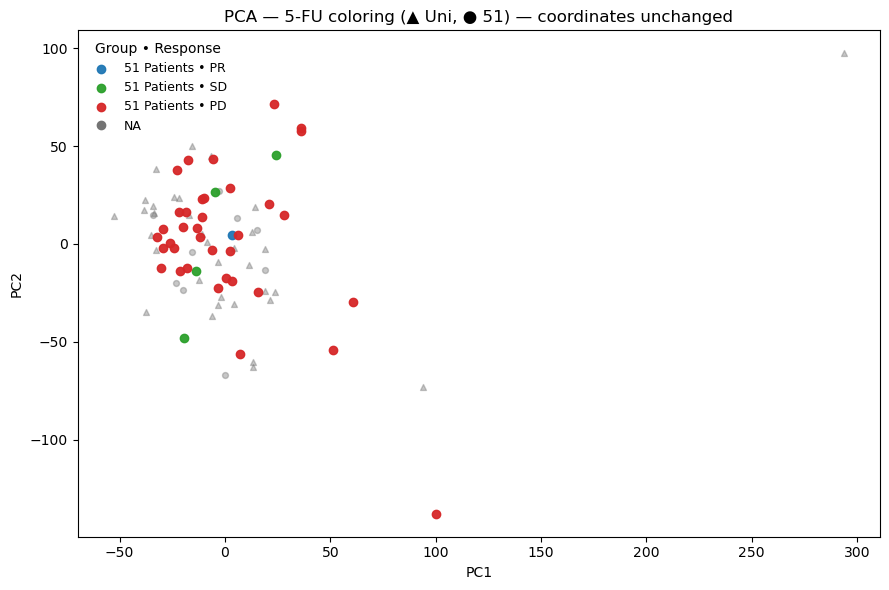


5-FU matches by cohort & response:
ResponseLegend  PD  PR  SD
batch                     
51 Patients     36   1   4


In [29]:
import re, unicodedata, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.lines as mlines
from pathlib import Path

base = Path("/mnt/lustre/home/nahnsen/nahfo470/mycode")

# ---------- Reuse PCA table (df_sub preferred), coords unchanged ----------
try:
    df_plot = df_sub.copy()
except NameError:
    df_plot = df.copy()

pc_cols = sorted([c for c in df_plot.columns if re.fullmatch(r"PC\d+", str(c))],
                 key=lambda x: int(re.sub(r"\D","", x)))
pc1, pc2 = pc_cols[0], pc_cols[1]

# ---------- Helpers (R logic) ----------
def norm_id(x: str) -> str:
    return re.sub(r"[._ ]","-", str(x).strip())

# ---------- Helpers (R logic) ----------
def norm_id(x: str) -> str:
    return re.sub(r"[._ ]","-", str(x).strip())

def canon_resp_generic(x):
    if pd.isna(x): return np.nan
    y = str(x).strip().upper()
    if y in {"", "NA", "N/A", "1"}: return np.nan
    y = re.sub(r"^COMPLETE.*", "CR", y)
    y = re.sub(r"^PARTIAL.*",  "PR", y)
    y = re.sub(r"^STABLE.*",   "SD", y)
    y = re.sub(r"^PROGRESS.*", "PD", y)
    if re.search(r"->\s*PD", y): return "PD"
    if re.search(r"->\s*PR", y): return "PR"
    if re.search(r"->\s*SD", y): return "SD"
    return y if y in {"CR","PR","SD","PD"} else np.nan

def apply_overrides_51(raw):
    if pd.isna(raw): return np.nan
    resp_norm = re.sub(r"[ \t\n\r.]", "", str(raw)).upper()
    out = canon_resp_generic(raw)
    if resp_norm == "SD-->PD":    out = "PD"
    if resp_norm == "SD-->-->PD": out = "SD"
    if resp_norm == "PR-->PD":    out = "PD"
    if resp_norm == "PR-->-->PD": out = "PR"
    return out if out in {"CR","PR","SD","PD"} else np.nan

_pat_5fu = re.compile(r"(?i)\b5\s*-?\s*fu\b|\b5\s*-?\s*fluorouracil\b|\bfluorouracil\b")
def match_5fu(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).apply(lambda t: bool(_pat_5fu.search(t)))

def normcol(s: str) -> str:
    """Normalize a column name: NFKC, replace non-breaking spaces, collapse whitespace, lower."""
    s = unicodedata.normalize("NFKC", str(s))
    s = s.replace("\u00A0", " ")             # NBSP -> space
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

def pick_exact(cols, target):
    nt = normcol(target)
    # exact normalized match
    for c in cols:
        if normcol(c) == nt:
            return c
    # substring fallback
    for c in cols:
        if nt in normcol(c):
            return c
    return None

# ---------- 51 cohort ----------
pct = pd.read_excel(base / "Patient-List.xlsx", sheet_name="PCT curve metrics")
resp_col_51  = [c for c in pct.columns if re.search(r"^\s*Response\s*Categor", c, re.I)][0]
treat_col_51 = [c for c in pct.columns if re.fullmatch(r"\s*(Treatment|Therapy|Regimen)\s*", c, re.I)][0]
pct["Model_std"] = pct["Model"].apply(norm_id)
pct["Response4"] = pct[resp_col_51].apply(apply_overrides_51)
pct["TrtMatch"]  = match_5fu(pct[treat_col_51])
resp51_map = {mid: (sub.loc[sub["TrtMatch"], "Response4"].dropna().tolist()[0] if
                    len(sub.loc[sub["TrtMatch"], "Response4"].dropna()) else np.nan)
              for mid, sub in pct.groupby("Model_std")}

# ---------- 16 Uni cohort (sheet1 with robust header matching) ----------
p30 = pd.read_excel(base / "30 Patients Data.xlsx", sheet_name=0)

# reveal columns + their normalized forms (helps debugging invisible chars)
print("Sheet1 columns:")
for c in p30.columns:
    print(f"  • {repr(c)}  ->  {normcol(c)}")

id_col_30 = pick_exact(p30.columns, "RNA seq") or p30.columns[0]
b1_col    = pick_exact(p30.columns, "Behandlung 1")
b2_col    = pick_exact(p30.columns, "Behandlung 2")
c1_col    = (pick_exact(p30.columns, "Cluster1") or pick_exact(p30.columns, "Cluster 1")
             or pick_exact(p30.columns, "Cluster I") or pick_exact(p30.columns, "Response 1") or pick_exact(p30.columns, "Response"))
c2_col    = (pick_exact(p30.columns, "Cluster2") or pick_exact(p30.columns, "Cluster 2")
             or pick_exact(p30.columns, "Cluster II") or pick_exact(p30.columns, "Response 2"))

print(f"\nDetected → id={id_col_30} | b1={b1_col} | b2={b2_col} | c1={c1_col} | c2={c2_col}")

p30["ID_std"] = p30[id_col_30].apply(norm_id)
m1 = match_5fu(p30[b1_col]) if b1_col else pd.Series(False, index=p30.index)
m2 = match_5fu(p30[b2_col]) if b2_col else pd.Series(False, index=p30.index)

resp30_vec = np.full(len(p30), np.nan, dtype=object)
if c1_col is not None: resp30_vec[(m1 & ~m2).values] = p30.loc[m1 & ~m2, c1_col].astype(str).values
if c2_col is not None: resp30_vec[(m2 & ~m1).values] = p30.loc[m2 & ~m1, c2_col].astype(str).values
both = (m1 & m2)
if both.any():
    # prefer Cluster1 if present
    if c1_col is not None:
        resp30_vec[both.values] = p30.loc[both, c1_col].astype(str).values
    elif c2_col is not None:
        resp30_vec[both.values] = p30.loc[both, c2_col].astype(str).values
resp30_vec = [canon_resp_generic(x) for x in resp30_vec]
resp30_map = dict(zip(p30["ID_std"], resp30_vec))

# ---------- Attach labels to PCA (no coordinate change) ----------
df_plot = df_plot.copy()
if "sample" not in df_plot.columns:
    df_plot = df_plot.rename(columns={df_plot.columns[0]: "sample"})
df_plot["ID_std"] = df_plot["sample"].apply(norm_id)

# cohort column for shapes
if "set" in df_plot.columns:
    set_col = "set"
elif "batch" in df_plot.columns:
    set_col = "batch"
else:
    id_51_all  = set(pct["Model_std"])
    id_uni_all = set(p30["ID_std"])
    df_plot["set"] = df_plot["ID_std"].map(lambda z:
        "51 Patients" if z in id_51_all else ("Uni Patients" if z in id_uni_all else "Other"))
    set_col = "set"

def map_response(idstd):
    v = resp51_map.get(idstd, np.nan)
    if pd.isna(v): v = resp30_map.get(idstd, np.nan)
    return v

df_plot["ResponseUnified"] = df_plot["ID_std"].map(map_response)
df_plot["ResponseLegend"]  = df_plot["ResponseUnified"].fillna("NA")

# ---------- Plot: exact palette & shapes ----------
pal = {"CR":"#deeb27","PR":"#1f77b4","SD":"#2ca02c","PD":"#d62728","NA":"#747474"}
shape_map = {"51 Patients":"o", "Uni Patients":"^", "Other":"o"}

fig, ax = plt.subplots(figsize=(9,6))

bg = df_plot[df_plot["ResponseLegend"] == "NA"]
for s, d in bg.groupby(set_col):
    ax.scatter(d[pc1], d[pc2], s=18, alpha=0.4, color=pal["NA"], marker=shape_map.get(s, "o"), label=None)

fg = df_plot[df_plot["ResponseLegend"].isin(["CR","PR","SD","PD"])]
for s in ["51 Patients","Uni Patients","Other"]:
    dset = fg[fg[set_col] == s]
    for lab in ["CR","PR","SD","PD"]:
        dlab = dset[dset["ResponseLegend"] == lab]
        if len(dlab):
            ax.scatter(dlab[pc1], dlab[pc2], s=36, alpha=0.95,
                       color=pal[lab], marker=shape_map.get(s, "o"),
                       label=f"{s} • {lab}")

if len(bg):
    bg_handle = mlines.Line2D([], [], color=pal["NA"], marker="o",
                              linestyle="None", markersize=6, label="NA")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(bg_handle); labels.append("NA")
    ax.legend(handles, labels, title="Group • Response", fontsize=9, frameon=False, loc="best")
else:
    ax.legend(title="Group • Response", fontsize=9, frameon=False, loc="best")

ax.set_xlabel(pc1); ax.set_ylabel(pc2)
ax.set_title("PCA — 5-FU coloring (▲ Uni, ● 51) — coordinates unchanged")
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_linewidth(0.8)
plt.tight_layout(); plt.show()

print("\n5-FU matches by cohort & response:")
print(pd.crosstab(fg[set_col], fg["ResponseLegend"]))


In [30]:
##########################################
## Df-treatment-response merging
##########################################3

import re, unicodedata, numpy as np, pandas as pd
from pathlib import Path

base = Path("/mnt/lustre/home/nahnsen/nahfo470/mycode")

# ------------------ KEEP LISTS ------------------
Sample_names = [
  "Sample","X-0933", "X-1027", "X-1095", "X-1119", "X-1167", "X-1173", "X-1210", "X-1234", "X-1256",
  "X-1270", "X-1290", "X-1303", "X-1329", "X-1441", "X-1443", "X-1479", "X-1480", "X-1493",
  "X-1500", "X-1536", "X-1538", "X-1855", "X-1867", "X-2145", "X-2182", "X-2239", "X-2374",
  "X-2403","X-2483", "X-2484", "X-2514", "X-2538", "X-2573", "X-2659","X-2697", "X-2742",
  "X-2761", "X-2803", "X-2822", "X-2846", "X-2861", "X-2991", "X-3019", "X-3093", "X-3135",
  "X-3196", "X-3205", "X-3224","X-3239", "X-3267", "X-3570", "X-3671", "X-3684", "X-3765",
  "X-3792", "X-4087", "X-4454", "X-4484", "X-5238", "X-5254", "X-5405", "X-5421", "X-5438",
  "X-5441", "X-5446", "X-5494", "X-5495", "X-5563", "X-5578", "X-5594"
]

patients_keep = [ "sample9","sample10","sample13","sample14", 
                 "sample16","sample17","sample19","smaple20", 
                 "sample21","sample24","sample23","sample26", 
                 "sample27","sample30","sample31","sample32" ]
# ------------------ helpers ------------------
def norm_uni_id(x):
    s = str(x).strip().lower()
    s = re.sub(r"[._ ]", "", s)
    s = re.sub(r"-+", "", s)
    return s

def canon_resp_generic(x):
    if pd.isna(x):
        return np.nan
    y = str(x).strip().upper()
    if y in {"", "NA", "N/A", "1"}:
        return np.nan
    y = re.sub(r"^COMPLETE.*", "CR", y)
    y = re.sub(r"^PARTIAL.*",  "PR", y)
    y = re.sub(r"^STABLE.*",   "SD", y)
    y = re.sub(r"^PROGRESS.*", "PD", y)
    if re.search(r"->\s*PD", y): return "PD"
    if re.search(r"->\s*PR", y): return "PR"
    if re.search(r"->\s*SD", y): return "SD"
    return y if y in {"CR","PR","SD","PD"} else np.nan

def apply_overrides_51(raw):
    if pd.isna(raw):
        return np.nan
    resp_norm = re.sub(r"[ \t\n\r.]", "", str(raw)).upper()
    out = canon_resp_generic(raw)
    if resp_norm == "SD-->PD":    out = "PD"
    if resp_norm == "SD-->-->PD": out = "SD"
    if resp_norm == "PR-->PD":    out = "PD"
    if resp_norm == "PR-->-->PD": out = "PR"
    return out if out in {"CR","PR","SD","PD"} else np.nan

def normcol(s: str) -> str:
    s = unicodedata.normalize("NFKC", str(s))
    s = s.replace("\u00A0", " ")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

def pick_exact(cols, target):
    nt = normcol(target)
    for c in cols:
        if normcol(c) == nt:
            return c
    for c in cols:
        if nt in normcol(c):
            return c
    return None

# ============================================================
# 1) 51 cohort: get *only* the patients in Sample_names
#    Treatment/Response come from sheet "PCT curve metrics"
# ============================================================

# Clean keep list (remove the "Sample" header if present)
keep_51_raw = [x for x in Sample_names if str(x).strip().upper() not in {"SAMPLE", ""}]
keep_51_std = set(norm_id(x) for x in keep_51_raw)

pct = pd.read_excel(base / "Patient-List.xlsx", sheet_name="PCT curve metrics")

# Find the treatment and response columns (robust)
treat_col_51 = next((c for c in pct.columns if re.fullmatch(r"\s*(Treatment|Therapy|Regimen)\s*", str(c), re.I)), None)
resp_col_51  = next((c for c in pct.columns if re.search(r"^\s*Response\s*Categor", str(c), re.I)), None)
if treat_col_51 is None:
    raise RuntimeError("Could not find Treatment/Therapy/Regimen column in 'PCT curve metrics'.")
if resp_col_51 is None:
    raise RuntimeError("Could not find Response Categor* column in 'PCT curve metrics'.")
if "Model" not in pct.columns:
    raise RuntimeError("Expected column 'Model' in 'PCT curve metrics'.")

pct_map = pct.copy()
pct_map["ID_std"]   = pct_map["Model"].map(norm_id)
pct_map["Treatment"] = pct_map[treat_col_51].astype(str).str.strip()
pct_map["Response"]  = pct_map[resp_col_51].apply(apply_overrides_51)

# Filter to 51 patient set
pct_map = pct_map[pct_map["ID_std"].isin(keep_51_std)].copy()

pct_map["Cohort"] = "51"
pct_map["Source"] = "Patient-List.xlsx:PCT curve metrics"
pct_map["Slot"]   = "PCT"

pct_map = pct_map[["ID_std","Treatment","Response","Cohort","Source","Slot"]].drop_duplicates()

# ============================================================
# 2) Uni cohort: get *only* patients_keep
#    Treatment/Response come from 30 Patients Data.xlsx (sheet 1 = first sheet)
# ============================================================

keep_uni_std = set(norm_uni_id(x) for x in patients_keep)

p30 = pd.read_excel(base / "30 Patients Data.xlsx", sheet_name=0)

id_col_30 = pick_exact(p30.columns, "NewID")
b1_col    = pick_exact(p30.columns, "Behandlung 1")
b2_col    = pick_exact(p30.columns, "Behandlung 2")
c1_col    = pick_exact(p30.columns, "Cluster1") or pick_exact(p30.columns, "Cluster 1") or pick_exact(p30.columns, "Response 1") or pick_exact(p30.columns, "Response")
c2_col    = pick_exact(p30.columns, "Cluster 2") or pick_exact(p30.columns, "Cluster2") or pick_exact(p30.columns, "Response 2")

if id_col_30 is None:
    raise RuntimeError("Could not find column 'NewID' in 30 Patients Data.xlsx.")
if b1_col is None and b2_col is None:
    raise RuntimeError("Could not find Behandlung 1/2 columns in 30 Patients Data.xlsx.")
if c1_col is None and c2_col is None:
    raise RuntimeError("Could not find Cluster/Response columns in 30 Patients Data.xlsx.")

p30 = p30.copy()
p30["ID_std"] = p30[id_col_30].map(norm_uni_id)

# Filter to your Uni patients
p30 = p30[p30["ID_std"].isin(keep_uni_std)].copy()

uni_long = []
for _, r in p30.iterrows():
    pid = r["ID_std"]
    if pd.isna(pid):
        continue

    # slot 1
    if b1_col is not None:
        trt1 = r.get(b1_col, np.nan)
        if pd.notna(trt1) and str(trt1).strip() != "":
            resp1 = r.get(c1_col, np.nan) if c1_col is not None else np.nan
            uni_long.append([pid, str(trt1).strip(), canon_resp_generic(resp1), "Uni", "30 Patients Data.xlsx:sheet0", "Behandlung 1"])

    # slot 2
    if b2_col is not None:
        trt2 = r.get(b2_col, np.nan)
        if pd.notna(trt2) and str(trt2).strip() != "":
            resp2 = r.get(c2_col, np.nan) if c2_col is not None else np.nan
            uni_long.append([pid, str(trt2).strip(), canon_resp_generic(resp2), "Uni", "30 Patients Data.xlsx:sheet0", "Behandlung 2"])

uni_map = pd.DataFrame(uni_long, columns=["ID_std","Treatment","Response","Cohort","Source","Slot"]).drop_duplicates()

# ============================================================
# 3) FINAL unified dataframe 
#    One row per (patient, treatment-slot)
# ============================================================

df_treatment_response = pd.concat([pct_map, uni_map], ignore_index=True)

# Optional cleanup: keep only CR/PR/SD/PD, keep NA as NA (not string)
df_treatment_response["Response"] = df_treatment_response["Response"].where(
    df_treatment_response["Response"].isin(["CR","PR","SD","PD"]), np.nan
)

print("df_treatment_response created.")
print("Rows:", len(df_treatment_response))
print("Unique patients:", df_treatment_response["ID_std"].nunique())
print("\nCounts by cohort:")
print(df_treatment_response["Cohort"].value_counts(dropna=False))
print("\nResponse counts:")
print(df_treatment_response["Response"].value_counts(dropna=False).to_dict())



df_treatment_response created.
Rows: 921
Unique patients: 66

Counts by cohort:
Cohort
51     891
Uni     30
Name: count, dtype: int64

Response counts:
{'PD': 791, 'SD': 78, 'PR': 36, 'CR': 11, nan: 5}


In [31]:
#Sanity check: show treatments containing "5-FU" and their responses
print(
    df_treatment_response[
        df_treatment_response["Treatment"].astype(str).str.upper().str.contains(r"5[\s\-]*FU", na=False, regex=True)
    ][["ID_std", "Treatment", "Response"]]
)

       ID_std           Treatment Response
0      X-0933                 5FU       PD
22     X-1027                 5FU       PD
43     X-1119                 5FU       PR
65     X-1167                 5FU       SD
87     X-1173                 5FU       SD
111    X-1270                 5FU       PD
132    X-1290                 5FU       PD
154    X-1303                 5FU       PD
174    X-1329                 5FU       PD
196    X-1441                 5FU       PD
217    X-1443                 5FU       PD
239    X-1479                 5FU       PD
260    X-1500                 5FU       SD
282    X-1536                 5FU       PD
309    X-1855                 5FU       PD
330    X-2145                 5FU       PD
352    X-2182                 5FU       PD
374    X-2239                 5FU       PD
390    X-2374                 5FU       PD
411    X-2403                 5FU       PD
432    X-2483                 5FU       PD
454    X-2484                 5FU       PD
476    X-25

In [32]:
import re
import pandas as pd
import numpy as np

assert "df_treatment_response" in globals(), (
    "df_treatment_response is not loaded."
)

VALID = {"CR","PR","SD","PD"}

def canon_resp(x):
    if pd.isna(x):
        return np.nan
    y = str(x).strip().upper()
    if y.startswith("COMPLETE"):  return "CR"
    if y.startswith("PARTIAL"):   return "PR"
    if y.startswith("STABLE"):    return "SD"
    if y.startswith("PROGRESS"):  return "PD"
    return y if y in VALID else np.nan

# ------------------------------------------------
# 1) Filter to BINIMETINIB
# ------------------------------------------------
bin_df = df_treatment_response[
    df_treatment_response["Treatment"]
        .astype(str)
        .str.upper()
        .str.contains(r"\bBINIMETINIB\b", regex=True, na=False)
].copy()

# ------------------------------------------------
# 2) Canonical response
# ------------------------------------------------
bin_df["ResponseCanon"] = bin_df["Response"].apply(canon_resp)

# ------------------------------------------------
# 3) ENFORCE NO DUPLICATES (one row per patient)
# ------------------------------------------------
bin_unique = (
    bin_df
    .dropna(subset=["ID_std"])          # must have patient ID
    .drop_duplicates(subset=["ID_std"]) # one row per patient
)

# ------------------------------------------------
# 4) FINAL COUNTS
# ------------------------------------------------
print("=== BINIMETINIB — UNIQUE PATIENTS ONLY ===")
print("Total unique patients:", bin_unique["ID_std"].nunique())

print("\nPatients per response:")
print(bin_unique["ResponseCanon"].value_counts(dropna=False))

=== BINIMETINIB — UNIQUE PATIENTS ONLY ===
Total unique patients: 51

Patients per response:
ResponseCanon
PD    29
SD    11
PR    11
Name: count, dtype: int64


In [33]:
######################
#Start of KNN
#####################

In [34]:
# START OF KNN
import numpy as np
from collections import Counter

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def distances_from_main_to_labeled(main_id):
    df = df_plot.copy()

    # PC columns
    pc_cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                     key=lambda x: int(re.sub(r"\D","", x)))

    # label column
    label_col = "ResponseUnified" if "ResponseUnified" in df.columns else "ResponseLegend"

    # main vector
    row = df.loc[df["sample"].astype(str) == str(main_id)]
    main_vec = row.iloc[0][pc_cols].to_numpy(float)

    # labeled candidates
    labeled = df[df[label_col].isin(["CR","PR","SD","PD"])].copy()

    # distances
    records = []
    for _, r in labeled.iterrows():
        sid = str(r["sample"])
        if sid == str(main_id):
            continue
        vec = r[pc_cols].to_numpy(float)
        d = euclidean_distance(main_vec, vec)
        records.append([sid, r.get("set", np.nan), r[label_col], d])

    out = pd.DataFrame(records, columns=["neighbor_id","Set","response","distance"])
    out = out.sort_values("distance", ascending=True).reset_index(drop=True)
    return out

#Second part 
# --- distance + KNN ---
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

# --- build training_data, training_labels, and test_point from df_plot ---
def prepare_knn_io(main_id, n_pcs=41):
    # pick PC columns in numeric order, keep the first n_pcs (or all if fewer available)
    pc_cols_all = sorted([c for c in df_plot.columns if re.fullmatch(r"PC\d+", str(c))],
                         key=lambda x: int(re.sub(r"\D", "", x)))
    pc_cols = pc_cols_all[:min(n_pcs, len(pc_cols_all))]

    # label column ( R → Python transfer)
    label_col = "ResponseUnified" if "ResponseUnified" in df_plot.columns else "ResponseLegend"

    # test point (MAIN patient)
    row = df_plot.loc[df_plot["sample"].astype(str) == str(main_id)]
    if row.empty:
        raise ValueError(f"'{main_id}' not found in df_plot['sample'].")
    test_point = row.iloc[0][pc_cols].astype(float).tolist()

    # training pool: only labeled rows (CR/PR/SD/PD), drop NaN PCs, exclude the main if it’s labeled
    labeled_mask = df_plot[label_col].isin(["CR","PR","SD","PD"])
    train_df = df_plot[labeled_mask].dropna(subset=pc_cols).copy()
    train_df = train_df[train_df["sample"].astype(str) != str(main_id)]

    training_data = train_df[pc_cols].astype(float).to_numpy().tolist()
    training_labels = train_df[label_col].astype(str).tolist()

    return training_data, training_labels, test_point

# === run it (set your MAIN patient here) ===
MAIN_ID = "sample10"   # <- change this to the patient you want as MAIN
training_data, training_labels, test_point = prepare_knn_io(MAIN_ID, n_pcs=41)

k = 5
prediction = knn_predict(training_data, training_labels, test_point, k)
print("Predicted label for", MAIN_ID, "=", prediction)




Predicted label for sample10 = PD


In [35]:

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def distances_from_main_to_labeled(main_id):
    df = df_plot.copy()

    # PC columns
    pc_cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                     key=lambda x: int(re.sub(r"\D","", x)))

    # label column
    label_col = "ResponseUnified" if "ResponseUnified" in df.columns else "ResponseLegend"

    # main vector
    row = df.loc[df["sample"].astype(str) == str(main_id)]
    main_vec = row.iloc[0][pc_cols].to_numpy(float)

    # labeled candidates
    labeled = df[df[label_col].isin(["CR","PR","SD","PD"])].copy()

    # distances
    records = []
    for _, r in labeled.iterrows():
        sid = str(r["sample"])
        if sid == str(main_id):
            continue
        vec = r[pc_cols].to_numpy(float)
        d = euclidean_distance(main_vec, vec)
        records.append([sid, r.get("set", np.nan), r[label_col], d])

    out = pd.DataFrame(records, columns=["neighbor_id","Set","response","distance"])
    out = out.sort_values("distance", ascending=True).reset_index(drop=True)
    return out

#Second part 
# --- distance + KNN -
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

# --- build training_data, training_labels, and test_point from df_plot ---
def prepare_knn_io(main_id, n_pcs=41):
    # pick PC columns in numeric order, keep the first n_pcs (or all if fewer available)
    pc_cols_all = sorted([c for c in df_plot.columns if re.fullmatch(r"PC\d+", str(c))],
                         key=lambda x: int(re.sub(r"\D", "", x)))
    pc_cols = pc_cols_all[:min(n_pcs, len(pc_cols_all))]

    # label column ( R → Python transfer)
    label_col = "ResponseUnified" if "ResponseUnified" in df_plot.columns else "ResponseLegend"

    # test point (MAIN patient)
    row = df_plot.loc[df_plot["sample"].astype(str) == str(main_id)]
    if row.empty:
        raise ValueError(f"'{main_id}' not found in df_plot['sample'].")
    test_point = row.iloc[0][pc_cols].astype(float).tolist()

    # training pool: only labeled rows (CR/PR/SD/PD), drop NaN PCs, exclude the main if it’s labeled
    labeled_mask = df_plot[label_col].isin(["CR","PR","SD","PD"])
    train_df = df_plot[labeled_mask].dropna(subset=pc_cols).copy()
    train_df = train_df[train_df["sample"].astype(str) != str(main_id)]

    training_data = train_df[pc_cols].astype(float).to_numpy().tolist()
    training_labels = train_df[label_col].astype(str).tolist()

    return training_data, training_labels, test_point

# === run it (set your MAIN patient here) ===
MAIN_ID = "X-1500"   # <- change this to the patient you want as MAIN
training_data, training_labels, test_point = prepare_knn_io(MAIN_ID, n_pcs=41)

k = 5
prediction = knn_predict(training_data, training_labels, test_point, k)
print("Predicted label for", MAIN_ID, "=", prediction)


Predicted label for X-1500 = PD


In [36]:
import re
import numpy as np
import pandas as pd

# ---------------- constants ----------------
VALID = {"CR","PR","SD","PD"}

# robust matcher: BYL719 + ENCORAFENIB in any order
_pat_byl_enco = re.compile(r"(?i)\bBYL719\b.*\bENCORAFENIB\b|\bENCORAFENIB\b.*\bBYL719\b")
def is_byl_enco(t):
    return bool(_pat_byl_enco.search(str(t)))

# ---------------- helpers ----------------
def norm_uni_id(x):
    s = str(x).strip().lower()
    s = re.sub(r"[._ ]", "", s)
    s = re.sub(r"-+", "", s)
    return s

def canon_resp_to_legend(x):
    if pd.isna(x):
        return np.nan
    y = str(x).strip().upper()
    if y in {"", "NA", "N/A", "1"}:
        return np.nan
    if y.startswith("COMPLETE"):   y = "CR"
    elif y.startswith("PARTIAL"):  y = "PR"
    elif y.startswith("STABLE"):   y = "SD"
    elif y.startswith("PROGRESS"): y = "PD"
    if re.search(r"->\s*PD", y): return "PD"
    if re.search(r"->\s*PR", y): return "PR"
    if re.search(r"->\s*SD", y): return "SD"
    return y if y in VALID else np.nan

def euclidean_distance(point1, point2):
    a = np.asarray(point1, dtype=float)
    b = np.asarray(point2, dtype=float)
    return float(np.sqrt(np.sum((a - b) ** 2)))

def get_pc_cols(df):
    pcs = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                 key=lambda x: int(re.sub(r"\D", "", x)))
    if len(pcs) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return pcs

# ---------------- build df_work = PCA + ResponseLegend ----------------
assert "df_plot" in globals(), "df_plot (PCA table) not found."
assert "df_treatment_response" in globals(), "df_treatment_response not found."

df_work = df_plot.copy()

# ensure ID column exists
if "sample" not in df_work.columns:
    raise ValueError("Expected PCA to have a 'sample' column.")

df_work["ID_std"] = df_work["sample"].map(norm_id)

# cohort column name 
cohort_col = "batch" if "batch" in df_work.columns else ("set" if "set" in df_work.columns else None)
if cohort_col is None:
    df_work["batch"] = "Unknown"
    cohort_col = "batch"

# build mapping for BYL719+ENCORAFENIB
tr = df_treatment_response.copy()
tr["ID_std"] = tr["ID_std"].map(norm_id)
tr["ResponseLegend"] = tr["Response"].apply(canon_resp_to_legend)

tr_sel = tr[tr["Treatment"].astype(str).apply(is_byl_enco)].copy()

# one row per patient: prefer non-null ResponseLegend
tr_sel = (tr_sel.dropna(subset=["ID_std"])
                .assign(_isnull=lambda d: d["ResponseLegend"].isna().astype(int))
                .sort_values(["ID_std", "_isnull"])
                .drop(columns=["_isnull"])
                .drop_duplicates("ID_std", keep="first"))

# merge ResponseLegend into PCA
df_work = df_work.drop(columns=["ResponseLegend"], errors="ignore").merge(
    tr_sel[["ID_std", "ResponseLegend"]],
    on="ID_std",
    how="left"
)

# ---------------- neighbor distances ----------------
def distances_from_main_to_labeled(main_id, use_npcs=2):
    df = df_work.copy()
    pcs = get_pc_cols(df)[:use_npcs]

    # find main row by sample (exact)
    main_mask = df["sample"].astype(str) == str(main_id)
    if not main_mask.any():
        # helpful debug: show a few sample IDs
        examples = df["sample"].astype(str).head(15).tolist()
        raise ValueError(
            f"MAIN_ID '{main_id}' not found in df_plot['sample'].\n"
            f"Example sample IDs: {examples}\n"
            f"Tip: your PCA IDs look like 'X-1500', not 'RNA2303165A1_01'."
        )

    main_row = df.loc[main_mask].iloc[0]
    main_vec = main_row[pcs].to_numpy(float)

    if np.any(pd.isna(main_vec)):
        raise ValueError(f"MAIN_ID '{main_id}' has missing values in {pcs}. Try use_npcs=2 or pick another MAIN.")

    # labeled candidates
    labeled = df[df["ResponseLegend"].isin(VALID)].copy()

    records = []
    for _, r in labeled.iterrows():
        sid = str(r["sample"])
        if sid == str(main_id):
            continue
        vec = r[pcs].to_numpy(float)
        if np.any(pd.isna(vec)):
            continue
        d = euclidean_distance(main_vec, vec)
        records.append([sid, r.get(cohort_col, np.nan), r["ResponseLegend"], d])

    out = pd.DataFrame(records, columns=["neighbor_id", "Cohort", "ResponseLegend", "distance"])
    out = out.sort_values("distance", ascending=True).reset_index(drop=True)
    return out

# ===== RUN =====
MAIN_ID = "X-1500"   # <-- use PCA sample IDs like X-####
tbl = distances_from_main_to_labeled(MAIN_ID, use_npcs=2)

pd.set_option("display.max_rows", None)
print(tbl.to_string(index=False))

neighbor_id      Cohort ResponseLegend   distance
     X-5495 51 Patients             PD   4.507120
     X-3205 51 Patients             PD   8.021064
     X-5438 51 Patients             SD  12.713552
     X-2861 51 Patients             PD  13.546856
     X-3792 51 Patients             PD  14.549435
     X-2403 51 Patients             PR  16.013545
     X-5494 51 Patients             PR  16.750659
     X-5405 51 Patients             PD  17.180649
     X-3093 51 Patients             PD  17.778489
     X-2484 51 Patients             PD  18.924924
     X-2374 51 Patients             PD  18.941995
     X-1443 51 Patients             CR  21.829295
     X-2846 51 Patients             PR  23.192869
     X-1119 51 Patients             PD  24.919699
     X-1441 51 Patients             PD  25.527789
     X-4087 51 Patients             PD  26.657795
     X-2483 51 Patients             SD  26.840893
     X-1303 51 Patients             PD  27.454745
     X-5254 51 Patients             PD  30.151943


In [37]:
# ===== KNN PREDICTION =====
k = 7  # number of neighbors

topk = tbl.head(k)

print("\n===== KNN RESULT =====")
print(f"MAIN patient (input ID): {MAIN_ID}")
print(f"Number of neighbors (k): {k}")

print("\nTop-k neighbors used:")
print(topk.to_string(index=False))

# majority vote on ResponseLegend
vote_counts = topk["ResponseLegend"].value_counts()
predicted_response = vote_counts.idxmax()

print("\nVote counts:")
print(vote_counts.to_string())

print("\n>>> PREDICTED RESPONSE (ResponseLegend):", predicted_response)


===== KNN RESULT =====
MAIN patient (input ID): X-1500
Number of neighbors (k): 7

Top-k neighbors used:
neighbor_id      Cohort ResponseLegend  distance
     X-5495 51 Patients             PD  4.507120
     X-3205 51 Patients             PD  8.021064
     X-5438 51 Patients             SD 12.713552
     X-2861 51 Patients             PD 13.546856
     X-3792 51 Patients             PD 14.549435
     X-2403 51 Patients             PR 16.013545
     X-5494 51 Patients             PR 16.750659

Vote counts:
ResponseLegend
PD    4
PR    2
SD    1

>>> PREDICTED RESPONSE (ResponseLegend): PD


In [38]:
import numpy as np, pandas as pd, re
from collections import Counter
from pathlib import Path

base = Path("/mnt/lustre/home/nahnsen/nahfo470/mycode")  # where pca_sdev.csv lives
VALID = {"CR","PR","SD","PD"}

def _pc_cols(df):
    return sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))

def knn_predict_capped(
    main_id,
    k=5,
    per_class_cap=2,
    n_pcs=41,
    vote="distance",      # "distance" or "majority"
    whiten=True,          # use pca_sdev.csv to standardize PCs
    only_labeled=True     # restrict neighbor pool to CR/PR/SD/PD
):
    df = df_plot.copy()
    label_col = "ResponseUnified" if "ResponseUnified" in df.columns else "ResponseLegend"

    # PCs to use
    pcs_all = _pc_cols(df)
    pcs = pcs_all[:min(n_pcs, len(pcs_all))]
    if len(pcs) == 0:
        raise ValueError("No PC columns found (PC1, PC2, ...).")

    # main vector
    row = df.loc[df["sample"].astype(str) == str(main_id)]
    if row.empty:
        raise ValueError(f"'{main_id}' not found in df_plot['sample'].")
    xq = row.iloc[0][pcs].to_numpy(float)

    # optional whitening (divide each PC by its sdev from R)
    if whiten:
        sdev_df = pd.read_csv(base / "pca_sdev.csv")
        if "sdev" not in sdev_df.columns:
            raise ValueError("pca_sdev.csv must contain a column named 'sdev'.")
        sdev = sdev_df["sdev"].values
        if len(sdev) < len(pcs):
            raise ValueError(f"pca_sdev.csv has {len(sdev)} entries, need {len(pcs)} for PCs.")
        s = sdev[:len(pcs)].astype(float)
        s[s == 0] = 1.0
        xq_w = xq / s
    else:
        s = None
        xq_w = xq

    # candidate pool
    cand = df.copy()
    if only_labeled and label_col in cand.columns:
        cand = cand[cand[label_col].isin(list(VALID))]
    cand = cand[cand["sample"].astype(str) != str(main_id)].dropna(subset=pcs)

    X = cand[pcs].to_numpy(float)
    if whiten:
        Xw = X / s
        d = np.linalg.norm(Xw - xq_w, axis=1)
    else:
        d = np.linalg.norm(X - xq, axis=1)

    cand = cand.assign(distance=d).sort_values("distance", ascending=True)

    # pick up to k neighbors with per-class cap
    counts = Counter()
    picked = []
    for _, r in cand.iterrows():
        lab = r[label_col]
        if lab not in VALID:
            continue
        if counts[lab] < per_class_cap:
            picked.append(r[["sample", label_col, "distance"]])
            counts[lab] += 1
            if len(picked) == k:
                break

    neighbors = (pd.DataFrame(picked)
                   .rename(columns={"sample":"neighbor_id", label_col:"response"})
                   .reset_index(drop=True))

    # vote
    if neighbors.empty:
        return np.nan, neighbors

    if vote == "distance":
        eps = 1e-9
        neighbors["w"] = 1.0 / (neighbors["distance"].astype(float) + eps)
        scores = (neighbors.groupby("response")["w"].sum()
                  .sort_values(ascending=False))
        pred = scores.index[0]
    else:
        votes = Counter(neighbors["response"])
        maxc = max(votes.values())
        tied = [lab for lab, c in votes.items() if c == maxc]
        if len(tied) == 1:
            pred = tied[0]
        else:
            pred = (neighbors.groupby("response")["distance"]
                    .sum().loc[tied].sort_values().index[0])

    return pred, neighbors

def print_prediction_explanation(MAIN_ID, pred, neigh, vote="distance"):
    print("\n===== KNN PREDICTION =====")
    print("MAIN patient:", MAIN_ID)
    print("Predicted label (ResponseLegend):", pred)

    if neigh is None or len(neigh) == 0:
        print("\nNo neighbors selected -> cannot explain prediction.")
        return

    neigh2 = neigh.copy()
    neigh2["distance"] = neigh2["distance"].astype(float)
    neigh2 = neigh2.sort_values("distance").reset_index(drop=True)

    print("\nNeighbors used (after per-class cap):")
    # show weights too if distance voting
    if vote == "distance":
        eps = 1e-9
        neigh2["weight"] = 1.0 / (neigh2["distance"] + eps)
        print(neigh2.to_string(index=False))
        print("\nWeighted vote totals:")
        scores = (neigh2.groupby("response")["weight"].sum()
                  .sort_values(ascending=False))
        print(scores.to_string())
        print("\nWinning label:", scores.index[0])
    else:
        print(neigh2.to_string(index=False))
        print("\nMajority vote counts:")
        counts = Counter(neigh2["response"].tolist())
        for lab, c in sorted(counts.items(), key=lambda x: (-x[1], x[0])):
            print(f"{lab}: {c}")

        maxc = max(counts.values())
        tied = [lab for lab, c in counts.items() if c == maxc]
        if len(tied) == 1:
            winner = tied[0]
        else:
            winner = (neigh2.groupby("response")["distance"]
                            .sum().loc[tied].sort_values().index[0])
        print("\nWinning label:", winner)

# ===== Example run =====
MAIN_ID = "X-1500"
pred, neigh = knn_predict_capped(
    MAIN_ID,
    k=7,
    per_class_cap=2,
    n_pcs=30,
    vote="distance",
    whiten=True,
    only_labeled=True
)

print("Pred:", pred)
print(neigh)
print_prediction_explanation(MAIN_ID, pred, neigh, vote="distance")

Pred: PD
  neighbor_id response  distance         w
0      X-2374       PD  5.836678  0.171330
1      X-5254       PD  6.098931  0.163963
2      X-1173       SD  6.697966  0.149299
3      X-1167       SD  7.048518  0.141874
4      X-1119       PR  7.076653  0.141310

===== KNN PREDICTION =====
MAIN patient: X-1500
Predicted label (ResponseLegend): PD

Neighbors used (after per-class cap):
neighbor_id response  distance        w   weight
     X-2374       PD  5.836678 0.171330 0.171330
     X-5254       PD  6.098931 0.163963 0.163963
     X-1173       SD  6.697966 0.149299 0.149299
     X-1167       SD  7.048518 0.141874 0.141874
     X-1119       PR  7.076653 0.141310 0.141310

Weighted vote totals:
response
PD    0.335293
SD    0.291173
PR    0.141310

Winning label: PD


In [39]:
#######################################
# Hyperparameter 
#######################################

In [40]:
#Hyperparameter search for KNN
import numpy as np, pandas as pd, re
from collections import Counter
from pathlib import Path
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# ---------- helpers ----------
def pc_cols(df):
    return sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))

def get_label_col(df):
    return "ResponseUnified" if "ResponseUnified" in df.columns else "ResponseLegend"

def transform_X(df, pcs, mode="whiten", sdev=None):
    X = df[pcs].to_numpy(float)
    if mode == "whiten":
        if sdev is None: raise ValueError("sdev required for whitening")
        s = np.array(sdev[:len(pcs)], dtype=float).copy()
        s[s == 0] = 1.0
        return X / s
    elif mode == "raw":
        return X
    else:
        raise ValueError("mode must be 'whiten' or 'raw'")

def pick_neighbors_cap(df_sorted, label_col, k=5, per_class_cap=2):
    counts = Counter()
    picked_idx = []
    for i, r in df_sorted.iterrows():
        lab = str(r[label_col])
        if lab not in {"CR","PR","SD","PD"}:  # skip unlabeled
            continue
        if counts[lab] < per_class_cap:
            picked_idx.append(i)
            counts[lab] += 1
            if len(picked_idx) == k:
                break
    return df_sorted.loc[picked_idx]

def vote_label(nei, vote="distance"):
    if len(nei) == 0: return np.nan
    if vote == "distance":
        eps = 1e-9
        w = 1.0 / (nei["distance"].astype(float) + eps)
        return (nei.groupby("response")["distance"]
                   .apply(lambda s: np.sum(1.0/(s.values+eps)))
                   .sort_values(ascending=False).index[0])
    elif vote == "balanced":
        eps = 1e-9
        counts = nei["response"].value_counts().to_dict()
        def weight_row(r):
            return (1.0/(float(r["distance"])+eps)) * (1.0/float(counts.get(r["response"],1)))
        w = nei.apply(weight_row, axis=1)
        return (nei.assign(_w=w)
                   .groupby("response")["_w"].sum()
                   .sort_values(ascending=False).index[0])
    else:  # majority
        votes = Counter(nei["response"])
        maxc = max(votes.values())
        tied = [lab for lab, c in votes.items() if c == maxc]
        if len(tied) == 1:
            return tied[0]
        # tie-break: smallest total distance
        return (nei.groupby("response")["distance"].sum()
                   .loc[tied].sort_values().index[0])

# ---------- prepare labeled 5-FU training set ----------
df = df_plot.copy()
label_col = get_label_col(df)
pcs_all = pc_cols(df)
assert len(pcs_all) >= 2, "No PC columns detected."

# load PCA sdev from R (for whitening); fall back to no-whiten if missing
base = Path("/mnt/lustre/home/nahnsen/nahfo470/mycode")
try:
    sdev = pd.read_csv(base / "pca_sdev.csv")["sdev"].tolist()
except Exception:
    sdev = None

labeled = df[df[label_col].isin(["CR","PR","SD","PD"])].copy()
labeled = labeled.dropna(subset=pcs_all)
ids_labeled = labeled["sample"].astype(str).tolist()
y_true = labeled[label_col].astype(str).tolist()

# ---------- hyperparameter search via leave-one-out ----------
grid = {
    "k": [3,5,7],
    "per_cap": [2,3],             # cap per class
    "n_pcs": [20,30,41],
    "mode": ["whiten","raw"],     # distance space
    "vote": ["distance","balanced"]  # voting
}
results = []

for k in grid["k"]:
    for per_cap in grid["per_cap"]:
        for n_pcs in grid["n_pcs"]:
            pcs = pcs_all[:min(n_pcs, len(pcs_all))]
            for mode in grid["mode"]:
                if mode == "whiten" and sdev is None:
                    continue  # can't whiten without sdev
                X_all = transform_X(labeled, pcs, mode=mode, sdev=sdev)
                for vote in grid["vote"]:
                    y_pred = []
                    # leave-one-out
                    for i in range(len(labeled)):
                        xq = X_all[i]
                        # distances to others
                        idx_others = [j for j in range(len(labeled)) if j != i]
                        d = np.linalg.norm(X_all[idx_others] - xq, axis=1)
                        pool = (labeled.iloc[idx_others]
                                  .assign(distance=d)
                                  .rename(columns={label_col:"response"}))
                        pool = pool.sort_values("distance")
                        nei = pick_neighbors_cap(pool, "response", k=k, per_class_cap=per_cap)
                        pred = vote_label(nei, vote=vote)
                        y_pred.append(pred)
                    # score
                    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
                    micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
                    results.append((macro, micro, k, per_cap, n_pcs, mode, vote))

# pick best by macro-F1, then micro-F1 as tie-break
results.sort(key=lambda t: (t[0], t[1]), reverse=True)
best = results[0]
best_macro, best_micro, bk, bcap, bnpcs, bmode, bvote = best

print(f"Best (macro-F1): k={bk}, cap={bcap}, n_pcs={bnpcs}, mode={bmode}, vote={bvote}  "
      f"macro={best_macro:.3f}, micro={best_micro:.3f}")

# show full report for best
pcs = pcs_all[:min(bnpcs, len(pcs_all))]
X_all = transform_X(labeled, pcs, mode=bmode, sdev=sdev)
y_pred = []
for i in range(len(labeled)):
    xq = X_all[i]
    idx_others = [j for j in range(len(labeled)) if j != i]
    d = np.linalg.norm(X_all[idx_others] - xq, axis=1)
    pool = (labeled.iloc[idx_others]
              .assign(distance=d)
              .rename(columns={label_col:"response"}))
    pool = pool.sort_values("distance")
    nei = pick_neighbors_cap(pool, "response", k=bk, per_class_cap=bcap)
    y_pred.append(vote_label(nei, vote=bvote))

print("\nConfusion matrix (LOO, best params):")
print(pd.DataFrame(confusion_matrix(y_true, y_pred, labels=["CR","PR","SD","PD"]),
                   index=["CR","PR","SD","PD"], columns=["CR","PR","SD","PD"]))
print("\nClassification report (macro focus):")
print(classification_report(y_true, y_pred, labels=["CR","PR","SD","PD"], zero_division=0))

# ---------- function to apply best setting to any MAIN_ID ----------
def predict_for_main(main_id):
    row = df.loc[df["sample"].astype(str) == str(main_id)]
    if row.empty:
        raise ValueError(f"{main_id} not in df_plot['sample'].")
    pcs = pcs_all[:min(bnpcs, len(pcs_all))]
    mode = bmode; vote = bvote

    # main vector
    xq = row.iloc[0][pcs].to_numpy(float)
    X_q = xq / np.array(sdev[:len(pcs)], float) if (mode=="whiten" and sdev is not None) else xq

    # neighbor pool = labeled (exclude main if labeled)
    pool = df[df[label_col].isin(["CR","PR","SD","PD"])].copy()
    pool = pool[pool["sample"].astype(str) != str(main_id)].dropna(subset=pcs)
    Xp = pool[pcs].to_numpy(float)
    if mode == "whiten" and sdev is not None:
        S = np.array(sdev[:len(pcs)], float).copy(); S[S==0]=1.0
        Xp = Xp / S

    d = np.linalg.norm(Xp - X_q, axis=1)
    pool = (pool.assign(distance=d)
                 .rename(columns={label_col:"response"})
                 .sort_values("distance"))
    nei = pick_neighbors_cap(pool, "response", k=bk, per_class_cap=bcap)
    pred = vote_label(nei, vote=vote)
    out = nei[["sample","response","distance"]].rename(columns={"sample":"neighbor_id"})
    return pred, out.reset_index(drop=True)

# ---------- example: predict one patient ----------
MAIN_ID = "X-1500"     # change as you wish
pred, neighbors = predict_for_main(MAIN_ID)
print(f"\nBest params used → k={bk}, cap={bcap}, n_pcs={bnpcs}, mode={bmode}, vote={bvote}")
print("Predicted label for", MAIN_ID, "=", pred)
print(neighbors.to_string(index=False))


Best (macro-F1): k=3, cap=2, n_pcs=41, mode=raw, vote=balanced  macro=0.412, micro=0.805

Confusion matrix (LOO, best params):
    CR  PR  SD  PD
CR   0   0   0   0
PR   0   0   0   1
SD   0   1   1   2
PD   0   3   1  32

Classification report (macro focus):
              precision    recall  f1-score   support

          CR       0.00      0.00      0.00         0
          PR       0.00      0.00      0.00         1
          SD       0.50      0.25      0.33         4
          PD       0.91      0.89      0.90        36

    accuracy                           0.80        41
   macro avg       0.35      0.28      0.31        41
weighted avg       0.85      0.80      0.82        41


Best params used → k=3, cap=2, n_pcs=41, mode=raw, vote=balanced
Predicted label for X-1500 = PD
neighbor_id response   distance
     X-2374       PD 117.978794
     X-1443       PD 118.450353
     X-1173       SD 138.818050


In [41]:
# ================================================================
# Hyperparameter tuning for
#  KNN rule (OOF CV)
#   - Euclidean distances
#   - inverse-distance weights (1/d)
#   - RELATIVE weights (sum=1)
#   - tie-break by nearest neighbor among tied classes
#   - no class balancing
#
# Inputs:
#   1) PCA CSV with columns: label (or other ID col) + PC1,PC2,...
#   2) responses.csv with columns: patient-id + ResponseLegend (CR/PR/SD/PD)
#
# Saves:
#   1) KNN_hyperparam_grid_results.csv
#   2) KNN_best_hyperparam_oof_predictions.csv
# ================================================================

import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.metrics import pairwise_distances

# -----------------------------
# Exact weighted KNN (relative 1/d)
# -----------------------------
def predict_knn_relative_weighted(Xtr, ytr, Xte, K=7):
    ytr = np.asarray(ytr)
    D = pairwise_distances(Xte, Xtr, metric="minkowski", p=2)  # Euclidean

    preds = []
    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)
        neigh_idx = order[:K]

        neigh_labels = ytr[neigh_idx]
        neigh_d = d[neigh_idx]

        w_dist = 1.0 / (neigh_d + 1e-6)
        w = w_dist / w_dist.sum()  # relative weights

        score = {}
        for lbl, wt in zip(neigh_labels, w):
            score[lbl] = score.get(lbl, 0.0) + wt

        best = max(score.values())
        tied = [c for c, sc in score.items() if np.isclose(sc, best)]

        if len(tied) == 1:
            preds.append(tied[0])
        else:
            # tie-break: nearest neighbor among tied
            for j in neigh_idx:
                if ytr[j] in tied:
                    preds.append(ytr[j])
                    break

    return np.array(preds, dtype=object)


# -----------------------------
# ID normalization (robust)
#   - normalizes separators (._ space -> -)
#   - forces X- prefix
# -----------------------------
def std_pid(s):
    s = str(s).strip()
    s = re.sub(r"[._\s]+", "-", s)          # unify separators
    s = re.sub(r"^X-", "", s, flags=re.I)   # drop any existing X-
    return "X-" + s


# -----------------------------
# Load PCA + merge responses
# -----------------------------
def load_pca_and_merge_response(
    pca_csv,
    resp_csv,
    pca_id_col="label",
    resp_id_col="patient-id",
    resp_col="ResponseLegend"
):
    pca = pd.read_csv(pca_csv)
    pca.columns = pca.columns.astype(str).str.strip()

    resp = pd.read_csv(resp_csv)
    resp.columns = resp.columns.astype(str).str.strip()

    if pca_id_col not in pca.columns:
        raise ValueError(f"PCA file missing '{pca_id_col}'. Has: {list(pca.columns)}")
    if resp_id_col not in resp.columns:
        raise ValueError(f"Response file missing '{resp_id_col}'. Has: {list(resp.columns)}")
    if resp_col not in resp.columns:
        raise ValueError(f"Response file missing '{resp_col}'. Has: {list(resp.columns)}")

    pca["patient-id"] = pca[pca_id_col].apply(std_pid)
    resp["patient-id"] = resp[resp_id_col].apply(std_pid)

    merged = pca.merge(resp[["patient-id", resp_col]], on="patient-id", how="inner")

    # keep only valid response labels
    valid = {"CR", "PR", "SD", "PD"}
    merged[resp_col] = merged[resp_col].astype(str).str.strip().str.upper()
    merged = merged[merged[resp_col].isin(valid)].copy()

    # binary mapping: PD vs PR/SD/CR
    merged["BinaryLabel"] = np.where(merged[resp_col] == "PD", "PD", "PR_SD")

    # PC columns (PC1..)
    pc_cols = [c for c in merged.columns if re.fullmatch(r"PC\d+", str(c))]
    pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", str(x))))
    if not pc_cols:
        raise ValueError("No PC columns found (need PC1, PC2, ...).")

    return merged, pc_cols


# -----------------------------
# OOF evaluation for a given (K, PCs_used)
# -----------------------------
def oof_eval(df, pc_cols, K=7, PCs_used=2, seed=42):
    PCs_used = min(PCs_used, len(pc_cols))
    use_cols = pc_cols[:PCs_used]

    X = df[use_cols].to_numpy()
    y = df["BinaryLabel"].astype(str).to_numpy()
    ids = df["patient-id"].astype(str).to_numpy()

    # Choose splitter (robust to tiny class sizes)
    counts = pd.Series(y).value_counts()
    min_class = counts.min()

    if len(np.unique(y)) > 1 and min_class >= 2:
        n_splits = min(5, int(min_class))
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = splitter.split(X, y)
    else:
        n_splits = min(5, len(y))
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splits = splitter.split(X)

    y_oof = np.empty_like(y, dtype=object)

    for tr, te in splits:
        Xtr_raw, Xte_raw = X[tr], X[te]
        ytr = y[tr]

        imp = SimpleImputer(strategy="median").fit(Xtr_raw)
        Xtr = imp.transform(Xtr_raw)
        Xte = imp.transform(Xte_raw)

        sc = StandardScaler().fit(Xtr)
        Xtr = sc.transform(Xtr)
        Xte = sc.transform(Xte)

        y_oof[te] = predict_knn_relative_weighted(Xtr, ytr, Xte, K=K)

    acc = accuracy_score(y, y_oof)
    bal = balanced_accuracy_score(y, y_oof)

    # class-wise accuracy (PD / PR_SD)
    labels = ["PD", "PR_SD"]
    cm = confusion_matrix(y, y_oof, labels=labels)
    per_total = pd.Series(y).value_counts().reindex(labels, fill_value=0)
    per_correct = pd.Series(np.diag(cm), index=labels)
    class_acc = (per_correct / per_total.replace(0, np.nan)).to_dict()

    preds_df = pd.DataFrame({
        "patient-id": ids,
        "actual": y,
        "predicted": y_oof,
        "K": K,
        "PCs_used": PCs_used
    })

    return {
        "K": K,
        "PCs_used": PCs_used,
        "n_samples": len(y),
        "n_PD": int((y == "PD").sum()),
        "n_PR_SD": int((y == "PR_SD").sum()),
        "accuracy": acc,
        "balanced_accuracy": bal,
        "acc_PD": class_acc.get("PD", np.nan),
        "acc_PR_SD": class_acc.get("PR_SD", np.nan),
        "oof_predictions": preds_df
    }


# ================================================================
# RUN (edit these paths once)
# ================================================================
from pathlib import Path

BASE = Path("/mnt/lustre/home/nahnsen/nahfo470/mycode")   # <- change if needed
PCA_CSV  = str(BASE / "PCA_batchcorrect_51plus16_BYL719_ENCORAFENIB_colored.csv")
RESP_CSV = str(BASE / "responses.csv")
OUT_DIR  = str(BASE)
TREATMENT_NAME = "BYL719 + Encorafenib"

K_GRID  = [1, 3, 5, 7, 9, 11, 15]
PC_GRID = [1, 2, 3, 5, 10]

os.makedirs(OUT_DIR, exist_ok=True)

# quick sanity checks
print("CWD:", os.getcwd())
print("PCA exists:", os.path.exists(PCA_CSV), PCA_CSV)
print("RESP exists:", os.path.exists(RESP_CSV), RESP_CSV)

df, pc_cols = load_pca_and_merge_response(PCA_CSV, RESP_CSV, pca_id_col="label")
print("\nMerged labeled rows:", len(df))
print("PCs available (first 10):", pc_cols[:10], "..." if len(pc_cols) > 10 else "")
print("Class counts:\n", df["BinaryLabel"].value_counts())

all_rows = []
best = None

for pcs in PC_GRID:
    for k in K_GRID:
        if k >= len(df):
            continue

        out = oof_eval(df, pc_cols, K=k, PCs_used=pcs, seed=42)
        row = {kk: out[kk] for kk in ["K","PCs_used","n_samples","n_PD","n_PR_SD",
                                     "accuracy","balanced_accuracy","acc_PD","acc_PR_SD"]}
        row["treatment"] = TREATMENT_NAME
        all_rows.append(row)

        if (best is None) or (out["accuracy"] > best["accuracy"]) or (
            np.isclose(out["accuracy"], best["accuracy"]) and out["balanced_accuracy"] > best["balanced_accuracy"]
        ):
            best = out

grid_df = pd.DataFrame(all_rows).sort_values(
    ["accuracy", "balanced_accuracy"], ascending=[False, False]
).reset_index(drop=True)

grid_out = os.path.join(OUT_DIR, "KNN_hyperparam_grid_results.csv")
grid_df.to_csv(grid_out, index=False)
print("\nSaved grid summary to:", grid_out)
print("\nTop 10 combos:\n", grid_df.head(10).to_string(index=False))

best_preds = best["oof_predictions"].copy()
best_preds["treatment"] = TREATMENT_NAME
best_preds["weighting"] = "relative_1_over_d"
best_preds_out = os.path.join(OUT_DIR, "KNN_best_hyperparam_oof_predictions.csv")
best_preds.to_csv(best_preds_out, index=False)

print("\nBEST combo:")
print("  K =", best["K"], "| PCs_used =", best["PCs_used"])
print("  Accuracy =", round(best["accuracy"], 4), "| Balanced Acc =", round(best["balanced_accuracy"], 4))
print("Saved best OOF predictions to:", best_preds_out)


CWD: /mnt/lustre/home/nahnsen/nahfo470/mycode
PCA exists: True /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_BYL719_ENCORAFENIB_colored.csv
RESP exists: True /mnt/lustre/home/nahnsen/nahfo470/mycode/responses.csv

Merged labeled rows: 41
PCs available (first 10): ['PC1', 'PC2'] 
Class counts:
 BinaryLabel
PD       36
PR_SD     5
Name: count, dtype: int64

Saved grid summary to: /mnt/lustre/home/nahnsen/nahfo470/mycode/KNN_hyperparam_grid_results.csv

Top 10 combos:
  K  PCs_used  n_samples  n_PD  n_PR_SD  accuracy  balanced_accuracy  acc_PD  acc_PR_SD            treatment
 7         2         41    36        5  0.878049                0.5     1.0        0.0 BYL719 + Encorafenib
 9         2         41    36        5  0.878049                0.5     1.0        0.0 BYL719 + Encorafenib
11         2         41    36        5  0.878049                0.5     1.0        0.0 BYL719 + Encorafenib
15         2         41    36        5  0.878049                0.5     1.0 

In [42]:
# KNN ONLY on labeled (colored) patients — no NA used or predicted
import re
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import pairwise_distances

# ---------- checks ----------
if "df_plot" not in globals():
    raise RuntimeError("df_plot not found. Run your PCA/5-FU step first.")

# ID column from df_plot
id_col = next((c for c in ["patient_id","patient-id","sample","Patient ID","Pateint ID","ID","id"] if c in df_plot.columns), None)
if id_col is None:
    raise ValueError("No ID column found in df_plot. Expected one of: patient_id, patient-id, sample, Patient ID, Pateint ID, ID, id")

# actual response column
actual_col = "ResponseLegend" if "ResponseLegend" in df_plot.columns else ("response" if "response" in df_plot.columns else None)
if actual_col is None:
    raise ValueError("No actual response column found (ResponseLegend/response).")

# feature columns = PCA axes
pc_cols = sorted([c for c in df_plot.columns if re.fullmatch(r"PC\d+", str(c))],
                 key=lambda x: int(re.sub(r"\D","", x)))
if len(pc_cols) < 2:
    raise ValueError("Need at least PC1 and PC2 in df_plot.")
pc1, pc2 = pc_cols[0], pc_cols[1]

# ---------- keep ONLY labeled (colored) patients ----------
valid_labels = {"CR","PR","SD","PD"}
df_lab = df_plot.loc[df_plot[actual_col].astype(str).isin(valid_labels)].copy()
if df_lab.empty:
    raise ValueError("No labeled patients found (no CR/PR/SD/PD).")

# Build X/y/IDs
X_lab = df_lab[pc_cols].to_numpy()
y_lab = df_lab[actual_col].astype(str).to_numpy()

# normalize IDs to "patient-id" with single X- prefix
raw_ids = df_lab[id_col].astype(str).str.strip().str.replace(r"^X-", "", regex=True)
ids_lab = ("X-" + raw_ids).to_numpy()

# encode labels for sklearn
le = LabelEncoder()
y_lab_enc = le.fit_transform(y_lab)

# ---------- custom KNN: cap at 3 neighbors PER CLASS; Euclidean; mean-distance voting ----------
class ClassBalancedKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, max_per_class=3, metric="minkowski", p=2):
        self.max_per_class = max_per_class
        self.metric = metric
        self.p = p
    def fit(self, X, y):
        self.X_ = np.asarray(X); self.y_ = np.asarray(y)
        self.classes_ = np.unique(self.y_)
        self.class_idx_ = {c: np.where(self.y_ == c)[0] for c in self.classes_}
        return self
    def predict(self, X):
        X = np.asarray(X)
        D = pairwise_distances(X, self.X_, metric=self.metric, p=self.p)
        n_test = D.shape[0]
        scores = np.full((n_test, len(self.classes_)), np.inf, dtype=float)
        for j, c in enumerate(self.classes_):
            idx = self.class_idx_.get(c, np.array([], dtype=int))
            if idx.size == 0: 
                continue
            Dc = D[:, idx]
            m = min(self.max_per_class, Dc.shape[1])      # at most 3 per class (or fewer if unavailable)
            part = np.partition(Dc, kth=m-1, axis=1)[:, :m]
            scores[:, j] = np.mean(part, axis=1)          # mean distance => no extra weight to classes with 3 vs 2
        return self.classes_[np.argmin(scores, axis=1)]

pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("cbknn", ClassBalancedKNN(max_per_class=3, metric="minkowski", p=2))  # Euclidean
])

# ---------- out-of-fold predictions ONLY for labeled patients ----------
min_per_class = int(pd.Series(y_lab).value_counts().min())
if min_per_class >= 2:
    n_splits = min(5, min_per_class)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
else:
    # fallback if a class has only 1 sample
    n_splits = min(5, len(y_lab))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

y_pred_oof_enc = cross_val_predict(pipe, X_lab, y_lab_enc, cv=cv, method="predict")
y_pred_oof = le.inverse_transform(y_pred_oof_enc)

# ---------- final labeled-only results table ----------
results_table_labeled = pd.DataFrame({
    "patient-id": ids_lab,
    "actual": y_lab,
    "predicted": y_pred_oof
}).sort_values(["actual","patient-id"]).reset_index(drop=True)

print(f"{len(results_table_labeled)} labeled patients predicted (no NA patients included).")
display(results_table_labeled.head(50))
# Optional save:
# results_table_labeled.to_csv("knn_labeled_only_predictions.csv", index=False)


41 labeled patients predicted (no NA patients included).


,patient-id,actual,predicted
0,X-1027,PD,PD
1,X-1270,PD,PR
2,X-1290,PD,PD
3,X-1303,PD,PR
4,X-1329,PD,PD
5,X-1441,PD,PD
6,X-1443,PD,PD
7,X-1479,PD,PR
8,X-1536,PD,PD
9,X-1855,PD,PR


In [43]:
import numpy as np
from sklearn.metrics import accuracy_score

# assumes results_table_labeled has columns: "actual" and "predicted"
y_true = results_table_labeled["actual"].values
y_pred = results_table_labeled["predicted"].values

num_correct = int((y_true == y_pred).sum())
total = len(y_true)
acc = accuracy_score(y_true, y_pred) if total else float("nan")

print(f"Correct predictions: {num_correct}/{total}  ({acc*100:.1f}%)")


Correct predictions: 27/41  (65.9%)


In [44]:
# Neighbors chosen per patient (ONLY labeled patients; cap 3 per class; Euclidean on PCA)
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

# --- checks & setup ---
if "df_plot" not in globals():
    raise RuntimeError("df_plot not found. Run your PCA/5-FU step first.")

# ID column and actual response column
id_col = next((c for c in ["patient_id","patient-id","sample","Patient ID","Pateint ID","ID","id"] if c in df_plot.columns), None)
if id_col is None:
    raise ValueError("No ID column found in df_plot. Expected one of: patient_id, patient-id, sample, Patient ID, Pateint ID, ID, id")

actual_col = "ResponseLegend" if "ResponseLegend" in df_plot.columns else ("response" if "response" in df_plot.columns else None)
if actual_col is None:
    raise ValueError("No actual response column found (ResponseLegend/response).")

# PCA feature columns
pc_cols = sorted([c for c in df_plot.columns if re.fullmatch(r"PC\d+", str(c))],
                 key=lambda x: int(re.sub(r"\D","", x)))
if len(pc_cols) < 2:
    raise ValueError("Need at least PC1 and PC2 in df_plot.")

valid_labels = {"CR","PR","SD","PD"}

# Keep ONLY labeled rows
df_lab = df_plot.loc[df_plot[actual_col].astype(str).isin(valid_labels)].copy()
if df_lab.empty:
    raise ValueError("No labeled patients found (no CR/PR/SD/PD).")

# Build arrays
X_all = df_lab[pc_cols].to_numpy()
y_all = df_lab[actual_col].astype(str).to_numpy()

# Normalize IDs: single "X-" prefix, and keep a plain key for internal joins if needed
raw_ids = df_lab[id_col].astype(str).str.strip()
disp_ids = ("X-" + raw_ids.str.replace(r"^X-", "", regex=True)).to_numpy()

# Folds (OOF)
class_counts = pd.Series(y_all).value_counts()
min_class = int(class_counts.min())
if min_class >= 2:
    n_splits = min(5, min_class)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    splits = cv.split(X_all, y_all)
else:
    n_splits = min(5, len(y_all))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    splits = cv.split(X_all)

rows = []
classes = sorted(pd.unique(y_all))

for fold_idx, (tr_idx, te_idx) in enumerate(splits, start=1):
    X_tr, X_te = X_all[tr_idx], X_all[te_idx]
    y_tr, y_te = y_all[tr_idx], y_all[te_idx]
    ids_tr, ids_te = disp_ids[tr_idx], disp_ids[te_idx]

    # preprocess (same as your pipeline): impute -> scale
    imputer = SimpleImputer(strategy="median").fit(X_tr)
    X_tr_imp = imputer.transform(X_tr)
    X_te_imp = imputer.transform(X_te)

    scaler = StandardScaler().fit(X_tr_imp)
    X_tr_z = scaler.transform(X_tr_imp)
    X_te_z = scaler.transform(X_te_imp)

    # pairwise Euclidean (minkowski p=2)
    D = pairwise_distances(X_te_z, X_tr_z, metric="minkowski", p=2)  # shape (n_te, n_tr)

    # pre-index training rows by class
    idx_by_class = {c: np.where(y_tr == c)[0] for c in classes}

    for i_te in range(len(te_idx)):
        true_lab = y_te[i_te]
        pid = ids_te[i_te]

        mean_dists = {}
        chosen = {}

        for c in classes:
            idx_c = idx_by_class.get(c, np.array([], dtype=int))
            if idx_c.size == 0:
                continue
            d_c = D[i_te, idx_c]  # distances from this test to training samples of class c
            m = min(3, d_c.shape[0])  # cap 3 per class
            # get indices of the m smallest distances
            part_idx = np.argpartition(d_c, kth=m-1)[:m]
            # map to training-global indices
            tr_sel = idx_c[part_idx]
            # sort the selected neighbors by distance for nicer output
            order = np.argsort(D[i_te, tr_sel])
            tr_sel = tr_sel[order]
            d_sel = D[i_te, tr_sel]

            # store neighbors as "ID:dist"
            chosen[c] = [f"{ids_tr[j]}:{d_sel[k]:.3f}" for k, j in enumerate(tr_sel)]
            mean_dists[c] = float(d_sel.mean())

        # predicted class = class with smallest mean distance (if any missing class, it's ignored automatically)
        if mean_dists:
            pred = min(mean_dists, key=mean_dists.get)
        else:
            pred = None

        row = {
            "patient-id": pid,
            "fold": fold_idx,
            "actual": true_lab,
            "predicted": pred
        }
        # add per-class neighbors & mean distances
        for c in classes:
            row[f"neighbors_{c}"] = ", ".join(chosen.get(c, []))
            row[f"mean_dist_{c}"] = (None if c not in mean_dists else round(mean_dists[c], 3))
        rows.append(row)

neighbors_df = pd.DataFrame(rows).sort_values(["patient-id", "fold"]).reset_index(drop=True)
print(f"Built neighbor table for {neighbors_df['patient-id'].nunique()} labeled patients across {n_splits} folds.")
display(neighbors_df.head(20))
# Optional: save
# neighbors_df.to_csv("knn_neighbors_per_patient.csv", index=False)


Built neighbor table for 41 labeled patients across 5 folds.


,patient-id,fold,actual,predicted,neighbors_PD,mean_dist_PD,neighbors_PR,mean_dist_PR,neighbors_SD,mean_dist_SD
0,X-1027,3,PD,PD,"X-3671:12.525, X-3792:12.698, X-2822:12.778",12.667,,NaN,"X-1173:13.626, X-1167:13.726",13.676
1,X-1119,3,PR,PD,"X-3671:12.761, X-2846:12.812, X-2822:12.969",12.847,,NaN,"X-1167:14.074, X-1173:14.370",14.222
2,X-1167,4,SD,PD,"X-1329:13.221, X-2145:13.413, X-2483:13.432",13.355,X-1119:14.005,14.005,"X-1500:13.522, X-3267:14.239",13.880
3,X-1173,4,SD,PD,"X-1303:13.370, X-1027:13.394, X-2484:13.405",13.390,X-1119:13.846,13.846,"X-1500:13.922, X-3267:14.046",13.984
4,X-1270,1,PD,PR,"X-5438:13.286, X-5494:13.401, X-5405:13.480",13.389,X-1119:13.295,13.295,"X-1500:13.670, X-1173:13.793, X-1167:13.937",13.800
5,X-1290,3,PD,PD,"X-3671:13.206, X-1441:13.232, X-5495:13.249",13.229,,NaN,"X-1167:13.811, X-1173:14.020",13.915
6,X-1303,2,PD,PR,"X-3671:13.075, X-5405:13.221, X-5438:13.237",13.178,X-1119:12.972,12.972,"X-1173:12.937, X-1500:13.242, X-3267:13.287",13.155
7,X-1329,5,PD,PD,"X-3671:13.093, X-2846:13.215, X-5405:13.449",13.253,X-1119:13.280,13.280,"X-3267:13.302, X-1167:13.421, X-1173:13.674",13.466
8,X-1441,1,PD,PD,"X-3671:12.972, X-2861:13.070, X-5405:13.105",13.049,X-1119:13.139,13.139,"X-1500:13.374, X-1173:13.709, X-1167:13.718",13.600
9,X-1443,2,PD,PD,"X-5438:13.429, X-2822:13.525, X-1270:13.635",13.530,X-1119:13.745,13.745,"X-3267:14.097, X-1173:14.235, X-1500:14.264",14.199


In [45]:
# === FIXED final model on ALL labeled patients (uses PCs=5, cosine, unit-norm, max_per_class=1) ===
import re, numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler, Normalizer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import pairwise_distances

# Expect: df_plot with PCA cols PC1.., ID col, and response in ResponseLegend (CR/PR/SD/PD)
id_col = next((c for c in ["patient_id","patient-id","sample","Patient ID","Pateint ID","ID","id"] if c in df_plot.columns), None)
actual_col = "ResponseLegend" if "ResponseLegend" in df_plot.columns else "response"
pc_cols = sorted([c for c in df_plot.columns if re.fullmatch(r"PC\d+", str(c))], key=lambda x: int(re.sub(r"\D","", x)))

valid = {"CR","PR","SD","PD"}
df_lab = df_plot.loc[df_plot[actual_col].astype(str).isin(valid)].copy()
use_cols = pc_cols[:5]  # PCs=5 (your best)

# IDs with single "X-" prefix
raw_ids = df_lab[id_col].astype(str).str.strip().str.replace(r"^X-","",regex=True)
ids_lab = ("X-" + raw_ids).to_numpy()

X = df_lab[use_cols].to_numpy()
y_lab = df_lab[actual_col].astype(str).to_numpy()
le = LabelEncoder(); y = le.fit_transform(y_lab)

# --- helper so we only pass p for minkowski ---
def _pairwise(XA, XB, metric, p):
    if metric == "minkowski":
        return pairwise_distances(XA, XB, metric="minkowski", p=p)
    else:
        return pairwise_distances(XA, XB, metric=metric)

class ClassBalancedKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, max_per_class=1, metric="cosine", p=2, agg="mean"):
        self.max_per_class = max_per_class; self.metric = metric; self.p = p; self.agg = agg
    def fit(self, X, y):
        self.X_ = np.asarray(X); self.y_ = np.asarray(y)
        self.classes_ = np.unique(self.y_)
        self.class_idx_ = {c: np.where(self.y_ == c)[0] for c in self.classes_}
        return self
    def _aggregate(self, arr, axis=1):
        return np.mean(arr, axis=axis) if self.agg=="mean" else np.median(arr, axis=axis)
    def predict(self, X):
        X = np.asarray(X)
        D = _pairwise(X, self.X_, metric=self.metric, p=self.p)  # <-- fixed: p only used for minkowski
        scores = np.full((X.shape[0], len(self.classes_)), np.inf)
        for j, c in enumerate(self.classes_):
            idx = self.class_idx_.get(c, np.array([], dtype=int))
            if idx.size == 0: 
                continue
            Dc = D[:, idx]
            m = min(self.max_per_class, Dc.shape[1])
            part = np.partition(Dc, kth=m-1, axis=1)[:, :m]
            scores[:, j] = self._aggregate(part, axis=1)
        return self.classes_[np.argmin(scores, axis=1)]

pipe_final = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("norm", Normalizer()),  # cosine likes unit-norm
    ("cbknn", ClassBalancedKNN(max_per_class=1, metric="cosine", p=2, agg="mean")),
])

pipe_final.fit(X, y)
y_hat = le.inverse_transform(pipe_final.predict(X))

final_results = pd.DataFrame({
    "patient-id": ids_lab,
    "actual": y_lab,
    "predicted": y_hat
}).sort_values(["actual","patient-id"]).reset_index(drop=True)

display(final_results.head(30))


,patient-id,actual,predicted
0,X-1027,PD,PD
1,X-1270,PD,PD
2,X-1290,PD,PD
3,X-1303,PD,PD
4,X-1329,PD,PD
5,X-1441,PD,PD
6,X-1443,PD,PD
7,X-1479,PD,PD
8,X-1536,PD,PD
9,X-1855,PD,PD


In [46]:
# Penalized class-balanced KNN to reduce PD dominance
import re, numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler, Normalizer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import pairwise_distances, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, KFold

# --- pull labeled (colored) patients from df_plot ---
if "df_plot" not in globals():
    raise RuntimeError("df_plot not found.")

id_col = next((c for c in ["patient_id","patient-id","sample","Patient ID","Pateint ID","ID","id"] if c in df_plot.columns), None)
actual_col = "ResponseLegend" if "ResponseLegend" in df_plot.columns else "response"

import re

pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", str(x))))
if not pc_cols:
    raise ValueError(f"No PC columns found. Got columns: {list(df_plot.columns)}")

use_k = min(5, len(pc_cols))   # your best uses up to 5 PCs; clamp if fewer exist
use_cols = pc_cols[:use_k]

use_cols = pc_cols[:5]  # from your best combo

valid = {"CR","PR","SD","PD"}
df_lab = df_plot.loc[df_plot[actual_col].astype(str).isin(valid)].copy()
if df_lab.empty:
    raise ValueError("No labeled patients (CR/PR/SD/PD).")

# IDs: display as X-####
raw_ids = df_lab[id_col].astype(str).str.strip().str.replace(r"^X-","", regex=True)
ids_lab = ("X-" + raw_ids).to_numpy()

X = df_lab[use_cols].to_numpy()
y_lab = df_lab[actual_col].astype(str).to_numpy()
le = LabelEncoder(); y = le.fit_transform(y_lab)

# helper: only pass p for minkowski
def _pairwise(XA, XB, metric, p):
    if metric == "minkowski":
        return pairwise_distances(XA, XB, metric="minkowski", p=p)
    else:
        return pairwise_distances(XA, XB, metric=metric)

# base CB-KNN
class ClassBalancedKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, max_per_class=1, metric="cosine", p=2, agg="mean"):
        self.max_per_class = max_per_class; self.metric = metric; self.p = p; self.agg = agg
    def fit(self, X, y):
        self.X_ = np.asarray(X); self.y_ = np.asarray(y)
        self.classes_ = np.unique(self.y_)
        self.class_idx_ = {c: np.where(self.y_ == c)[0] for c in self.classes_}
        return self
    def _agg(self, arr, axis=1):
        return np.mean(arr, axis=axis) if self.agg=="mean" else np.median(arr, axis=axis)
    def predict(self, X):
        X = np.asarray(X)
        D = _pairwise(X, self.X_, metric=self.metric, p=self.p)
        scores = np.full((X.shape[0], len(self.classes_)), np.inf)
        for j, c in enumerate(self.classes_):
            idx = self.class_idx_.get(c, np.array([], dtype=int))
            if idx.size==0: continue
            Dc = D[:, idx]
            m = min(self.max_per_class, Dc.shape[1])  # <= 1 by default
            part = np.partition(Dc, kth=m-1, axis=1)[:, :m]
            scores[:, j] = self._agg(part, axis=1)
        return self.classes_[np.argmin(scores, axis=1)]

# penalized variant: add a small constant to PD's score
class PenalizedCBKNN(ClassBalancedKNN):
    def __init__(self, max_per_class=1, metric="cosine", p=2, agg="mean", penalties=None):
        super().__init__(max_per_class=max_per_class, metric=metric, p=p, agg=agg)
        self.penalties = penalties or {}  # e.g., {"PD": 0.05}
    def predict(self, X):
        X = np.asarray(X)
        D = _pairwise(X, self.X_, metric=self.metric, p=self.p)
        scores = np.full((X.shape[0], len(self.classes_)), np.inf)
        for j, c in enumerate(self.classes_):
            idx = self.class_idx_.get(c, np.array([], dtype=int))
            if idx.size==0: continue
            Dc = D[:, idx]
            m = min(self.max_per_class, Dc.shape[1])
            part = np.partition(Dc, kth=m-1, axis=1)[:, :m]
            s = self._agg(part, axis=1)
            # map encoded class -> original label
            lab = le.inverse_transform(np.array([c]))[0]
            s = s + float(self.penalties.get(lab, 0.0))
            scores[:, j] = s
        return self.classes_[np.argmin(scores, axis=1)]

# CV helper: "balanced accuracy" ignoring classes with <2 support
def balanced_accuracy_filtered(y_true, y_pred, min_support=2):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    vals, counts = np.unique(y_true, return_counts=True)
    keep = set(vals[counts >= min_support])
    if not keep:
        return np.nan
    mask = np.isin(y_true, list(keep))
    return balanced_accuracy_score(y_true[mask], y_pred[mask])

# tune PD penalty gamma on labeled-only OOF (ignoring classes with <2 support)
gammas = [0.0, 0.02, 0.05, 0.1, 0.2]
counts = pd.Series(y_lab).value_counts()
min_class = int(counts.min())
if min_class >= 2:
    n_splits = min(5, min_class); splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    splits = list(splitter.split(X, y))
else:
    n_splits = min(5, len(y)); splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    splits = list(splitter.split(X))

def oof_preds_with_gamma(gamma):
    y_oof = np.empty_like(y)
    for tr, te in splits:
        Xi_tr, Xi_te = X[tr], X[te]; yi_tr = y[tr]
        # preprocess: impute -> scale -> normalize (cosine likes unit norm)
        imp = SimpleImputer(strategy="median").fit(Xi_tr)
        Xtr = imp.transform(Xi_tr); Xte = imp.transform(Xi_te)
        sc = StandardScaler().fit(Xtr)
        Xtr = sc.transform(Xtr); Xte = sc.transform(Xte)
        norm = Normalizer().fit(Xtr)
        Xtr = norm.transform(Xtr); Xte = norm.transform(Xte)
        clf = PenalizedCBKNN(max_per_class=1, metric="cosine", p=2, agg="mean", penalties={"PD": gamma}).fit(Xtr, yi_tr)
        y_oof[te] = clf.predict(Xte)
    return le.inverse_transform(y_oof)

best = {"gamma": 0.0, "bal": -np.inf, "y_pred": None}
for g in gammas:
    y_oof_lab = oof_preds_with_gamma(g)
    bal = balanced_accuracy_filtered(y_lab, y_oof_lab, min_support=2)  # ignores PR if it has only 1
    if bal > best["bal"]:
        best = {"gamma": g, "bal": bal, "y_pred": y_oof_lab}

print(f"Chosen PD penalty gamma: {best['gamma']} (OOF filtered balanced acc={best['bal']:.3f})")

# ---- Final model on ALL labeled with chosen gamma ----
pipe_final = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("norm", Normalizer()),
    ("cbknn", PenalizedCBKNN(max_per_class=1, metric="cosine", p=2, agg="mean", penalties={"PD": best["gamma"]})),
])

pipe_final.fit(X, y)
y_hat = le.inverse_transform(pipe_final.predict(X))

# Show distribution and table
print("Predicted class counts (final model on all labeled):")
print(pd.Series(y_hat).value_counts())

final_results = pd.DataFrame({
    "patient-id": ids_lab,
    "actual": y_lab,
    "predicted": y_hat
}).sort_values(["actual","patient-id"]).reset_index(drop=True)

display(final_results.head(30))


Chosen PD penalty gamma: 0.0 (OOF filtered balanced acc=0.694)
Predicted class counts (final model on all labeled):
PD    36
SD     4
PR     1
Name: count, dtype: int64


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib

,patient-id,actual,predicted
0,X-1027,PD,PD
1,X-1270,PD,PD
2,X-1290,PD,PD
3,X-1303,PD,PD
4,X-1329,PD,PD
5,X-1441,PD,PD
6,X-1443,PD,PD
7,X-1479,PD,PD
8,X-1536,PD,PD
9,X-1855,PD,PD


In [47]:
###BYL719_ENCORAFENIB###

In [48]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# ---------------- CONFIG ----------------
TREATMENT_NAME = "BYL719 + encorafenib"
K = 7
N_SPLITS = 5
LABELS = ["CR","PR","SD","PD"]

# ---------------- helpers ----------------
def norm_id(x):
    s = str(x).strip().upper()
    s = re.sub(r"[._ ]", "-", s)
    s = re.sub(r"-+", "-", s)
    s = re.sub(r"^X-", "", s)
    s = re.sub(r"^RNA", "", s)
    s = re.sub(r"^R-", "", s)
    return s

def norm_treat(x):
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def pc_cols(df):
    cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))
    if len(cols) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return cols

# ---------------- prerequisites ----------------
assert "df_plot" in globals(), "df_plot not found (load PCA CSV first)."
assert "df_treatment_response" in globals(), "df_treatment_response not found."

# ---------------- 1) PCA table: ID_std ----------------
df0 = df_plot.copy()
df0["ID_std"] = df0["sample"].astype(str).str.strip().map(norm_id)

# IMPORTANT: df_plot already has ResponseLegend -> drop to avoid ResponseLegend_x/y in merge
df0 = df0.drop(columns=["ResponseLegend"], errors="ignore")

want = norm_treat(TREATMENT_NAME)

# ---------------- 2) Filter mapping for treatment + one response per ID ----------------
# (no 'tr =' created)
tr_t = (
    df_treatment_response.loc[
        df_treatment_response["Treatment"].map(norm_treat) == want,
        ["ID_std","Response"]
    ]
    .assign(ID_std=lambda d: d["ID_std"].map(norm_id))
)

# Make ResponseLegend directly from Response (already CR/PR/SD/PD in your mapping)
tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(LABELS), np.nan)

# keep first non-null per patient
tr_t = (
    tr_t.sort_values(["ID_std","ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std","ResponseLegend"]]
)

print("Rows matched in mapping:", len(tr_t))
print("Mapping ResponseLegend counts:", tr_t["ResponseLegend"].value_counts(dropna=False).to_dict())

# ---------------- 3) Merge into PCA ----------------
df = df0.merge(tr_t, on="ID_std", how="left")

# (safety) ensure column exists
if "ResponseLegend" not in df.columns:
    raise RuntimeError("Merge did not create ResponseLegend column.")

# ---------------- 4) Labeled-only cohort ----------------
df_lab = df[df["ResponseLegend"].isin(LABELS)].copy()

print("\n=== Cohort used for KNN ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("Class counts:", df_lab["ResponseLegend"].value_counts().to_dict())

# ---------------- 5) X / y ----------------
pcs = pc_cols(df_lab)
X = df_lab[pcs].to_numpy(float)
y = df_lab["ResponseLegend"].to_numpy(str)

# StratifiedKFold can fail if a class is too small
vc = pd.Series(y).value_counts()
min_class = vc.min()
if min_class >= 2 and len(df_lab) >= 5:
    cv = StratifiedKFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)
else:
    cv = KFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)

# ---------------- 6) Baseline KNN k=7 with leak-proof preprocessing ----------------
y_true_all, y_pred_all = [], []

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr2 = sc.fit_transform(imp.fit_transform(X_tr))
    X_te2 = sc.transform(imp.transform(X_te))

    knn = KNeighborsClassifier(n_neighbors=K, metric="minkowski", p=2, weights="uniform")
    knn.fit(X_tr2, y_tr)
    y_hat = knn.predict(X_te2)

    y_true_all.extend(y_te)
    y_pred_all.extend(y_hat)

y_true_all = np.array(y_true_all, dtype=str)
y_pred_all = np.array(y_pred_all, dtype=str)

# ---------------- 7) Per-class table (N, correct, %) ----------------
cm = confusion_matrix(y_true_all, y_pred_all, labels=LABELS)

rows = []
for i, lab in enumerate(LABELS):
    n_true = int(cm[i, :].sum())
    n_correct = int(cm[i, i])
    pct = (n_correct / n_true * 100.0) if n_true > 0 else np.nan
    rows.append([lab, n_true, n_correct, (round(pct, 1) if n_true > 0 else "NA")])

result = pd.DataFrame(rows, columns=["Response", "N (true)", "N correctly predicted", "% correct (recall)"])

print("\n=== Baseline KNN (k=7) — per-class results ===")
print(result.to_string(index=False))

print("\nConfusion matrix (rows=true, cols=pred; CR/PR/SD/PD):")
print(cm)

/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Rows matched in mapping: 40
Mapping ResponseLegend counts: {'PD': 34, 'SD': 3, 'PR': 3}

=== Cohort used for KNN ===
Treatment: BYL719 + encorafenib
N labeled: 39
Class counts: {'PD': 33, 'SD': 3, 'PR': 3}

=== Baseline KNN (k=7) — per-class results ===
Response  N (true)  N correctly predicted % correct (recall)
      CR         0                      0                 NA
      PR         3                      0                0.0
      SD         3                      0                0.0
      PD        33                     33              100.0

Confusion matrix (rows=true, cols=pred; CR/PR/SD/PD):
[[ 0  0  0  0]
 [ 0  0  0  3]
 [ 0  0  0  3]
 [ 0  0  0 33]]


In [49]:
import re
import numpy as np
import pandas as pd

from collections import Counter
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, pairwise_distances

# ---------------- CONFIG ----------------
TREATMENT_NAME = "BYL719 + encorafenib"
K = 7
N_SPLITS = 5
LABELS = ["CR","PR","SD","PD"]

# knobs to control "how much" minorities get boosted
BETA = 1.0         # 0=no class boost (usually all PD), 0.5 mild, 1.0 strong
EPS = 1e-9         # avoids divide-by-zero
USE_PC_K = 10      # reduce noise: try 5 or 10 (often helps KNN a lot)

# ---------------- helpers ----------------
def norm_id(x):
    s = str(x).strip().upper()
    s = re.sub(r"[._ ]", "-", s)
    s = re.sub(r"-+", "-", s)
    s = re.sub(r"^X-", "", s)
    s = re.sub(r"^RNA", "", s)
    s = re.sub(r"^R-", "", s)
    return s

def norm_treat(x):
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def pc_cols(df):
    cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))
    if len(cols) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return cols

def per_class_table(y_true, y_pred, labels=LABELS):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    rows = []
    for i, lab in enumerate(labels):
        n_true = int(cm[i,:].sum())
        n_correct = int(cm[i,i])
        pct = (n_correct / n_true * 100.0) if n_true > 0 else np.nan
        rows.append([lab, n_true, n_correct, (round(pct, 1) if n_true > 0 else "NA")])
    return pd.DataFrame(rows, columns=["Response","N (true)","N correctly predicted","% correct (recall)"]), cm

# ---------------- prerequisites ----------------
assert "df_plot" in globals(), "df_plot not found."
assert "df_treatment_response" in globals(), "df_treatment_response not found."

# ---------------- 1) Build labeled cohort for this treatment (no tr= copy) ----------------
want = norm_treat(TREATMENT_NAME)

df0 = df_plot.copy()
df0["ID_std"] = df0["sample"].astype(str).str.strip().map(norm_id)

# drop old ResponseLegend from PCA to avoid suffix issues
df0 = df0.drop(columns=["ResponseLegend"], errors="ignore")

tr_t = (
    df_treatment_response.loc[
        df_treatment_response["Treatment"].map(norm_treat) == want,
        ["ID_std","Response"]
    ]
    .assign(ID_std=lambda d: d["ID_std"].map(norm_id))
)

tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(LABELS), np.nan)
tr_t = (
    tr_t.sort_values(["ID_std","ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std","ResponseLegend"]]
)

df = df0.merge(tr_t, on="ID_std", how="left")
df_lab = df[df["ResponseLegend"].isin(LABELS)].copy()

print("=== Cohort ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("True class counts:", df_lab["ResponseLegend"].value_counts().to_dict())

# ---------------- 2) X / y ----------------
pcs = pc_cols(df_lab)[:USE_PC_K]
X = df_lab[pcs].to_numpy(float)
y = df_lab["ResponseLegend"].to_numpy(str)

vc = pd.Series(y).value_counts()
min_class = vc.min()
if min_class >= 2 and len(df_lab) >= 5:
    cv = StratifiedKFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)
else:
    cv = KFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)

# ---------------- 3) Weighted KNN predictor (k=7) ----------------
def predict_weighted_knn(X_test, X_train, y_train, k=7, beta=1.0):
    """
    kNN with:
      weight = 1/(dist+eps)  *  (1/n_class)^beta   (class boost)
    """
    y_train = np.asarray(y_train, dtype=str)
    counts = Counter(y_train)
    class_w = {c: (1.0 / counts[c])**beta for c in counts}  # computed per fold (no leakage)

    D = pairwise_distances(X_test, X_train, metric="minkowski", p=2)
    preds = []

    for i in range(D.shape[0]):
        nn = np.argsort(D[i])[:k]
        scores = {}
        for j in nn:
            c = y_train[j]
            w = (1.0 / (D[i, j] + EPS)) * class_w.get(c, 1.0)
            scores[c] = scores.get(c, 0.0) + w
        preds.append(max(scores.items(), key=lambda kv: kv[1])[0])

    return np.array(preds, dtype=str)

# ---------------- 4) CV (leak-proof preprocessing) ----------------
y_true_all, y_pred_all = [], []

for train_idx, test_idx in cv.split(X, y):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    imp = SimpleImputer(strategy="median")
    sc = StandardScaler()

    X_tr2 = sc.fit_transform(imp.fit_transform(X_tr))
    X_te2 = sc.transform(imp.transform(X_te))

    y_hat = predict_weighted_knn(X_te2, X_tr2, y_tr, k=K, beta=BETA)

    y_true_all.extend(y_te)
    y_pred_all.extend(y_hat)

y_true_all = np.array(y_true_all, dtype=str)
y_pred_all = np.array(y_pred_all, dtype=str)

# ---------------- 5) Results ----------------
tab, cm = per_class_table(y_true_all, y_pred_all, labels=LABELS)

print("\nPredicted label counts:", pd.Series(y_pred_all).value_counts().to_dict())
print("\n=== Weighted KNN (k=7) — per-class results ===")
print(tab.to_string(index=False))
print("\nConfusion matrix (rows=true, cols=pred; CR/PR/SD/PD):")
print(cm)

=== Cohort ===
Treatment: BYL719 + encorafenib
N labeled: 39
True class counts: {'PD': 33, 'SD': 3, 'PR': 3}

Predicted label counts: {'SD': 22, 'PR': 12, 'PD': 5}

=== Weighted KNN (k=7) — per-class results ===
Response  N (true)  N correctly predicted % correct (recall)
      CR         0                      0                 NA
      PR         3                      1               33.3
      SD         3                      1               33.3
      PD        33                      4               12.1

Confusion matrix (rows=true, cols=pred; CR/PR/SD/PD):
[[ 0  0  0  0]
 [ 0  1  2  0]
 [ 0  1  1  1]
 [ 0 10 19  4]]


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [50]:
import re
import numpy as np
import pandas as pd

from collections import Counter
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, pairwise_distances

# ---------------- CONFIG ----------------
TREATMENT_NAME = "BYL719 + encorafenib"
N_SPLITS = 5
K = 7
LABELS = ["CR","PR","SD","PD"]
EPS = 1e-9

# Try small grids (fast + effective)
PC_GRID    = [3, 5, 8, 10, 15]          # fewer PCs often helps minorities
BETA_GRID  = [0.2, 0.4, 0.6, 0.8, 1.0]  # class-boost strength
DP_GRID    = [1.0, 2.0]                 # distance power: 1/d vs 1/d^2

# ---------------- helpers ----------------
def norm_id(x):
    s = str(x).strip().upper()
    s = re.sub(r"[._ ]", "-", s)
    s = re.sub(r"-+", "-", s)
    s = re.sub(r"^X-", "", s)
    s = re.sub(r"^RNA", "", s)
    s = re.sub(r"^R-", "", s)
    return s

def norm_treat(x):
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def pc_cols(df):
    cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))
    if len(cols) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return cols

def per_class_recall(cm, labels):
    # recall = diag / row_sum
    out = {}
    for i, lab in enumerate(labels):
        denom = cm[i, :].sum()
        out[lab] = (cm[i, i] / denom) if denom > 0 else np.nan
    return out

def predict_weighted_knn(X_test, X_train, y_train, k=7, beta=0.6, dist_power=1.0):
    """
    Weighted kNN:
      vote weight = (1/(dist+eps)^dist_power) * (1/n_class)^beta
    """
    y_train = np.asarray(y_train, dtype=str)
    counts = Counter(y_train)
    class_w = {c: (1.0 / counts[c])**beta for c in counts}  # per-fold

    D = pairwise_distances(X_test, X_train, metric="minkowski", p=2)  # Euclidean
    preds = []

    for i in range(D.shape[0]):
        nn = np.argsort(D[i])[:k]
        scores = {}
        for j in nn:
            c = y_train[j]
            w_dist = 1.0 / ((D[i, j] + EPS) ** dist_power)
            w = w_dist * class_w.get(c, 1.0)
            scores[c] = scores.get(c, 0.0) + w
        preds.append(max(scores.items(), key=lambda kv: kv[1])[0])

    return np.array(preds, dtype=str)

# ---------------- Build labeled cohort (same as before) ----------------
assert "df_plot" in globals(), "df_plot not found."
assert "df_treatment_response" in globals(), "df_treatment_response not found."

want = norm_treat(TREATMENT_NAME)

df0 = df_plot.copy()
df0["ID_std"] = df0["sample"].astype(str).str.strip().map(norm_id)
df0 = df0.drop(columns=["ResponseLegend"], errors="ignore")

tr_t = (
    df_treatment_response.loc[
        df_treatment_response["Treatment"].map(norm_treat) == want,
        ["ID_std","Response"]
    ]
    .assign(ID_std=lambda d: d["ID_std"].map(norm_id))
)

tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(LABELS), np.nan)
tr_t = (
    tr_t.sort_values(["ID_std","ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std","ResponseLegend"]]
)

df = df0.merge(tr_t, on="ID_std", how="left")
df_lab = df[df["ResponseLegend"].isin(LABELS)].copy()

print("=== Cohort ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("True counts:", df_lab["ResponseLegend"].value_counts().to_dict())

pcs_all = pc_cols(df_lab)

X_all = df_lab[pcs_all].to_numpy(float)
y_all = df_lab["ResponseLegend"].to_numpy(str)

vc = pd.Series(y_all).value_counts()
min_class = vc.min()
if min_class >= 2 and len(df_lab) >= 5:
    cv = StratifiedKFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)
else:
    cv = KFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)

# ---------------- Evaluate grid ----------------
rows = []

for pc_k in PC_GRID:
    pc_k = min(pc_k, X_all.shape[1])
    for beta in BETA_GRID:
        for dp in DP_GRID:
            y_true_all, y_pred_all = [], []

            for tr_idx, te_idx in cv.split(X_all, y_all):
                X_tr, X_te = X_all[tr_idx, :pc_k], X_all[te_idx, :pc_k]
                y_tr, y_te = y_all[tr_idx], y_all[te_idx]

                imp = SimpleImputer(strategy="median")
                sc  = StandardScaler()

                X_tr2 = sc.fit_transform(imp.fit_transform(X_tr))
                X_te2 = sc.transform(imp.transform(X_te))

                y_hat = predict_weighted_knn(X_te2, X_tr2, y_tr, k=K, beta=beta, dist_power=dp)

                y_true_all.extend(y_te)
                y_pred_all.extend(y_hat)

            y_true_all = np.array(y_true_all, dtype=str)
            y_pred_all = np.array(y_pred_all, dtype=str)

            cm = confusion_matrix(y_true_all, y_pred_all, labels=LABELS)
            bacc = balanced_accuracy_score(y_true_all, y_pred_all)

            rec = per_class_recall(cm, LABELS)
            pred_counts = pd.Series(y_pred_all).value_counts().to_dict()

            rows.append({
                "PCs": pc_k,
                "BETA": beta,
                "DIST_POWER": dp,
                "BalancedAcc": round(float(bacc), 4),
                "Recall_CR": None if np.isnan(rec["CR"]) else round(float(rec["CR"]), 3),
                "Recall_PR": None if np.isnan(rec["PR"]) else round(float(rec["PR"]), 3),
                "Recall_SD": None if np.isnan(rec["SD"]) else round(float(rec["SD"]), 3),
                "Recall_PD": None if np.isnan(rec["PD"]) else round(float(rec["PD"]), 3),
                "PredCounts": pred_counts
            })

res = pd.DataFrame(rows).sort_values(["BalancedAcc","Recall_PR","Recall_SD"], ascending=False)

print("\n=== Top 10 configs (by Balanced Accuracy, then PR/SD recall) ===")
print(res.head(10).to_string(index=False))

best = res.iloc[0].to_dict()
print("\n=== BEST CONFIG ===")
print(best)

=== Cohort ===
Treatment: BYL719 + encorafenib
N labeled: 39
True counts: {'PD': 33, 'SD': 3, 'PR': 3}


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_de


=== Top 10 configs (by Balanced Accuracy, then PR/SD recall) ===
 PCs  BETA  DIST_POWER  BalancedAcc Recall_CR  Recall_PR  Recall_SD  Recall_PD                     PredCounts
  15   0.8         2.0       0.3535      None      0.333      0.333      0.394  {'SD': 16, 'PD': 14, 'PR': 9}
  10   0.8         1.0       0.3333      None      0.333      0.333      0.333  {'SD': 19, 'PD': 12, 'PR': 8}
  15   0.6         1.0       0.3333      None      0.333      0.000      0.667   {'PD': 24, 'SD': 8, 'PR': 7}
  15   0.2         1.0       0.3333      None      0.000      0.000      1.000            {'PD': 38, 'SD': 1}
   8   0.8         1.0       0.3232      None      0.333      0.333      0.303  {'SD': 19, 'PD': 11, 'PR': 9}
  15   0.8         1.0       0.3232      None      0.333      0.333      0.303 {'SD': 18, 'PR': 11, 'PD': 10}
   8   0.2         1.0       0.3232      None      0.000      0.000      0.970            {'PD': 38, 'SD': 1}
  15   0.2         2.0       0.3232      None      0.0

/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [51]:
import re
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.metrics import pairwise_distances

# ---------------- FINAL CONFIG (from your grid search BEST) ----------------
TREATMENT_NAME = "BYL719 + encorafenib"
K = 7
USE_PC_K = 15
BETA = 0.8
DIST_POWER = 2.0
N_SPLITS = 3              # <-- IMPORTANT: 3-fold because PR/SD only have 3 samples
LABELS = ["CR","PR","SD","PD"]
EPS = 1e-9

# ---------------- helpers ----------------
def norm_id(x):
    s = str(x).strip().upper()
    s = re.sub(r"[._ ]", "-", s)
    s = re.sub(r"-+", "-", s)
    s = re.sub(r"^X-", "", s)
    s = re.sub(r"^RNA", "", s)
    s = re.sub(r"^R-", "", s)
    return s

def norm_treat(x):
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def pc_cols(df):
    cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))
    if len(cols) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return cols

def predict_weighted_knn(X_test, X_train, y_train, k=7, beta=0.8, dist_power=2.0):
    """
    Weighted kNN:
      weight = (1/(dist+eps)^dist_power) * (1/n_class)^beta
    """
    y_train = np.asarray(y_train, dtype=str)
    counts = Counter(y_train)
    class_w = {c: (1.0 / counts[c])**beta for c in counts}

    D = pairwise_distances(X_test, X_train, metric="minkowski", p=2)  # Euclidean
    preds = []
    for i in range(D.shape[0]):
        nn = np.argsort(D[i])[:k]
        scores = {}
        for j in nn:
            c = y_train[j]
            w_dist = 1.0 / ((D[i, j] + EPS) ** dist_power)
            w = w_dist * class_w.get(c, 1.0)
            scores[c] = scores.get(c, 0.0) + w
        preds.append(max(scores.items(), key=lambda kv: kv[1])[0])
    return np.array(preds, dtype=str)

def per_class_table(y_true, y_pred, labels=LABELS):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    rows = []
    for i, lab in enumerate(labels):
        n_true = int(cm[i,:].sum())
        n_corr = int(cm[i,i])
        pct = (n_corr / n_true * 100.0) if n_true > 0 else np.nan
        rows.append([lab, n_true, n_corr, (round(pct, 1) if n_true > 0 else "NA")])
    tab = pd.DataFrame(rows, columns=["Response","N (true)","N correctly predicted","% correct (recall)"])
    return tab, cm

# ---------------- Build labeled cohort (no extra tr dataframe) ----------------
assert "df_plot" in globals(), "df_plot not found."
assert "df_treatment_response" in globals(), "df_treatment_response not found."

want = norm_treat(TREATMENT_NAME)

df0 = df_plot.copy()
df0["ID_std"] = df0["sample"].astype(str).str.strip().map(norm_id)
df0 = df0.drop(columns=["ResponseLegend"], errors="ignore")

tr_t = (
    df_treatment_response.loc[
        df_treatment_response["Treatment"].map(norm_treat) == want,
        ["ID_std","Response"]
    ]
    .assign(ID_std=lambda d: d["ID_std"].map(norm_id))
)

tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(LABELS), np.nan)
tr_t = (
    tr_t.sort_values(["ID_std","ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std","ResponseLegend"]]
)

df = df0.merge(tr_t, on="ID_std", how="left")
df_lab = df[df["ResponseLegend"].isin(LABELS)].copy()

print("=== Cohort ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("True counts:", df_lab["ResponseLegend"].value_counts().to_dict())

# ---------------- X / y ----------------
pcs = pc_cols(df_lab)[:USE_PC_K]
X = df_lab[pcs].to_numpy(float)
y = df_lab["ResponseLegend"].to_numpy(str)

# 3-fold stratified (stable for 3 samples/class)
vc = pd.Series(y).value_counts()
min_class = vc.min()
if min_class >= 2 and len(df_lab) >= N_SPLITS:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
else:
    cv = KFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)

# ---------------- CV evaluation (leak-proof preprocessing) ----------------
y_true_all, y_pred_all = [], []

for tr_idx, te_idx in cv.split(X, y):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr2 = sc.fit_transform(imp.fit_transform(X_tr))
    X_te2 = sc.transform(imp.transform(X_te))

    y_hat = predict_weighted_knn(X_te2, X_tr2, y_tr, k=K, beta=BETA, dist_power=DIST_POWER)

    y_true_all.extend(y_te)
    y_pred_all.extend(y_hat)

y_true_all = np.array(y_true_all, dtype=str)
y_pred_all = np.array(y_pred_all, dtype=str)

# ---------------- Results ----------------
print("\nPredicted label counts:", pd.Series(y_pred_all).value_counts().to_dict())
print("Balanced accuracy:", round(float(balanced_accuracy_score(y_true_all, y_pred_all)), 4))

tab, cm = per_class_table(y_true_all, y_pred_all, labels=LABELS)

print("\n=== Tuned weighted KNN (k=7) — per-class results ===")
print(tab.to_string(index=False))

print("\nConfusion matrix (rows=true, cols=pred; CR/PR/SD/PD):")
print(cm)

=== Cohort ===
Treatment: BYL719 + encorafenib
N labeled: 39
True counts: {'PD': 33, 'SD': 3, 'PR': 3}

Predicted label counts: {'PD': 18, 'PR': 13, 'SD': 8}
Balanced accuracy: 0.3939

=== Tuned weighted KNN (k=7) — per-class results ===
Response  N (true)  N correctly predicted % correct (recall)
      CR         0                      0                 NA
      PR         3                      2               66.7
      SD         3                      0                0.0
      PD        33                     17               51.5

Confusion matrix (rows=true, cols=pred; CR/PR/SD/PD):
[[ 0  0  0  0]
 [ 0  2  1  0]
 [ 0  2  0  1]
 [ 0  9  7 17]]


In [52]:
# ================================================================
# Variant 2: per-class cap = 3 (<=3 neighbors per class), NO global K
# Prediction rule: median distance per class (over retained neighbors),
# choose class with smallest median distance.
#
# Notes:
# - Still leak-proof: imputer+scaler fit on TRAIN only inside CV
# - Still uses your df_plot + df_treatment_response merge
# - Neighborhood size varies: up to 3 * (#classes present) <= 12
# ================================================================

import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.metrics import pairwise_distances

# ---------------- CONFIG ----------------
TREATMENT_NAME = "BYL719 + encorafenib"
USE_PC_K = 15
N_SPLITS = 3
LABELS = ["CR","PR","SD","PD"]

PER_CLASS_CAP = 3        # <= 3 per class
METRIC = "minkowski"     # Euclidean
P = 2

# ---------------- helpers ----------------
def norm_id(x):
    s = str(x).strip().upper()
    s = re.sub(r"[._ ]", "-", s)
    s = re.sub(r"-+", "-", s)
    s = re.sub(r"^X-", "", s)
    s = re.sub(r"^RNA", "", s)
    s = re.sub(r"^R-", "", s)
    return s

def norm_treat(x):
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def pc_cols(df):
    cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))
    if len(cols) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return cols

# ---------------- Variant 2 predictor ----------------
def predict_perclass_cap_median_distance(X_test, X_train, y_train, labels=LABELS, cap=3, metric="minkowski", p=2):
    """
    For each test sample:
      - compute distances to all train samples
      - for each class, retain up to 'cap' nearest neighbors of that class (no global K)
      - compute median distance per class using retained neighbors
      - predict class with smallest median distance
    """
    y_train = np.asarray(y_train, dtype=str)

    # distance matrix: (n_test, n_train)
    if metric == "minkowski":
        D = pairwise_distances(X_test, X_train, metric="minkowski", p=p)  # Euclidean if p=2
    else:
        D = pairwise_distances(X_test, X_train, metric=metric)

    preds = []
    for i in range(D.shape[0]):
        # collect distances per class
        per_class_dists = {c: [] for c in labels}
        for j, c in enumerate(y_train):
            if c in per_class_dists:
                per_class_dists[c].append(float(D[i, j]))

        # retain cap nearest per class
        med = {}
        for c in labels:
            d = per_class_dists[c]
            if len(d) == 0:
                continue
            d_sorted = np.sort(np.array(d, dtype=float))
            kept = d_sorted[:cap]
            med[c] = float(np.median(kept))

        if len(med) == 0:
            preds.append(None)
        else:
            preds.append(min(med.items(), key=lambda kv: kv[1])[0])

    return np.array(preds, dtype=object)

def per_class_table(y_true, y_pred, labels=LABELS):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    rows = []
    for i, lab in enumerate(labels):
        n_true = int(cm[i, :].sum())
        n_corr = int(cm[i, i])
        pct = (n_corr / n_true * 100.0) if n_true > 0 else np.nan
        rows.append([lab, n_true, n_corr, (round(pct, 1) if n_true > 0 else "NA")])
    return pd.DataFrame(rows, columns=["Response","N (true)","N correctly predicted","% correct (recall)"]), cm

# ---------------- prerequisites ----------------
assert "df_plot" in globals(), "df_plot not found."
assert "df_treatment_response" in globals(), "df_treatment_response not found."

# ---------------- Build labeled cohort (same merge logic) ----------------
want = norm_treat(TREATMENT_NAME)

df0 = df_plot.copy()
df0["ID_std"] = df0["sample"].astype(str).str.strip().map(norm_id)
df0 = df0.drop(columns=["ResponseLegend"], errors="ignore")

tr_t = (
    df_treatment_response.loc[
        df_treatment_response["Treatment"].map(norm_treat) == want,
        ["ID_std","Response"]
    ]
    .assign(ID_std=lambda d: d["ID_std"].map(norm_id))
)

tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(LABELS), np.nan)
tr_t = (
    tr_t.sort_values(["ID_std","ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std","ResponseLegend"]]
)

df = df0.merge(tr_t, on="ID_std", how="left")
df_lab = df[df["ResponseLegend"].isin(LABELS)].copy()

print("=== Cohort ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("True counts:", df_lab["ResponseLegend"].value_counts().to_dict())

# ---------------- X / y ----------------
pcs = pc_cols(df_lab)[:USE_PC_K]
X = df_lab[pcs].to_numpy(float)
y = df_lab["ResponseLegend"].to_numpy(str)

vc = pd.Series(y).value_counts()
min_class = vc.min()
if min_class >= 2 and len(df_lab) >= N_SPLITS:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
else:
    cv = KFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)

# ---------------- CV evaluation (leak-proof preprocessing) ----------------
y_true_all, y_pred_all = [], []

for tr_idx, te_idx in cv.split(X, y):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr2 = sc.fit_transform(imp.fit_transform(X_tr))
    X_te2 = sc.transform(imp.transform(X_te))

    y_hat = predict_perclass_cap_median_distance(
        X_te2, X_tr2, y_tr,
        labels=LABELS,
        cap=PER_CLASS_CAP,
        metric=METRIC,
        p=P
    )

    keep = np.array([p is not None for p in y_hat], dtype=bool)
    y_true_all.extend(list(y_te[keep]))
    y_pred_all.extend(list(np.asarray(y_hat)[keep]))

y_true_all = np.array(y_true_all, dtype=str)
y_pred_all = np.array(y_pred_all, dtype=str)

# ---------------- PRINT RESULTS ----------------
print("\nPredicted label counts:")
print(pd.Series(y_pred_all).value_counts())

bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)
print("\nBalanced accuracy:", round(float(bal_acc), 4))

tab, cm = per_class_table(y_true_all, y_pred_all, labels=LABELS)

print("\n=== Variant 2: cap=3/class, median distance-to-class — per-class results ===")
print(tab.to_string(index=False))

print("\nConfusion matrix (rows=true, cols=pred; CR/PR/SD/PD):")
print(cm)

=== Cohort ===
Treatment: BYL719 + encorafenib
N labeled: 39
True counts: {'PD': 33, 'SD': 3, 'PR': 3}

Predicted label counts:
PD    35
PR     3
SD     1
Name: count, dtype: int64

Balanced accuracy: 0.2929

=== Variant 2: cap=3/class, median distance-to-class — per-class results ===
Response  N (true)  N correctly predicted % correct (recall)
      CR         0                      0                 NA
      PR         3                      0                0.0
      SD         3                      0                0.0
      PD        33                     29               87.9

Confusion matrix (rows=true, cols=pred; CR/PR/SD/PD):
[[ 0  0  0  0]
 [ 0  0  0  3]
 [ 0  0  0  3]
 [ 0  3  1 29]]


In [53]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.metrics import pairwise_distances

# ---------------- CONFIG ----------------
TREATMENT_NAME = "BYL719 + encorafenib"
LABELS = ["CR","PR","SD","PD"]

# OOF tuning grids (keep small first)
PC_GRID  = [3, 5, 8, 10, 15, 20]
CAP_GRID = [1, 2, 3, 4, 5]

N_SPLITS = 3        # recommended here (PR/SD only 3 each)
METRIC = "minkowski"
P = 2               # Euclidean

# ---------------- helpers ----------------
def norm_id(x):
    s = str(x).strip().upper()
    s = re.sub(r"[._ ]", "-", s)
    s = re.sub(r"-+", "-", s)
    s = re.sub(r"^X-", "", s)
    s = re.sub(r"^RNA", "", s)
    s = re.sub(r"^R-", "", s)
    return s

def norm_treat(x):
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def pc_cols(df):
    cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))
    if len(cols) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return cols

def per_class_recall(cm, labels):
    out = {}
    for i, lab in enumerate(labels):
        denom = cm[i,:].sum()
        out[lab] = (cm[i,i] / denom) if denom > 0 else np.nan
    return out

# ---------------- Variant 2 predictor (cap per class, no global k) ----------------
def predict_perclass_cap_median_distance(X_test, X_train, y_train, labels=LABELS, cap=3, metric="minkowski", p=2):
    y_train = np.asarray(y_train, dtype=str)

    if metric == "minkowski":
        D = pairwise_distances(X_test, X_train, metric="minkowski", p=p)
    else:
        D = pairwise_distances(X_test, X_train, metric=metric)

    preds = []
    for i in range(D.shape[0]):
        # collect distances per class
        per_class = {c: [] for c in labels}
        for j, c in enumerate(y_train):
            if c in per_class:
                per_class[c].append(float(D[i, j]))

        # median of up to cap closest within each class
        med = {}
        for c in labels:
            d = per_class[c]
            if len(d) == 0:
                continue
            d = np.sort(np.array(d, float))[:cap]
            med[c] = float(np.median(d))

        if len(med) == 0:
            preds.append(None)
        else:
            preds.append(min(med.items(), key=lambda kv: kv[1])[0])

    return np.array(preds, dtype=object)

# ---------------- prerequisites ----------------
assert "df_plot" in globals(), "df_plot not found."
assert "df_treatment_response" in globals(), "df_treatment_response not found."

# ---------------- 1) Build labeled cohort (same merge logic) ----------------
want = norm_treat(TREATMENT_NAME)

df0 = df_plot.copy()
df0["ID_std"] = df0["sample"].astype(str).str.strip().map(norm_id)
df0 = df0.drop(columns=["ResponseLegend"], errors="ignore")

tr_t = (
    df_treatment_response.loc[
        df_treatment_response["Treatment"].map(norm_treat) == want,
        ["ID_std","Response"]
    ]
    .assign(ID_std=lambda d: d["ID_std"].map(norm_id))
)

tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(LABELS), np.nan)
tr_t = (
    tr_t.sort_values(["ID_std","ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std","ResponseLegend"]]
)

df = df0.merge(tr_t, on="ID_std", how="left")
df_lab = df[df["ResponseLegend"].isin(LABELS)].copy()

print("=== Cohort ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("True counts:", df_lab["ResponseLegend"].value_counts().to_dict())

pcs_all = pc_cols(df_lab)
X_all = df_lab[pcs_all].to_numpy(float)
y_all = df_lab["ResponseLegend"].to_numpy(str)

# CV splitter
vc = pd.Series(y_all).value_counts()
min_class = vc.min()
if min_class >= 2 and len(df_lab) >= N_SPLITS:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
else:
    cv = KFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)

# ---------------- 2) OOF tuning ----------------
rows = []

for pc_k in PC_GRID:
    pc_k = min(pc_k, X_all.shape[1])
    for cap in CAP_GRID:

        y_true_all, y_pred_all = [], []

        for tr_idx, te_idx in cv.split(X_all, y_all):
            X_tr, X_te = X_all[tr_idx, :pc_k], X_all[te_idx, :pc_k]
            y_tr, y_te = y_all[tr_idx], y_all[te_idx]

            # leak-proof preprocessing
            imp = SimpleImputer(strategy="median")
            sc  = StandardScaler()

            X_tr2 = sc.fit_transform(imp.fit_transform(X_tr))
            X_te2 = sc.transform(imp.transform(X_te))

            y_hat = predict_perclass_cap_median_distance(
                X_te2, X_tr2, y_tr,
                labels=LABELS, cap=cap, metric=METRIC, p=P
            )

            keep = np.array([p is not None for p in y_hat], dtype=bool)
            y_true_all.extend(list(y_te[keep]))
            y_pred_all.extend(list(np.asarray(y_hat)[keep]))

        y_true_all = np.array(y_true_all, dtype=str)
        y_pred_all = np.array(y_pred_all, dtype=str)

        cm = confusion_matrix(y_true_all, y_pred_all, labels=LABELS)
        bacc = balanced_accuracy_score(y_true_all, y_pred_all)

        rec = per_class_recall(cm, LABELS)
        pred_counts = pd.Series(y_pred_all).value_counts().to_dict()

        rows.append({
            "PCs": pc_k,
            "CAP": cap,
            "BalancedAcc": round(float(bacc), 4),
            "Recall_CR": None if np.isnan(rec["CR"]) else round(float(rec["CR"]), 3),
            "Recall_PR": None if np.isnan(rec["PR"]) else round(float(rec["PR"]), 3),
            "Recall_SD": None if np.isnan(rec["SD"]) else round(float(rec["SD"]), 3),
            "Recall_PD": None if np.isnan(rec["PD"]) else round(float(rec["PD"]), 3),
            "PredCounts": pred_counts
        })

res = pd.DataFrame(rows).sort_values(["BalancedAcc","Recall_PR","Recall_SD"], ascending=False)

print("\n=== Top 10 configs (by Balanced Accuracy, then PR/SD recall) ===")
print(res.head(10).to_string(index=False))

best = res.iloc[0].to_dict()
print("\n=== BEST CONFIG ===")
print(best)

=== Cohort ===
Treatment: BYL719 + encorafenib
N labeled: 39
True counts: {'PD': 33, 'SD': 3, 'PR': 3}

=== Top 10 configs (by Balanced Accuracy, then PR/SD recall) ===
 PCs  CAP  BalancedAcc Recall_CR  Recall_PR  Recall_SD  Recall_PD                   PredCounts
  20    1       0.4141      None      0.333        0.0      0.909 {'PD': 35, 'PR': 2, 'SD': 2}
  20    3       0.4141      None      0.333        0.0      0.909          {'PD': 35, 'PR': 4}
   3    3       0.4040      None      0.333        0.0      0.879          {'PD': 34, 'PR': 5}
   8    1       0.4040      None      0.333        0.0      0.879 {'PD': 32, 'SD': 4, 'PR': 3}
  20    4       0.4040      None      0.333        0.0      0.879 {'PD': 34, 'PR': 4, 'SD': 1}
   3    4       0.3939      None      0.333        0.0      0.848          {'PD': 33, 'PR': 6}
   3    5       0.3939      None      0.333        0.0      0.848          {'PD': 33, 'PR': 6}
  15    1       0.3939      None      0.333        0.0      0.848 {'PD'

In [54]:
# ================================================================
# EXACT CODE to reproduce your BEST OOF result:
#   PCs = 20
#   CAP = 1
#   Model: per-class cap, NO global k, median distance per class
#   Treatment: BYL719 + encorafenib
#   CV: 3-fold, leak-proof (median imputer + standard scaler fitted on TRAIN only)
# Output:
#   - Predicted label counts
#   - Balanced accuracy
#   - Per-class table (N true, N correct, % recall)
#   - Confusion matrix
# ================================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.metrics import pairwise_distances

# ---------------- FIXED BEST CONFIG ----------------
TREATMENT_NAME = "BYL719 + encorafenib"
USE_PC_K = 20
PER_CLASS_CAP = 1
N_SPLITS = 3
LABELS = ["CR","PR","SD","PD"]
METRIC = "minkowski"  # Euclidean
P = 2

# ---------------- helpers ----------------
def norm_uni_id(x):
    s = str(x).strip().lower()
    s = re.sub(r"[._ ]", "", s)
    s = re.sub(r"-+", "", s)
    return s

def norm_treat(x):
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def pc_cols(df):
    cols = sorted([c for c in df.columns if re.fullmatch(r"PC\d+", str(c))],
                  key=lambda x: int(re.sub(r"\D","", x)))
    if len(cols) < 2:
        raise ValueError("Need at least PC1 and PC2.")
    return cols

def per_class_table(y_true, y_pred, labels=LABELS):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    rows = []
    for i, lab in enumerate(labels):
        n_true = int(cm[i, :].sum())
        n_corr = int(cm[i, i])
        pct = (n_corr / n_true * 100.0) if n_true > 0 else np.nan
        rows.append([lab, n_true, n_corr, (round(pct, 1) if n_true > 0 else "NA")])
    tab = pd.DataFrame(rows, columns=["Response","N (true)","N correctly predicted","% correct (recall)"])
    return tab, cm

# ---------------- Variant 2 predictor ----------------
def predict_perclass_cap_median_distance(X_test, X_train, y_train, labels=LABELS, cap=1, metric="minkowski", p=2):
    """
    No global K:
      - For each class, retain up to 'cap' nearest neighbors of that class (from ALL train samples)
      - Compute median distance per class from retained neighbors
      - Predict class with smallest median distance
    """
    y_train = np.asarray(y_train, dtype=str)

    # distance matrix (n_test, n_train)
    if metric == "minkowski":
        D = pairwise_distances(X_test, X_train, metric="minkowski", p=p)
    else:
        D = pairwise_distances(X_test, X_train, metric=metric)

    preds = []
    for i in range(D.shape[0]):
        med = {}

        for c in labels:
            idx = np.where(y_train == c)[0]
            if idx.size == 0:
                continue
            d = np.sort(D[i, idx])[:cap]
            med[c] = float(np.median(d))

        if len(med) == 0:
            preds.append(None)
        else:
            preds.append(min(med.items(), key=lambda kv: kv[1])[0])

    return np.array(preds, dtype=object)

# ---------------- prerequisites ----------------
assert "df_plot" in globals(), "df_plot not found. Load PCA CSV into df_plot first."
assert "df_treatment_response" in globals(), "df_treatment_response not found. Create/load it first."

# ---------------- build labeled cohort ----------------
want = norm_treat(TREATMENT_NAME)

df0 = df_plot.copy()
df0["ID_std"] = df0["sample"].astype(str).str.strip().map(norm_id)
df0 = df0.drop(columns=["ResponseLegend"], errors="ignore")

tr_t = (
    df_treatment_response.loc[
        df_treatment_response["Treatment"].map(norm_treat) == want,
        ["ID_std","Response"]
    ]
    .assign(ID_std=lambda d: d["ID_std"].map(norm_id))
)

tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(LABELS), np.nan)
tr_t = (
    tr_t.sort_values(["ID_std","ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std","ResponseLegend"]]
)

df = df0.merge(tr_t, on="ID_std", how="left")
df_lab = df[df["ResponseLegend"].isin(LABELS)].copy()

print("=== Cohort ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("True counts:", df_lab["ResponseLegend"].value_counts().to_dict())

# ---------------- X / y ----------------
pcs = pc_cols(df_lab)[:USE_PC_K]
X = df_lab[pcs].to_numpy(float)
y = df_lab["ResponseLegend"].to_numpy(str)

# CV splitter
vc = pd.Series(y).value_counts()
min_class = vc.min()
if min_class >= 2 and len(df_lab) >= N_SPLITS:
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
else:
    cv = KFold(n_splits=min(N_SPLITS, len(df_lab)), shuffle=True, random_state=42)

# ---------------- OOF evaluation ----------------
y_true_all, y_pred_all = [], []

for tr_idx, te_idx in cv.split(X, y):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # leak-proof preprocessing
    imp = SimpleImputer(strategy="median")
    sc  = StandardScaler()

    X_tr2 = sc.fit_transform(imp.fit_transform(X_tr))
    X_te2 = sc.transform(imp.transform(X_te))

    y_hat = predict_perclass_cap_median_distance(
        X_te2, X_tr2, y_tr,
        labels=LABELS, cap=PER_CLASS_CAP, metric=METRIC, p=P
    )

    keep = np.array([p is not None for p in y_hat], dtype=bool)
    y_true_all.extend(list(y_te[keep]))
    y_pred_all.extend(list(np.asarray(y_hat)[keep]))

y_true_all = np.array(y_true_all, dtype=str)
y_pred_all = np.array(y_pred_all, dtype=str)

# ---------------- print results (the "so called result") ----------------
print("\nPredicted label counts:")
print(pd.Series(y_pred_all).value_counts())

bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)
print("\nBalanced accuracy:", round(float(bal_acc), 4))

tab, cm = per_class_table(y_true_all, y_pred_all, labels=LABELS)

print("\n=== BEST CONFIG RESULT: PCs=20, CAP=1, median distance-to-class (no global k) ===")
print(tab.to_string(index=False))

print("\nConfusion matrix (rows=true, cols=pred; CR/PR/SD/PD):")
print(cm)

=== Cohort ===
Treatment: BYL719 + encorafenib
N labeled: 39
True counts: {'PD': 33, 'SD': 3, 'PR': 3}

Predicted label counts:
PD    35
PR     2
SD     2
Name: count, dtype: int64

Balanced accuracy: 0.4141

=== BEST CONFIG RESULT: PCs=20, CAP=1, median distance-to-class (no global k) ===
Response  N (true)  N correctly predicted % correct (recall)
      CR         0                      0                 NA
      PR         3                      1               33.3
      SD         3                      0                0.0
      PD        33                     30               90.9

Confusion matrix (rows=true, cols=pred; CR/PR/SD/PD):
[[ 0  0  0  0]
 [ 0  1  0  2]
 [ 0  0  0  3]
 [ 0  1  2 30]]


In [55]:
# === Specialized for YOUR data: df_plot + df_treatment_response (treatment-specific labels) ===
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances, accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

# ---------------- CONFIG ----------------
TREATMENT_NAME = "BYL719 + encorafenib"   # change if needed
USE_PC_K       = 20                      # your best for this model family was 20
CAP_PER_CLASS  = 3                       # variant-2 description: up to 3 per class (no global K)
METRIC         = "minkowski"             # Euclidean
P              = 2
RANDOM_STATE   = 42
N_SPLITS       = 3                       # IMPORTANT for your data (PR/SD only 3 each)

VALID = {"CR","PR","SD","PD"}

# ---------------- MUST EXIST ----------------
if "df_plot" not in globals():
    raise RuntimeError("df_plot not found. Load your PCA CSV into df_plot first.")
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Create/load it first.")

# ---------------- helpers ----------------
def norm_uni_id(x):
    s = str(x).strip().lower()
    s = re.sub(r"[._ ]", "", s)
    s = re.sub(r"-+", "", s)
    return s

def norm_treat(x) -> str:
    s = str(x).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def _pc_cols(df):
    cols = [c for c in df.columns if re.fullmatch(r"PC\d+", str(c))]
    cols = sorted(cols, key=lambda x: int(re.sub(r"\D","", str(x))))
    return cols

def _pw(A, B, metric="minkowski", p=2):
    if metric == "minkowski":
        return pairwise_distances(A, B, metric="minkowski", p=p)
    return pairwise_distances(A, B, metric=metric)

def predict_per_patient_cap_median(Xtr, ytr, ids_tr, Xte, ids_te, *, cap_per_class=3, metric="minkowski", p=2):
    """
    For each test patient:
      - compute distances to ALL train samples
      - scan nearest→farther and keep up to `cap_per_class` neighbors PER CLASS (no overall K)
      - predict = class with the SMALLEST MEDIAN distance among its kept neighbors
      - tie-break by smallest single raw distance
    Returns: y_pred, neighbors_rows
    """
    ytr = np.asarray(ytr, dtype=object)
    D = _pw(Xte, Xtr, metric=metric, p=p)  # (n_test, n_train)
    classes = np.unique(ytr)

    # how many available per class in this fold
    avail = pd.Series(ytr).value_counts().to_dict()
    targets = {c: int(min(cap_per_class, avail.get(c, 0))) for c in classes}

    preds = []
    rows = []

    for i in range(Xte.shape[0]):
        d = np.asarray(D[i]).ravel()
        order = np.argsort(d)

        per_cls = {c: 0 for c in classes}
        kept_idx = []

        for j in order:
            c = ytr[j]
            if per_cls[c] < targets[c]:
                kept_idx.append(j)
                per_cls[c] += 1
            if all(per_cls[c0] >= targets[c0] for c0 in classes):
                break

        kept_idx = np.asarray(kept_idx, dtype=int)
        kd = d[kept_idx]
        ky = ytr[kept_idx]
        kids = ids_tr[kept_idx]

        # per-class medians
        med = {}
        for c in classes:
            mask = (ky == c)
            if np.any(mask):
                med[c] = float(np.median(kd[mask]))

        if med:
            best = min(med.values())
            tied = [c for c, v in med.items() if np.isclose(v, best)]
            if len(tied) == 1:
                pred = tied[0]
            else:
                raw_min = {c: float(kd[ky == c].min()) for c in tied}
                pred = min(raw_min.items(), key=lambda kv: kv[1])[0]
        else:
            # fallback: majority class in train fold
            pred = pd.Series(ytr).value_counts().idxmax()

        preds.append(pred)

        trip = [f"{kids[t]}:{ky[t]}:{kd[t]:.3f}" for t in range(len(kept_idx))]
        rows.append({
            "patient-id": ids_te[i],
            "actual": None,
            "predicted": pred,
            "cap_per_class": cap_per_class,
            "neighbors_used": len(kept_idx),
            "neighbors_list": ", ".join(trip),
        })

    return np.array(preds, dtype=object), rows

# ============================================================
# 1) Build treatment-specific labels by merging df_treatment_response into df_plot
# ============================================================
dfp = df_plot.copy()

# Your PCA ID column is 'sample' (based on your earlier printout)
if "sample" not in dfp.columns:
    raise ValueError("Expected df_plot to have a 'sample' column for patient IDs.")

dfp["patient-id"] = dfp["sample"].astype(str).str.strip()
dfp["ID_std"] = dfp["patient-id"].map(norm_id)

# Build treatment-specific mapping
want = norm_treat(TREATMENT_NAME)

tr_map = df_treatment_response.copy()
need = {"ID_std", "Treatment", "Response"}
miss = [c for c in need if c not in tr_map.columns]
if miss:
    raise ValueError(f"df_treatment_response missing columns: {miss}")

tr_map["ID_std"] = tr_map["ID_std"].map(norm_id)
tr_map["_treat"] = tr_map["Treatment"].map(norm_treat)

tr_t = tr_map.loc[tr_map["_treat"] == want, ["ID_std", "Response"]].copy()
if tr_t.empty:
    raise ValueError(f"No rows found in df_treatment_response for treatment: {TREATMENT_NAME}")

# canonize/keep only CR/PR/SD/PD; keep NA as NA
tr_t["ResponseLegend"] = tr_t["Response"].where(tr_t["Response"].isin(VALID), np.nan)

# one row per patient: keep first non-null if duplicates
tr_t = (
    tr_t.sort_values(["ID_std", "ResponseLegend"], na_position="last")
        .drop_duplicates("ID_std", keep="first")[["ID_std", "ResponseLegend"]]
)

# merge into PCA
dfp = dfp.drop(columns=["ResponseLegend"], errors="ignore")
dfp = dfp.merge(tr_t, on="ID_std", how="left")

# labeled subset
df_lab = dfp[dfp["ResponseLegend"].isin(VALID)].copy()
if df_lab.empty:
    raise ValueError("No labeled patients (CR/PR/SD/PD) after merging from df_treatment_response.")

print("=== Cohort ===")
print("Treatment:", TREATMENT_NAME)
print("N labeled:", len(df_lab))
print("True counts:", df_lab["ResponseLegend"].value_counts().to_dict())

# ============================================================
# 2) Features (PCs)
# ============================================================
pc_cols = _pc_cols(df_lab)
if not pc_cols:
    raise ValueError("No PC columns found (expected PC1, PC2, ...).")

USE_PC_K = min(USE_PC_K, len(pc_cols))
use_cols = pc_cols[:USE_PC_K]

X = df_lab[use_cols].to_numpy(float)
y = df_lab["ResponseLegend"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

# ============================================================
# 3) OOF CV split (use 3-fold stratified for your 3 PR + 3 SD)
# ============================================================
counts = pd.Series(y).value_counts()
min_class = int(counts.min())

if min_class >= 2:
    n_splits = min(N_SPLITS, min_class)  # for you: min_class=3 -> n_splits=3
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    splits = list(splitter.split(X, y))
else:
    splitter = KFold(n_splits=min(5, len(y)), shuffle=True, random_state=RANDOM_STATE)
    splits = list(splitter.split(X))

# ============================================================
# 4) OOF prediction (leak-proof preprocessing inside each fold)
# ============================================================
y_oof = np.empty_like(y, dtype=object)
rows_all = []

for tr_idx, te_idx in splits:
    Xtr_raw, Xte_raw = X[tr_idx], X[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    ids_tr, ids_te = ids[tr_idx], ids[te_idx]

    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    yhat, rows = predict_per_patient_cap_median(
        Xtr, ytr, ids_tr, Xte, ids_te,
        cap_per_class=CAP_PER_CLASS,
        metric=METRIC, p=P
    )
    y_oof[te_idx] = yhat

    for r, a in zip(rows, yte):
        r["actual"] = a
    rows_all.extend(rows)

# ============================================================
# 5) Results & reports
# ============================================================
neighbors_table = pd.DataFrame(rows_all).sort_values("patient-id").reset_index(drop=True)
results = pd.DataFrame({"patient-id": ids, "actual": y, "predicted": y_oof})

acc = accuracy_score(results["actual"], results["predicted"])
bal = balanced_accuracy_score(results["actual"], results["predicted"])

print(f"\nOOF | Treatment={TREATMENT_NAME} | PCs={USE_PC_K} | metric=Euclidean | cap/class={CAP_PER_CLASS} (no overall K)")
print(f"Accuracy: {acc:.3f} ({acc*100:.1f}%)  |  Balanced Acc: {bal:.3f}\n")

print("Predicted label counts:")
print(results["predicted"].value_counts().to_string())

print("\nPer-class correct predictions (recall):")
labels = ["CR","PR","SD","PD"]
labels_present = [c for c in labels if c in results["actual"].unique()]  # CR absent usually
cm = confusion_matrix(results["actual"], results["predicted"], labels=labels_present)

per_class_total   = results["actual"].value_counts().reindex(labels_present, fill_value=0)
per_class_correct = pd.Series(np.diag(cm), index=labels_present, name="correct")
per_class_report  = pd.DataFrame({"total": per_class_total, "correct": per_class_correct})
per_class_report["recall_%"] = (per_class_report["correct"] / per_class_report["total"] * 100).round(1)
print(per_class_report.to_string())

print("\nClassification report:")
print(classification_report(results["actual"], results["predicted"], digits=3))

# Show neighbors audit table
display(neighbors_table.head(20))

=== Cohort ===
Treatment: BYL719 + encorafenib
N labeled: 39
True counts: {'PD': 33, 'SD': 3, 'PR': 3}

OOF | Treatment=BYL719 + encorafenib | PCs=20 | metric=Euclidean | cap/class=3 (no overall K)
Accuracy: 0.795 (79.5%)  |  Balanced Acc: 0.414

Predicted label counts:
predicted
PD    35
PR     4

Per-class correct predictions (recall):
    total  correct  recall_%
PR      3        1      33.3
SD      3        0       0.0
PD     33       30      90.9

Classification report:
              precision    recall  f1-score   support

          PD      0.857     0.909     0.882        33
          PR      0.250     0.333     0.286         3
          SD      0.000     0.000     0.000         3

    accuracy                          0.795        39
   macro avg      0.369     0.414     0.389        39
weighted avg      0.745     0.795     0.769        39



/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

,patient-id,actual,predicted,cap_per_class,neighbors_used,neighbors_list
0,X-1027,PD,PD,3,7,"X-1290:PD:3.979, X-5495:PD:4.032, X-5438:SD:4...."
1,X-1119,PD,PD,3,7,"X-1167:PD:3.022, X-5405:PD:3.556, X-2239:PR:3...."
2,X-1167,PD,PD,3,7,"X-5438:SD:3.491, X-5495:PD:3.565, X-1119:PD:3...."
3,X-1173,PD,PD,3,7,"X-5405:PD:2.955, X-2374:PD:3.363, X-1290:PD:3...."
4,X-1270,PD,PD,3,7,"X-1479:PD:4.848, X-5254:PD:5.418, X-2403:PD:5...."
5,X-1290,PD,PD,3,7,"X-5405:PD:2.839, X-5254:PD:3.101, X-1173:PD:3...."
6,X-1329,PD,PD,3,7,"X-1500:PD:8.030, X-1167:PD:8.037, X-5494:PD:8...."
7,X-1441,SD,PD,3,7,"X-2403:PD:3.067, X-5405:PD:3.706, X-5254:PD:3...."
8,X-1443,PD,PD,3,7,"X-2573:PD:2.606, X-2239:PR:3.407, X-3093:PD:3...."
9,X-1479,PD,PD,3,7,"X-5405:PD:3.733, X-2573:PD:3.782, X-1441:SD:4...."


In [56]:
# ================================================================
#  CLR457
# ================================================================

In [57]:
# ================================================================
#  CLR457 — TRUE / SPECIALIZED VERSION FOR YOUR DATA
#  - Uses PCA CSV where patient IDs are stored in column: 'label'
#  - Filters df_treatment_response to ONLY CLR457 patients
#  - Uses ground-truth responses from df_treatment_response (left-merge)
#  - Keeps only CLR457 patients in PCA after merge
#  - Missing responses stay "NA"
#  - KNN logic unchanged: PCs up to 5, Euclidean, cap/class=3,
#    median rule, OOF CV
# ================================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ================================================================
# 0) REQUIRE df_treatment_response
# ================================================================
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Load/create it before running this code.")

# ================================================================
# 1) FILTER df_treatment_response FOR CLR457 ONLY
# ================================================================
treatment_name = "clr457"   # case-insensitive search

tmp = df_treatment_response.copy()
tmp_lower = tmp.applymap(lambda x: str(x).lower() if pd.notna(x) else x)

mask = tmp_lower.apply(
    lambda row: row.astype(str).str.contains(treatment_name, na=False).any(),
    axis=1
)

df_tr_treatment = df_treatment_response[mask].copy()

print("Patients with CLR457 (raw rows):", len(df_tr_treatment))

if len(df_tr_treatment) == 0:
    raise ValueError("No rows found for treatment CLR457 in df_treatment_response.")

# ================================================================
# 2) LOAD CLR457 PCA DATA
# ================================================================
csv_path = "PCA_batchcorrect_51plus16_CLR457_colored.csv"
df_plot = pd.read_csv(csv_path)
df_plot.columns = df_plot.columns.astype(str).str.strip()

if "label" not in df_plot.columns:
    raise ValueError("Expected column 'label' in df_plot, but it is missing.")

df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# ================================================================
# 3) FIND ID + RESPONSE COLUMNS IN df_treatment_response
# ================================================================
valid_labels = {"CR", "PR", "SD", "PD"}

tr_id_candidates = [
    "patient-id", "patient_id", "sample", "Patient ID",
    "Pateint ID", "ID", "id", "ID_std"
]

tr_resp_candidates = [
    "ResponseLegend", "ResponseUnified", "Response_final",
    "response", "Response", "label", "Label", "Outcome", "outcome"
]

tr_id_col = next((c for c in tr_id_candidates if c in df_tr_treatment.columns), None)
if tr_id_col is None:
    raise ValueError(
        f"No ID column found in df_treatment_response. Expected one of: {tr_id_candidates}"
    )

tr_resp_col = next((c for c in tr_resp_candidates if c in df_tr_treatment.columns), None)
if tr_resp_col is None:
    raise ValueError(
        f"No response column found in df_treatment_response. Expected one of: {tr_resp_candidates}"
    )

print("Using ID column:", tr_id_col)
print("Using response column:", tr_resp_col)

# ================================================================
# 4) STANDARDIZE IDs IN TREATMENT TABLE
#    Converts IDs to X-#### style
# ================================================================
dtr = df_tr_treatment.copy()

dtr["patient-id"] = (
    dtr[tr_id_col]
    .astype(str)
    .str.strip()
    .str.replace(r"^X-", "", regex=True)
    .radd("X-")
)

# keep only needed columns
dtr = dtr[["patient-id", tr_resp_col]].copy()
dtr = dtr.rename(columns={tr_resp_col: "Response_from_treatment"})

# If duplicates exist: keep first non-empty/non-null value
if dtr["patient-id"].duplicated().any():
    dtr = (
        dtr.sort_values("patient-id")
           .groupby("patient-id", as_index=False)["Response_from_treatment"]
           .agg(lambda s: next(
               (v for v in s if pd.notna(v) and str(v).strip() != ""),
               np.nan
           ))
    )

print("Unique CLR457 patients in treatment table:", dtr["patient-id"].nunique())

# ================================================================
# 5) LEFT MERGE RESPONSE INTO PCA
# ================================================================
before_rows = len(df_plot)

df_plot = df_plot.merge(dtr, on="patient-id", how="left")

after_rows = len(df_plot)
if after_rows != before_rows:
    raise RuntimeError(
        f"Row count changed after merge! before={before_rows}, after={after_rows}. "
        "This should never happen with a left join."
    )

# ================================================================
# 6) KEEP ONLY PATIENTS WHO ACTUALLY RECEIVED CLR457
# ================================================================
df_plot = df_plot[df_plot["patient-id"].isin(dtr["patient-id"])].copy()

print("Patients in PCA after CLR457 filtering:", len(df_plot))
print("Unique patient IDs in PCA after filtering:", df_plot["patient-id"].nunique())

# ================================================================
# 7) BUILD ResponseLegend
# ================================================================
df_plot["ResponseLegend"] = (
    df_plot["Response_from_treatment"]
    .astype("string")
    .str.strip()
)

df_plot.loc[~df_plot["ResponseLegend"].isin(list(valid_labels)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts after treatment filtering:")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# ================================================================
# 8) PREPARE DATA FOR KNN
# ================================================================
df_lab = df_plot[df_plot["ResponseLegend"].isin(valid_labels)].copy()

pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", x)))

if len(pc_cols) < 2:
    raise ValueError(f"Need at least PC1 and PC2. Found PC columns: {pc_cols}")

USE_PC_K = min(5, len(pc_cols))
use_cols = pc_cols[:USE_PC_K]

X = df_lab[use_cols].to_numpy()
y = df_lab["ResponseLegend"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

print("\nLabeled patients used for KNN:", len(df_lab))
print("Class counts used for KNN:")
print(pd.Series(y).value_counts())

if len(y) < 2:
    raise ValueError("Not enough labeled samples (CR/PR/SD/PD) for CV/KNN.")

# ================================================================
# 9) PREDICTION FUNCTION (cap per class = 3)
# ================================================================
def _pw(A, B):
    return pairwise_distances(A, B, metric="minkowski", p=2)

def predict_per_patient_cap3(Xtr, ytr, ids_tr, Xte, ids_te, cap_per_class=3):
    ytr = np.asarray(ytr)
    D = _pw(Xte, Xtr)

    classes = np.unique(ytr)
    avail = pd.Series(ytr).value_counts().to_dict()
    targets = {c: min(cap_per_class, avail.get(c, 0)) for c in classes}

    preds = []
    rows = []

    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)

        per_cls = {c: 0 for c in classes}
        kept = []

        for j in order:
            c = ytr[j]
            if per_cls[c] < targets[c]:
                kept.append(j)
                per_cls[c] += 1
            if all(per_cls[c0] >= targets[c0] for c0 in classes):
                break

        kept = np.asarray(kept)
        kd = d[kept]
        ky = ytr[kept]
        kids = np.asarray(ids_tr)[kept]

        med = {c: np.median(kd[ky == c]) for c in classes if np.any(ky == c)}

        if med:
            best = min(med.values())
            tied = [c for c, v in med.items() if np.isclose(v, best)]
            if len(tied) == 1:
                pred = tied[0]
            else:
                raw_min = {c: kd[ky == c].min() for c in tied}
                pred = min(raw_min.items(), key=lambda kv: kv[1])[0]
        else:
            pred = pd.Series(ytr).value_counts().idxmax()

        preds.append(pred)

        trip = [f"{kids[t]}:{ky[t]}:{kd[t]:.3f}" for t in range(len(kept))]
        rows.append({
            "patient-id": ids_te[i],
            "actual": None,
            "predicted": pred,
            "neighbors_used": len(kept),
            "neighbors_list": ", ".join(trip)
        })

    return np.array(preds), rows

# ================================================================
# 10) OUT-OF-FOLD (OOF) TRAINING
# ================================================================
counts = pd.Series(y).value_counts()
min_class = int(counts.min())

if min_class >= 2:
    splitter = StratifiedKFold(
        n_splits=min(5, min_class),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X, y)
else:
    splitter = KFold(
        n_splits=min(5, len(y)),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X)

y_oof = np.empty_like(y, dtype=object)
rows_all = []

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    ids_tr, ids_te = ids[tr], ids[te]

    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    yhat, rows = predict_per_patient_cap3(
        Xtr, ytr, ids_tr, Xte, ids_te, cap_per_class=3
    )
    y_oof[te] = yhat

    for r, a in zip(rows, yte):
        r["actual"] = a
    rows_all.extend(rows)

# ================================================================
# 11) RESULTS
# ================================================================
neighbors_table = (
    pd.DataFrame(rows_all)
    .sort_values("patient-id")
    .reset_index(drop=True)
)

results = pd.DataFrame({
    "patient-id": ids,
    "actual": y,
    "predicted": y_oof
})

acc = accuracy_score(results["actual"], results["predicted"])
bal = balanced_accuracy_score(results["actual"], results["predicted"])

print(f"\nOOF | CLR457 | PCs={USE_PC_K} | cap/class=3 (no overall K)")
print(f"Accuracy: {acc:.3f} ({acc*100:.1f}%)")
print(f"Balanced Accuracy: {bal:.3f}\n")

label_order = sorted([x for x in valid_labels if x in set(results["actual"]) or x in set(results["predicted"])])

cm = confusion_matrix(results["actual"], results["predicted"], labels=label_order)

per_class_total = results["actual"].value_counts().reindex(label_order, fill_value=0)
per_class_correct = pd.Series(np.diag(cm), index=label_order, name="correct")

per_class_report = pd.DataFrame({
    "total": per_class_total,
    "correct": per_class_correct
})
per_class_report["accuracy_%"] = (
    per_class_report["correct"] / per_class_report["total"] * 100
).round(1)

print("Per-class correct predictions:")
print(per_class_report)

print("\nClassification Report:")
print(classification_report(results["actual"], results["predicted"], digits=3))

print("\nFirst 15 neighbor rows:")
display(neighbors_table.head(15))

Patients with CLR457 (raw rows): 41
Using ID column: ID_std
Using response column: Response
Unique CLR457 patients in treatment table: 41
Patients in PCA after CLR457 filtering: 40
Unique patient IDs in PCA after filtering: 40

ResponseLegend counts after treatment filtering:
ResponseLegend
PD    34
SD     5
PR     1
Name: count, dtype: Int64

Labeled patients used for KNN: 40
Class counts used for KNN:
PD    34
SD     5
PR     1
Name: count, dtype: int64

OOF | CLR457 | PCs=2 | cap/class=3 (no overall K)
Accuracy: 0.750 (75.0%)
Balanced Accuracy: 0.294

Per-class correct predictions:
    total  correct  accuracy_%
PD     34       30        88.2
PR      1        0         0.0
SD      5        0         0.0

Classification Report:
              precision    recall  f1-score   support

          PD      0.909     0.882     0.896        34
          PR      0.000     0.000     0.000         1
          SD      0.000     0.000     0.000         5

    accuracy                          0.75

/tmp/ipykernel_384911/1108635310.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tmp_lower = tmp.applymap(lambda x: str(x).lower() if pd.notna(x) else x)


,patient-id,actual,predicted,neighbors_used,neighbors_list
0,X-1027,PD,PD,6,"X-5578:PD:0.056, X-1173:PD:0.325, X-1303:PD:0...."
1,X-1119,PD,PD,6,"X-2483:PD:0.147, X-2484:PD:0.308, X-5438:PD:0...."
2,X-1167,PD,PD,7,"X-2861:PD:0.963, X-3205:PD:0.991, X-1500:PR:1...."
3,X-1173,PD,PD,7,"X-5578:PD:0.219, X-1027:PD:0.263, X-2573:PD:0...."
4,X-1270,PD,PD,7,"X-5254:PD:0.110, X-2846:PD:0.211, X-4087:PD:0...."
5,X-1290,PD,PD,6,"X-1479:PD:0.563, X-1173:PD:0.600, X-2573:PD:0...."
6,X-1303,PD,PD,7,"X-1027:PD:0.238, X-5254:PD:0.284, X-1270:PD:0...."
7,X-1329,PD,PD,6,"X-1167:PD:0.940, X-2861:PD:0.974, X-3093:PD:1...."
8,X-1441,PD,PD,7,"X-4087:PD:0.140, X-2374:PD:0.225, X-2403:SD:0...."
9,X-1443,PD,PD,7,"X-5254:PD:0.274, X-1270:PD:0.357, X-1027:PD:0...."


In [58]:
# ================================================================
#  CLR457 — BOOSTED IMPROVED KNN VERSION
#  - Uses PCA CSV where patient IDs are stored in column: 'label'
#  - Filters df_treatment_response to ONLY CLR457 patients
#  - Uses ground-truth responses from df_treatment_response (left-merge)
#  - Keeps only CLR457 patients in PCA after merge
#  - Missing responses stay "NA"
#  - KNN IMPROVEMENT:
#       up to 3 nearest neighbors per class are retained
#       class prediction is based on inverse-distance weighted score
#       PR and SD receive a modest boost
#  - OOF CV, fold-wise imputation + scaling
# ================================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ================================================================
# 0) REQUIRE df_treatment_response
# ================================================================
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Load/create it before running this code.")

# ================================================================
# 1) FILTER df_treatment_response FOR CLR457 ONLY
# ================================================================
treatment_name = "clr457"   # case-insensitive search

tmp = df_treatment_response.copy()
tmp_lower = tmp.apply(lambda col: col.map(lambda x: str(x).lower() if pd.notna(x) else x))

mask = tmp_lower.apply(
    lambda row: row.astype(str).str.contains(treatment_name, na=False).any(),
    axis=1
)

df_tr_treatment = df_treatment_response[mask].copy()

print("Patients with CLR457 (raw rows):", len(df_tr_treatment))

if len(df_tr_treatment) == 0:
    raise ValueError("No rows found for treatment CLR457 in df_treatment_response.")

# ================================================================
# 2) LOAD CLR457 PCA DATA
# ================================================================
csv_path = "PCA_batchcorrect_51plus16_CLR457_colored.csv"
df_plot = pd.read_csv(csv_path)
df_plot.columns = df_plot.columns.astype(str).str.strip()

if "label" not in df_plot.columns:
    raise ValueError("Expected column 'label' in df_plot, but it is missing.")

df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# ================================================================
# 3) FIND ID + RESPONSE COLUMNS IN df_treatment_response
# ================================================================
valid_labels = {"CR", "PR", "SD", "PD"}

tr_id_candidates = [
    "patient-id", "patient_id", "sample", "Patient ID",
    "Pateint ID", "ID", "id", "ID_std"
]

tr_resp_candidates = [
    "ResponseLegend", "ResponseUnified", "Response_final",
    "response", "Response", "label", "Label", "Outcome", "outcome"
]

tr_id_col = next((c for c in tr_id_candidates if c in df_tr_treatment.columns), None)
if tr_id_col is None:
    raise ValueError(
        f"No ID column found in df_treatment_response. Expected one of: {tr_id_candidates}"
    )

tr_resp_col = next((c for c in tr_resp_candidates if c in df_tr_treatment.columns), None)
if tr_resp_col is None:
    raise ValueError(
        f"No response column found in df_treatment_response. Expected one of: {tr_resp_candidates}"
    )

print("Using ID column:", tr_id_col)
print("Using response column:", tr_resp_col)

# ================================================================
# 4) STANDARDIZE IDs IN TREATMENT TABLE
#    Converts IDs to X-#### style
# ================================================================
dtr = df_tr_treatment.copy()

dtr["patient-id"] = (
    dtr[tr_id_col]
    .astype(str)
    .str.strip()
    .str.replace(r"^X-", "", regex=True)
    .radd("X-")
)

# keep only needed columns
dtr = dtr[["patient-id", tr_resp_col]].copy()
dtr = dtr.rename(columns={tr_resp_col: "Response_from_treatment"})

# If duplicates exist: keep first non-empty/non-null value
if dtr["patient-id"].duplicated().any():
    dtr = (
        dtr.sort_values("patient-id")
           .groupby("patient-id", as_index=False)["Response_from_treatment"]
           .agg(lambda s: next(
               (v for v in s if pd.notna(v) and str(v).strip() != ""),
               np.nan
           ))
    )

print("Unique CLR457 patients in treatment table:", dtr["patient-id"].nunique())

# ================================================================
# 5) LEFT MERGE RESPONSE INTO PCA
# ================================================================
before_rows = len(df_plot)

df_plot = df_plot.merge(dtr, on="patient-id", how="left")

after_rows = len(df_plot)
if after_rows != before_rows:
    raise RuntimeError(
        f"Row count changed after merge! before={before_rows}, after={after_rows}. "
        "This should never happen with a left join."
    )

# ================================================================
# 6) KEEP ONLY PATIENTS WHO ACTUALLY RECEIVED CLR457
# ================================================================
df_plot = df_plot[df_plot["patient-id"].isin(dtr["patient-id"])].copy()

print("Patients in PCA after CLR457 filtering:", len(df_plot))
print("Unique patient IDs in PCA after filtering:", df_plot["patient-id"].nunique())

# ================================================================
# 7) BUILD ResponseLegend
# ================================================================
df_plot["ResponseLegend"] = (
    df_plot["Response_from_treatment"]
    .astype("string")
    .str.strip()
)

df_plot.loc[~df_plot["ResponseLegend"].isin(list(valid_labels)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts after treatment filtering:")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# ================================================================
# 8) PREPARE DATA FOR KNN
# ================================================================
df_lab = df_plot[df_plot["ResponseLegend"].isin(valid_labels)].copy()

pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", x)))

if len(pc_cols) < 2:
    raise ValueError(f"Need at least PC1 and PC2. Found PC columns: {pc_cols}")

USE_PC_K = min(5, len(pc_cols))
use_cols = pc_cols[:USE_PC_K]

for c in use_cols:
    df_lab[c] = pd.to_numeric(df_lab[c], errors="coerce")

X = df_lab[use_cols].to_numpy()
y = df_lab["ResponseLegend"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

print("\nLabeled patients used for KNN:", len(df_lab))
print("Class counts used for KNN:")
print(pd.Series(y).value_counts())

if len(y) < 2:
    raise ValueError("Not enough labeled samples (CR/PR/SD/PD) for CV/KNN.")

# ================================================================
# 9) BOOST SETTINGS
#    You can tune these later if needed
# ================================================================
class_boost = {
    "CR": 1.00,
    "PR": 1.50,
    "SD": 1.50,
    "PD": 1.00
}

print("\nClass boost settings:")
print(class_boost)

# ================================================================
# 10) BOOSTED IMPROVED KNN
#     per-class cap + inverse-distance weighting + class boosts
# ================================================================
def _pw(A, B):
    return pairwise_distances(A, B, metric="euclidean")

def predict_cap_weighted_boosted(
    Xtr, ytr, ids_tr, Xte, ids_te,
    cap_per_class=3,
    eps=1e-8,
    class_boost=None
):
    """
    Modified KNN:
      - keep up to cap_per_class nearest neighbors from each class
      - class score = boost[class] * sum(1 / (distance + eps))
      - predict class with highest score
    """
    ytr = np.asarray(ytr)
    ids_tr = np.asarray(ids_tr)
    D = _pw(Xte, Xtr)

    classes = np.unique(ytr)
    avail = pd.Series(ytr).value_counts().to_dict()
    targets = {c: min(cap_per_class, avail.get(c, 0)) for c in classes}

    if class_boost is None:
        class_boost = {c: 1.0 for c in classes}
    else:
        class_boost = {c: float(class_boost.get(c, 1.0)) for c in classes}

    preds = []
    rows = []

    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)

        per_cls = {c: 0 for c in classes}
        kept = []

        for j in order:
            cls = ytr[j]
            if per_cls[cls] < targets[cls]:
                kept.append(j)
                per_cls[cls] += 1

            if all(per_cls[c] >= targets[c] for c in classes):
                break

        kept = np.asarray(kept, dtype=int)
        kd = d[kept]
        ky = ytr[kept]
        kids = ids_tr[kept]

        scores = {}
        for cls in classes:
            mask_cls = (ky == cls)
            if np.any(mask_cls):
                base_score = np.sum(1.0 / (kd[mask_cls] + eps))
                scores[cls] = class_boost[cls] * base_score

        if scores:
            pred = max(scores.items(), key=lambda kv: kv[1])[0]
        else:
            pred = pd.Series(ytr).value_counts().idxmax()

        preds.append(pred)

        neighbor_triplets = [
            f"{kids[t]}:{ky[t]}:{kd[t]:.3f}" for t in range(len(kept))
        ]

        rows.append({
            "patient-id": ids_te[i],
            "actual": None,
            "predicted": pred,
            "neighbors_used": len(kept),
            "neighbors_list": ", ".join(neighbor_triplets),
            "scores": str({k: round(v, 4) for k, v in scores.items()})
        })

    return np.array(preds), rows

# ================================================================
# 11) OOF TRAINING
# ================================================================
counts = pd.Series(y).value_counts()
min_class = int(counts.min())

if min_class >= 2:
    splitter = StratifiedKFold(
        n_splits=min(5, min_class),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X, y)
else:
    splitter = KFold(
        n_splits=min(5, len(y)),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X)

y_oof = np.empty_like(y, dtype=object)
rows_all = []

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    ids_tr, ids_te = ids[tr], ids[te]

    # fold-wise preprocessing
    imp = SimpleImputer(strategy="median")
    Xtr = imp.fit_transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)

    yhat, rows = predict_cap_weighted_boosted(
        Xtr, ytr, ids_tr, Xte, ids_te,
        cap_per_class=3,
        class_boost=class_boost
    )
    y_oof[te] = yhat

    for r, a in zip(rows, yte):
        r["actual"] = a
    rows_all.extend(rows)

# ================================================================
# 12) RESULTS
# ================================================================
neighbors_table = (
    pd.DataFrame(rows_all)
    .sort_values("patient-id")
    .reset_index(drop=True)
)

results = pd.DataFrame({
    "patient-id": ids,
    "actual": y,
    "predicted": y_oof
})

acc = accuracy_score(results["actual"], results["predicted"])
bal = balanced_accuracy_score(results["actual"], results["predicted"])

print(f"\nOOF | CLR457 | PCs={USE_PC_K} | cap/class=3 | boosted inverse-distance KNN")
print(f"Accuracy: {acc:.3f} ({acc*100:.1f}%)")
print(f"Balanced Accuracy: {bal:.3f}\n")

label_order = sorted([
    x for x in valid_labels
    if x in set(results["actual"]) or x in set(results["predicted"])
])

cm = confusion_matrix(results["actual"], results["predicted"], labels=label_order)

per_class_total = results["actual"].value_counts().reindex(label_order, fill_value=0)
per_class_correct = pd.Series(np.diag(cm), index=label_order, name="correct")

per_class_report = pd.DataFrame({
    "total": per_class_total,
    "correct": per_class_correct
})
per_class_report["accuracy_%"] = (
    per_class_report["correct"] / per_class_report["total"] * 100
).round(1)

print("Per-class correct predictions:")
print(per_class_report)

print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=label_order, columns=label_order))

print("\nClassification Report:")
print(classification_report(results["actual"], results["predicted"], digits=3))

print("\nFirst 15 neighbor rows:")
display(neighbors_table.head(15))

Patients with CLR457 (raw rows): 41
Using ID column: ID_std
Using response column: Response
Unique CLR457 patients in treatment table: 41
Patients in PCA after CLR457 filtering: 40
Unique patient IDs in PCA after filtering: 40

ResponseLegend counts after treatment filtering:
ResponseLegend
PD    34
SD     5
PR     1
Name: count, dtype: Int64

Labeled patients used for KNN: 40
Class counts used for KNN:
PD    34
SD     5
PR     1
Name: count, dtype: int64

Class boost settings:
{'CR': 1.0, 'PR': 1.5, 'SD': 1.5, 'PD': 1.0}

OOF | CLR457 | PCs=2 | cap/class=3 | boosted inverse-distance KNN
Accuracy: 0.725 (72.5%)
Balanced Accuracy: 0.341

Per-class correct predictions:
    total  correct  accuracy_%
PD     34       28        82.4
PR      1        0         0.0
SD      5        1        20.0

Confusion Matrix:
    PD  PR  SD
PD  28   0   6
PR   0   0   1
SD   3   1   1

Classification Report:
              precision    recall  f1-score   support

          PD      0.903     0.824     0.86

,patient-id,actual,predicted,neighbors_used,neighbors_list,scores
0,X-1027,PD,PD,6,"X-5578:PD:0.056, X-1173:PD:0.325, X-1303:PD:0....","{'PD': np.float64(23.9542), 'SD': np.float64(4..."
1,X-1119,PD,PD,6,"X-2483:PD:0.147, X-2484:PD:0.308, X-5438:PD:0....","{'PD': np.float64(11.9407), 'SD': np.float64(4..."
2,X-1167,PD,SD,7,"X-2861:PD:0.963, X-3205:PD:0.991, X-1500:PR:1....","{'PD': np.float64(3.0154), 'PR': np.float64(1...."
3,X-1173,PD,PD,7,"X-5578:PD:0.219, X-1027:PD:0.263, X-2573:PD:0....","{'PD': np.float64(12.0425), 'PR': np.float64(1..."
4,X-1270,PD,PD,7,"X-5254:PD:0.110, X-2846:PD:0.211, X-4087:PD:0....","{'PD': np.float64(16.6407), 'PR': np.float64(1..."
5,X-1290,PD,PD,6,"X-1479:PD:0.563, X-1173:PD:0.600, X-2573:PD:0....","{'PD': np.float64(4.9866), 'SD': np.float64(2...."
6,X-1303,PD,PD,7,"X-1027:PD:0.238, X-5254:PD:0.284, X-1270:PD:0....","{'PD': np.float64(10.289), 'PR': np.float64(2...."
7,X-1329,PD,PD,6,"X-1167:PD:0.940, X-2861:PD:0.974, X-3093:PD:1....","{'PD': np.float64(3.0796), 'PR': np.float64(1...."
8,X-1441,PD,PD,7,"X-4087:PD:0.140, X-2374:PD:0.225, X-2403:SD:0....","{'PD': np.float64(14.0515), 'PR': np.float64(1..."
9,X-1443,PD,PD,7,"X-5254:PD:0.274, X-1270:PD:0.357, X-1027:PD:0....","{'PD': np.float64(9.0427), 'PR': np.float64(2...."


In [59]:
# BYL719 + Binimetinib

In [60]:
# ================================================================
#  BYL719 + BINIMETINIB — TRUE / SPECIALIZED VERSION FOR YOUR DATA
#  - PCA IDs are in df_plot['label'] (X-####)
#  - Ground-truth responses come from df_treatment_response filtered by Treatment
#  - Missing responses stay "NA"
#  - KNN logic unchanged: PCs up to 5, Euclidean, cap/class=3, median rule, OOF CV
# ================================================================

import re, numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ---------------- CONFIG ----------------
TREATMENT_NAME = "BYL719 + binimetinib"

# IMPORTANT: set the correct PCA CSV for this treatment
CSV_PATH = "PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv"  # <-- change if your filename differs

USE_MAX_PCS = 5
CAP_PER_CLASS = 3
VALID_LABELS = {"CR","PR","SD","PD"}

# ================================================================
# 0) REQUIRE df_treatment_response
# ================================================================
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Load/create it before running this code.")

# df_treatment_response columns you showed:
# ['ID_std', 'Treatment', 'Response', 'Cohort', 'Source', 'Slot']
ID_COL_TR = "ID_std"
TREAT_COL_TR = "Treatment"
RESP_COL_TR = "Response"

# ================================================================
# 1) LOAD PCA DATA
# ================================================================
df_plot = pd.read_csv(CSV_PATH)
df_plot.columns = df_plot.columns.astype(str).str.strip()

if "label" not in df_plot.columns:
    raise ValueError("Expected column 'label' in PCA df_plot, but it is missing.")

# Your PCA file stores IDs in 'label' (X-####)
df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# ================================================================
# 2) FILTER df_treatment_response to the chosen treatment, then merge responses
# ================================================================
dtr = df_treatment_response.copy()
dtr.columns = dtr.columns.astype(str).str.strip()

# standardize IDs to X-####
dtr["patient-id"] = (
    dtr[ID_COL_TR].astype(str).str.strip()
       .str.replace(r"^X-", "", regex=True)
       .radd("X-")
)

# standardize treatment strings for matching
treat_series = dtr[TREAT_COL_TR].astype(str).str.strip().str.casefold()
target_treat = str(TREATMENT_NAME).strip().casefold()

# keep ONLY rows for this treatment (exact match after stripping/casefold)
dtr_t = dtr[treat_series == target_treat].copy()

print(f"\nTreatment filter: {TREATMENT_NAME!r}")
print("Rows in df_treatment_response (this treatment):", len(dtr_t))
print("Unique patients (this treatment):", dtr_t["patient-id"].nunique())

# standardize response labels
dtr_t["Response_from_treatment"] = (
    dtr_t[RESP_COL_TR].astype("string").str.strip().str.upper()
)

# keep only patient-id + response
dtr_t = dtr_t[["patient-id", "Response_from_treatment"]].copy()

# If multiple rows per patient for this treatment, keep first non-empty value (deterministic)
if dtr_t["patient-id"].duplicated().any():
    dtr_t = (dtr_t.sort_values("patient-id")
                  .groupby("patient-id", as_index=False)["Response_from_treatment"]
                  .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), np.nan)))

# LEFT MERGE: must not change row count
before_rows = len(df_plot)
df_plot = df_plot.merge(dtr_t, on="patient-id", how="left")
after_rows = len(df_plot)

if after_rows != before_rows:
    raise RuntimeError(
        f"Row count changed after merge! before={before_rows}, after={after_rows}. "
        "This should never happen with a left join."
    )

# Create ResponseLegend: CR/PR/SD/PD else "NA"
df_plot["ResponseLegend"] = (
    df_plot["Response_from_treatment"]
      .astype("string")
      .str.strip()
      .str.upper()
)
df_plot.loc[~df_plot["ResponseLegend"].isin(list(VALID_LABELS)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts in PCA (after merge):")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# ================================================================
# 3) PREPARE DATA FOR KNN (unchanged)
# ================================================================
df_lab = df_plot[df_plot["ResponseLegend"].isin(VALID_LABELS)].copy()

# PC columns
pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", x)))

if len(pc_cols) < 2:
    raise ValueError(f"Need at least PC1 and PC2. Found: {pc_cols}")

USE_PC_K = min(USE_MAX_PCS, len(pc_cols))
use_cols = pc_cols[:USE_PC_K]

X = df_lab[use_cols].to_numpy()
y = df_lab["ResponseLegend"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

if len(y) < 2:
    raise ValueError("Not enough labeled samples (CR/PR/SD/PD) for CV/KNN in this treatment.")

# ================================================================
# 4) PREDICTION FUNCTION (cap/class=3) — unchanged
# ================================================================
def _pw(A, B):
    return pairwise_distances(A, B, metric="minkowski", p=2)

def predict_per_patient_cap3(Xtr, ytr, ids_tr, Xte, ids_te, cap_per_class=3):
    ytr = np.asarray(ytr)
    D = _pw(Xte, Xtr)

    classes = np.unique(ytr)
    avail = pd.Series(ytr).value_counts().to_dict()
    targets = {c: min(cap_per_class, avail.get(c, 0)) for c in classes}

    preds = []
    rows = []

    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)

        per_cls = {c: 0 for c in classes}
        kept = []

        for j in order:
            c = ytr[j]
            if per_cls[c] < targets[c]:
                kept.append(j)
                per_cls[c] += 1
            if all(per_cls[c0] >= targets[c0] for c0 in classes):
                break

        kept = np.asarray(kept)
        kd = d[kept]
        ky = ytr[kept]
        kids = np.asarray(ids_tr)[kept]

        # median distance rule
        med = {c: np.median(kd[ky == c]) for c in classes if np.any(ky == c)}

        if med:
            best = min(med.values())
            tied = [c for c, v in med.items() if np.isclose(v, best)]
            if len(tied) == 1:
                pred = tied[0]
            else:
                raw_min = {c: kd[ky == c].min() for c in tied}
                pred = min(raw_min.items(), key=lambda kv: kv[1])[0]
        else:
            pred = pd.Series(ytr).value_counts().idxmax()

        preds.append(pred)

        trip = [f"{kids[t]}:{ky[t]}:{kd[t]:.3f}" for t in range(len(kept))]
        rows.append({
            "patient-id": ids_te[i],
            "actual": None,
            "predicted": pred,
            "neighbors_used": len(kept),
            "neighbors_list": ", ".join(trip)
        })

    return np.array(preds), rows

# ================================================================
# 5) OUT-OF-FOLD (OOF) TRAINING — unchanged
# ================================================================
counts = pd.Series(y).value_counts()
min_class = int(counts.min())

if min_class >= 2:
    splitter = StratifiedKFold(n_splits=min(5, min_class), shuffle=True, random_state=42)
    splits = splitter.split(X, y)
else:
    splitter = KFold(n_splits=min(5, len(y)), shuffle=True, random_state=42)
    splits = splitter.split(X)

y_oof = np.empty_like(y, dtype=object)
rows_all = []

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    ids_tr, ids_te = ids[tr], ids[te]

    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    yhat, rows = predict_per_patient_cap3(Xtr, ytr, ids_tr, Xte, ids_te, cap_per_class=CAP_PER_CLASS)
    y_oof[te] = yhat

    for r, a in zip(rows, yte):
        r["actual"] = a
    rows_all.extend(rows)

# ================================================================
# 6) RESULTS — unchanged
# ================================================================
neighbors_table = pd.DataFrame(rows_all).sort_values("patient-id").reset_index(drop=True)
results = pd.DataFrame({"patient-id": ids, "actual": y, "predicted": y_oof})

acc = accuracy_score(results["actual"], results["predicted"])
bal = balanced_accuracy_score(results["actual"], results["predicted"])

print(f"\nOOF | {TREATMENT_NAME} | PCs={USE_PC_K} | cap/class={CAP_PER_CLASS} (no overall K)")
print(f"Accuracy: {acc:.3f} ({acc*100:.1f}%)")
print(f"Balanced Accuracy: {bal:.3f}\n")

cm = confusion_matrix(results["actual"], results["predicted"], labels=sorted(VALID_LABELS))
per_class_total   = results["actual"].value_counts().reindex(sorted(VALID_LABELS), fill_value=0)
per_class_correct = pd.Series(np.diag(cm), index=sorted(VALID_LABELS), name="correct")

per_class_report  = pd.DataFrame({
    "total": per_class_total,
    "correct": per_class_correct
})
per_class_report["accuracy_%"] = (per_class_report["correct"] / per_class_report["total"] * 100).round(1)

print("Per-class correct predictions:")
print(per_class_report)

print("\nClassification Report:")
print(classification_report(results["actual"], results["predicted"], digits=3))

neighbors_table.head(15)


Treatment filter: 'BYL719 + binimetinib'
Rows in df_treatment_response (this treatment): 42
Unique patients (this treatment): 42

ResponseLegend counts in PCA (after merge):
ResponseLegend
NA    44
PD    20
PR    11
SD    10
Name: count, dtype: Int64

OOF | BYL719 + binimetinib | PCs=2 | cap/class=3 (no overall K)
Accuracy: 0.341 (34.1%)
Balanced Accuracy: 0.283

Per-class correct predictions:
    total  correct  accuracy_%
CR      0        0         NaN
PD     20       11        55.0
PR     11        0         0.0
SD     10        3        30.0

Classification Report:
              precision    recall  f1-score   support

          PD      0.423     0.550     0.478        20
          PR      0.000     0.000     0.000        11
          SD      0.333     0.300     0.316        10

    accuracy                          0.341        41
   macro avg      0.252     0.283     0.265        41
weighted avg      0.288     0.341     0.310        41



,patient-id,actual,predicted,neighbors_used,neighbors_list
0,X-1027,PD,PD,9,"X-5578:PD:0.043, X-1303:SD:0.248, X-5254:PD:0...."
1,X-1119,SD,SD,9,"X-2483:SD:0.135, X-5405:PD:0.660, X-1303:SD:0...."
2,X-1167,PD,PR,9,"X-2861:SD:0.920, X-3205:PD:0.964, X-1329:PR:0...."
3,X-1173,PR,PD,9,"X-5578:PD:0.205, X-2573:PD:0.256, X-1303:SD:0...."
4,X-1270,PD,PD,9,"X-2846:PR:0.208, X-4087:PD:0.360, X-1303:SD:0...."
5,X-1290,PD,PD,9,"X-2573:PD:0.485, X-5578:PD:0.554, X-5446:PD:0...."
6,X-1303,SD,PD,9,"X-1443:PR:0.166, X-1027:PD:0.233, X-5254:PD:0...."
7,X-1329,PR,PD,9,"X-1167:PD:1.175, X-3093:SD:1.357, X-3792:PD:1...."
8,X-1441,PR,PD,9,"X-5494:PR:0.400, X-1270:PD:0.492, X-5254:PD:0...."
9,X-1443,PR,PD,9,"X-5405:PD:0.131, X-1303:SD:0.172, X-2846:PR:0...."


In [61]:
# ================================================================
#  (SPECIALIZED FOR YOUR DATA) BYL719 + BINIMETINIB
#  FINAL IMPROVED KNN WITH PR-BOOST
#
#  Your facts:
#  - PCA CSV has NO explicit ID column; the patient IDs are stored in df_plot["label"] (X-####)
#  - df_treatment_response columns are:
#      ['ID_std', 'Treatment', 'Response', 'Cohort', 'Source', 'Slot']
#  - We MUST take the true response labels from df_treatment_response filtered to the treatment
#  - Missing responses must remain "NA"
#
#  KNN method stays the same as your PR-BOOST code:
#  - Distance-weighted KNN
#  - k_overall=5
#  - max_per_class=3
#  - balance_classes=False
#  - focus_class="PR", focus_boost=1.5
# ================================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ================================================================
# 0) CONFIG
# ================================================================
TREATMENT_NAME = "BYL719 + binimetinib"

# IMPORTANT: set the correct PCA CSV for this treatment
CSV_PATH = "PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv"  # <-- change if your filename differs

# KNN fixed params (your "final" settings)
FINAL_K = 5
FINAL_MAX_PER_CLASS = 3
FINAL_BALANCE_CLASSES = False
FOCUS_CLASS = "PR"
FOCUS_BOOST = 1.5

valid_labels = {"CR", "PR", "SD", "PD"}

# df_treatment_response columns (your confirmed schema)
ID_COL_TR = "ID_std"
TREAT_COL_TR = "Treatment"
RESP_COL_TR = "Response"

# ================================================================
# 1) LOAD PCA DATA
# ================================================================
df_plot = pd.read_csv(CSV_PATH)
df_plot.columns = df_plot.columns.astype(str).str.strip()

# Your PCA file stores patient IDs in 'label'
if "label" not in df_plot.columns:
    raise ValueError("Expected column 'label' in PCA df_plot, but it is missing.")
df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# ================================================================
# 2) BUILD ResponseLegend FROM df_treatment_response (filtered to treatment)
# ================================================================
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Load/create it before running this code.")

dtr = df_treatment_response.copy()
dtr.columns = dtr.columns.astype(str).str.strip()

# standardize IDs to X-####
dtr["patient-id"] = (
    dtr[ID_COL_TR].astype(str).str.strip()
       .str.replace(r"^X-", "", regex=True)
       .radd("X-")
)

# filter to treatment (case-insensitive exact match)
treat_series = dtr[TREAT_COL_TR].astype(str).str.strip().str.casefold()
target_treat = str(TREATMENT_NAME).strip().casefold()
dtr_t = dtr[treat_series == target_treat].copy()

print(f"\nTreatment filter: {TREATMENT_NAME!r}")
print("Rows in df_treatment_response (this treatment):", len(dtr_t))
print("Unique patients (this treatment):", dtr_t["patient-id"].nunique())

# standardize response labels
dtr_t["Response_from_treatment"] = (
    dtr_t[RESP_COL_TR].astype("string").str.strip().str.upper()
)

# keep only what we need
dtr_t = dtr_t[["patient-id", "Response_from_treatment"]].copy()

# if multiple rows per patient for this treatment, keep first non-empty (deterministic)
if dtr_t["patient-id"].duplicated().any():
    dtr_t = (dtr_t.sort_values("patient-id")
                  .groupby("patient-id", as_index=False)["Response_from_treatment"]
                  .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), np.nan)))

# left merge (no row loss)
before_rows = len(df_plot)
df_plot = df_plot.merge(dtr_t, on="patient-id", how="left")
after_rows = len(df_plot)
if after_rows != before_rows:
    raise RuntimeError(f"Row count changed after merge! before={before_rows}, after={after_rows}")

# create ResponseLegend: CR/PR/SD/PD else "NA"
df_plot["ResponseLegend"] = (
    df_plot["Response_from_treatment"]
      .astype("string")
      .str.strip()
      .str.upper()
)
df_plot.loc[~df_plot["ResponseLegend"].isin(list(valid_labels)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts in PCA (after merge):")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# ================================================================
# 3) PREPARE DATA FOR KNN
# ================================================================
dfp = df_plot.copy()
df_lab = dfp[dfp["ResponseLegend"].isin(valid_labels)].copy()

# PC columns
pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", x)))

if len(pc_cols) == 0:
    raise ValueError("No PC columns (PC1, PC2, ...) found in the data!")

USE_PC_K = min(5, len(pc_cols))
use_cols = pc_cols[:USE_PC_K]

print(f"\nUsing PCs: {use_cols}")

X = df_lab[use_cols].to_numpy()
y = df_lab["ResponseLegend"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

print(f"Samples (labeled only): {X.shape[0]}, features used: {X.shape[1]}")

if len(np.unique(y)) < 2:
    raise ValueError("Not enough class diversity (need at least 2 classes among CR/PR/SD/PD).")

# ================================================================
# 4) GENERIC KNN PREDICTION FUNCTION (WITH OPTIONAL PR-BOOST) — unchanged
# ================================================================
def _pw(A, B):
    return pairwise_distances(A, B, metric="minkowski", p=2)

def predict_knn(
    Xtr, ytr, ids_tr,
    Xte, ids_te,
    k_overall=5,
    max_per_class=None,        # e.g. 3 or None
    balance_classes=False,     # inverse-frequency weighting (mild)
    focus_class=None,          # e.g. "PR" to favor PR
    focus_boost=1.0            # >1.0 to upweight that class
):
    """
    Distance-weighted KNN with optional per-class cap, mild class-balance weighting,
    and an optional focus_class whose neighbors are given extra weight.
    """
    ytr = np.asarray(ytr)
    ids_tr = np.asarray(ids_tr)
    D = _pw(Xte, Xtr)

    classes, counts = np.unique(ytr, return_counts=True)
    class_freq = dict(zip(classes, counts))

    preds = []
    rows = []

    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)

        # 1) Select up to k_overall neighbors with optional per-class cap
        chosen = []
        per_cls = {c: 0 for c in classes}

        for j in order:
            c = ytr[j]
            if max_per_class is not None and per_cls[c] >= max_per_class:
                continue
            chosen.append(j)
            per_cls[c] += 1
            if len(chosen) >= k_overall:
                break

        chosen = np.asarray(chosen)
        kd = d[chosen]
        ky = ytr[chosen]
        kids = ids_tr[chosen]

        # Safety fallback
        if len(chosen) == 0:
            pred = pd.Series(ytr).value_counts().idxmax()
            trip = []
        else:
            # 2) Distance weights: closer neighbor = higher weight
            w_dist = 1.0 / (kd + 1e-6)

            if balance_classes:
                # mild class balancing: sqrt of inverse frequency
                w_class = np.array([(1.0 / class_freq[c]) ** 0.5 for c in ky])
            else:
                w_class = np.ones_like(w_dist)

            w = w_dist * w_class

            # 3) accumulate weights per class + optional focus boost
            score = {}
            for lbl, wt in zip(ky, w):
                bias = focus_boost if (focus_class is not None and lbl == focus_class) else 1.0
                score[lbl] = score.get(lbl, 0.0) + wt * bias

            # 4) pick class with highest total score; tie-break by min distance
            best_score = max(score.values())
            tied = [c for c, sc in score.items() if np.isclose(sc, best_score)]

            if len(tied) == 1:
                pred = tied[0]
            else:
                min_dists = {c: kd[ky == c].min() for c in tied}
                pred = min(min_dists.items(), key=lambda kv: kv[1])[0]

            trip = [f"{kids[t]}:{ky[t]}:{kd[t]:.3f}" for t in range(len(chosen))]

        rows.append({
            "patient-id": ids_te[i],
            "actual": None,
            "predicted": pred,
            "neighbors_used": len(chosen),
            "neighbors_list": ", ".join(trip)
        })
        preds.append(pred)

    return np.array(preds), rows

# ================================================================
# 5) OUT-OF-FOLD (OOF) TRAINING WITH FIXED HYPERPARAMETERS + PR-BOOST
# ================================================================
counts = pd.Series(y).value_counts()
min_class = int(counts.min())

if min_class >= 2 and len(np.unique(y)) > 1:
    splitter = StratifiedKFold(
        n_splits=min(5, min_class),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X, y)
else:
    splitter = KFold(
        n_splits=min(5, len(y)),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X)

y_oof = np.empty_like(y, dtype=object)
rows_all = []

print(
    f"\nUsing final KNN config: "
    f"K={FINAL_K}, max_per_class={FINAL_MAX_PER_CLASS}, "
    f"balance_classes={FINAL_BALANCE_CLASSES}, "
    f"focus_class={FOCUS_CLASS}, focus_boost={FOCUS_BOOST}"
)

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    ids_tr, ids_te = ids[tr], ids[te]

    # Impute + scale within each outer fold
    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    # Predict with fixed hyperparameters + PR boost
    yhat, rows = predict_knn(
        Xtr, ytr, ids_tr,
        Xte, ids_te,
        k_overall=FINAL_K,
        max_per_class=FINAL_MAX_PER_CLASS,
        balance_classes=FINAL_BALANCE_CLASSES,
        focus_class=FOCUS_CLASS,
        focus_boost=FOCUS_BOOST
    )
    y_oof[te] = yhat

    for r, a in zip(rows, yte):
        r["actual"] = a
    rows_all.extend(rows)

# ================================================================
# 6) RESULTS
# ================================================================
neighbors_table = pd.DataFrame(rows_all).sort_values("patient-id").reset_index(drop=True)
results = pd.DataFrame({"patient-id": ids, "actual": y, "predicted": y_oof})

acc = accuracy_score(results["actual"], results["predicted"])
bal = balanced_accuracy_score(results["actual"], results["predicted"])

print(
    f"\nOOF | {TREATMENT_NAME} | PCs={USE_PC_K} | "
    f"K={FINAL_K}, max_per_class={FINAL_MAX_PER_CLASS}, "
    f"balance_classes={FINAL_BALANCE_CLASSES}, "
    f"focus_class={FOCUS_CLASS}, focus_boost={FOCUS_BOOST}"
)
print(f"Accuracy: {acc:.3f} ({acc*100:.1f}%)")
print(f"Balanced Accuracy: {bal:.3f}\n")

present_labels = sorted(np.unique(results["actual"]))
cm = confusion_matrix(results["actual"], results["predicted"], labels=present_labels)

per_class_total   = results["actual"].value_counts().reindex(present_labels, fill_value=0)
per_class_correct = pd.Series(np.diag(cm), index=present_labels, name="correct")

per_class_report  = pd.DataFrame({
    "total": per_class_total,
    "correct": per_class_correct
})
per_class_report["accuracy_%"] = (
    per_class_report["correct"] / per_class_report["total"] * 100
).round(1)

print("Per-class correct predictions:")
print(per_class_report)

print("\nClassification Report:")
print(classification_report(results["actual"], results["predicted"], digits=3))



Treatment filter: 'BYL719 + binimetinib'
Rows in df_treatment_response (this treatment): 42
Unique patients (this treatment): 42

ResponseLegend counts in PCA (after merge):
ResponseLegend
NA    44
PD    20
PR    11
SD    10
Name: count, dtype: Int64

Using PCs: ['PC1', 'PC2']
Samples (labeled only): 41, features used: 2

Using final KNN config: K=5, max_per_class=3, balance_classes=False, focus_class=PR, focus_boost=1.5



OOF | BYL719 + binimetinib | PCs=2 | K=5, max_per_class=3, balance_classes=False, focus_class=PR, focus_boost=1.5
Accuracy: 0.268 (26.8%)
Balanced Accuracy: 0.264

Per-class correct predictions:
    total  correct  accuracy_%
PD     20        6        30.0
PR     11        1         9.1
SD     10        4        40.0

Classification Report:
              precision    recall  f1-score   support

          PD      0.353     0.300     0.324        20
          PR      0.067     0.091     0.077        11
          SD      0.444     0.400     0.421        10

    accuracy                          0.268        41
   macro avg      0.288     0.264     0.274        41
weighted avg      0.298     0.268     0.282        41



In [62]:
# ================================================================
#  (SPECIALIZED FOR YOUR DATA) BYL719 + BINIMETINIB
#  TWO-STAGE KNN (PR-FOCUSED + PD/SD-FOCUSED) + ORACLE DIAGNOSTIC
#
#  Facts (your data):
#  - PCA IDs are in df_plot['label'] like X-1027
#  - df_treatment_response columns:
#      ['ID_std', 'Treatment', 'Response', 'Cohort', 'Source', 'Slot']
#  - True labels must come from df_treatment_response filtered to the treatment
#  - Missing responses must remain "NA"
# ================================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ================================================================
# 0) CONFIG
# ================================================================
TREATMENT_NAME = "BYL719 + binimetinib"

# IMPORTANT: set the correct PCA CSV for this treatment
CSV_PATH = "PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv"  # <-- change if needed

VALID_LABELS = {"CR", "PR", "SD", "PD"}

# df_treatment_response schema (confirmed)
ID_COL_TR    = "ID_std"
TREAT_COL_TR = "Treatment"
RESP_COL_TR  = "Response"

# ================================================================
# 1) LOAD PCA DATA
# ================================================================
df_plot = pd.read_csv(CSV_PATH)
df_plot.columns = df_plot.columns.astype(str).str.strip()

if "label" not in df_plot.columns:
    raise ValueError("Expected column 'label' in PCA df_plot (your patient IDs), but it is missing.")

# Your PCA ID column is 'label'
df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# ================================================================
# 2) MERGE TRUE RESPONSE LABELS FROM df_treatment_response (FILTERED TO TREATMENT)
# ================================================================
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Load/create it before running this code.")

dtr = df_treatment_response.copy()
dtr.columns = dtr.columns.astype(str).str.strip()

# standardize patient IDs to X-####
dtr["patient-id"] = (
    dtr[ID_COL_TR].astype(str).str.strip()
       .str.replace(r"^X-", "", regex=True)
       .radd("X-")
)

# filter to the chosen treatment (case-insensitive exact match)
treat_series = dtr[TREAT_COL_TR].astype(str).str.strip().str.casefold()
target_treat = str(TREATMENT_NAME).strip().casefold()
dtr_t = dtr[treat_series == target_treat].copy()

print(f"\nTreatment filter: {TREATMENT_NAME!r}")
print("Rows in df_treatment_response (this treatment):", len(dtr_t))
print("Unique patients (this treatment):", dtr_t["patient-id"].nunique())

# standardize response labels
dtr_t["Response_from_treatment"] = (
    dtr_t[RESP_COL_TR].astype("string").str.strip().str.upper()
)

# keep only what we need
dtr_t = dtr_t[["patient-id", "Response_from_treatment"]].copy()

# if multiple rows per patient, keep first non-empty (deterministic)
if dtr_t["patient-id"].duplicated().any():
    dtr_t = (dtr_t.sort_values("patient-id")
                  .groupby("patient-id", as_index=False)["Response_from_treatment"]
                  .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), np.nan)))

# LEFT MERGE: no row loss
before_rows = len(df_plot)
df_plot = df_plot.merge(dtr_t, on="patient-id", how="left")
after_rows = len(df_plot)
if after_rows != before_rows:
    raise RuntimeError(f"Row count changed after merge! before={before_rows}, after={after_rows}")

# build ResponseLegend: CR/PR/SD/PD else "NA"
df_plot["ResponseLegend"] = (
    df_plot["Response_from_treatment"]
      .astype("string")
      .str.strip()
      .str.upper()
)
df_plot.loc[~df_plot["ResponseLegend"].isin(list(VALID_LABELS)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts in PCA (after merge):")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# ================================================================
# 3) PREPARE DATA (LABELED ONLY)
# ================================================================
df_lab = df_plot[df_plot["ResponseLegend"].isin(VALID_LABELS)].copy()

# PC columns
pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", x)))

if len(pc_cols) == 0:
    raise ValueError("No PC columns (PC1, PC2, ...) found in the PCA file!")

USE_PC_K = min(5, len(pc_cols))
use_cols = pc_cols[:USE_PC_K]
print(f"\nUsing PCs: {use_cols}")

X   = df_lab[use_cols].to_numpy()
y   = df_lab["ResponseLegend"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

print(f"Samples (labeled only): {X.shape[0]}, features used: {X.shape[1]}")

if len(np.unique(y)) < 2:
    raise ValueError("Not enough class diversity among labeled samples (need at least 2 classes).")

# ================================================================
# 4) GENERIC KNN (UNCHANGED)
# ================================================================
def _pw(A, B):
    return pairwise_distances(A, B, metric="minkowski", p=2)

def predict_knn(
    Xtr, ytr, ids_tr,
    Xte, ids_te,
    k_overall=3,
    max_per_class=None,
    balance_classes=False,
    focus_class=None,
    focus_boost=1.0
):
    ytr = np.asarray(ytr)
    ids_tr = np.asarray(ids_tr)
    D = _pw(Xte, Xtr)

    classes, counts = np.unique(ytr, return_counts=True)
    class_freq = dict(zip(classes, counts))

    preds = []
    rows = []

    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)

        chosen = []
        per_cls = {c: 0 for c in classes}
        for j in order:
            c = ytr[j]
            if max_per_class is not None and per_cls[c] >= max_per_class:
                continue
            chosen.append(j)
            per_cls[c] += 1
            if len(chosen) >= k_overall:
                break

        chosen = np.asarray(chosen)
        kd = d[chosen]
        ky = ytr[chosen]
        kids = ids_tr[chosen]

        if len(chosen) == 0:
            pred = pd.Series(ytr).value_counts().idxmax()
            trip = []
        else:
            w_dist = 1.0 / (kd + 1e-6)

            if balance_classes:
                w_class = np.array([(1.0 / class_freq[c]) ** 0.5 for c in ky])
            else:
                w_class = np.ones_like(w_dist)

            w = w_dist * w_class

            score = {}
            for lbl, wt in zip(ky, w):
                bias = focus_boost if (focus_class is not None and lbl == focus_class) else 1.0
                score[lbl] = score.get(lbl, 0.0) + wt * bias

            best_score = max(score.values())
            tied = [c for c, sc in score.items() if np.isclose(sc, best_score)]

            if len(tied) == 1:
                pred = tied[0]
            else:
                min_dists = {c: kd[ky == c].min() for c in tied}
                pred = min(min_dists.items(), key=lambda kv: kv[1])[0]

            trip = [f"{kids[t]}:{ky[t]}:{kd[t]:.3f}" for t in range(len(chosen))]

        rows.append({
            "patient-id": ids_te[i],
            "actual": None,
            "predicted": pred,
            "neighbors_used": len(chosen),
            "neighbors_list": ", ".join(trip)
        })
        preds.append(pred)

    return np.array(preds), rows

# ================================================================
# 5) BUILD FIXED SPLITS (USED BY BOTH MODELS)
# ================================================================
counts = pd.Series(y).value_counts()
min_class = int(counts.min())

if min_class >= 2 and len(np.unique(y)) > 1:
    splitter = StratifiedKFold(
        n_splits=min(5, min_class),
        shuffle=True,
        random_state=42
    )
    splits = list(splitter.split(X, y))
else:
    splitter = KFold(
        n_splits=min(5, len(y)),
        shuffle=True,
        random_state=42
    )
    splits = list(splitter.split(X))

# ================================================================
# 6) MODEL 1 – PR-FOCUSED KNN
# ================================================================
FINAL_K_1 = 3
MAX_PER_CLASS_1 = None
BALANCE_CLASSES_1 = True
FOCUS_CLASS_1 = "PR"
FOCUS_BOOST_1 = 1.5

print(
    f"\nMODEL 1: PR-focused KNN:"
    f" K={FINAL_K_1}, max_per_class={MAX_PER_CLASS_1}, "
    f"balance_classes={BALANCE_CLASSES_1}, "
    f"focus_class={FOCUS_CLASS_1}, focus_boost={FOCUS_BOOST_1}"
)

y_oof_1 = np.empty_like(y, dtype=object)
rows_all_1 = []

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    ids_tr, ids_te = ids[tr], ids[te]

    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    yhat, rows = predict_knn(
        Xtr, ytr, ids_tr,
        Xte, ids_te,
        k_overall=FINAL_K_1,
        max_per_class=MAX_PER_CLASS_1,
        balance_classes=BALANCE_CLASSES_1,
        focus_class=FOCUS_CLASS_1,
        focus_boost=FOCUS_BOOST_1
    )
    y_oof_1[te] = yhat

    for r, a in zip(rows, yte):
        r["actual"] = a
    rows_all_1.extend(rows)

results_1 = pd.DataFrame({"patient-id": ids, "actual": y, "predicted": y_oof_1})

acc1 = accuracy_score(results_1["actual"], results_1["predicted"])
bal1 = balanced_accuracy_score(results_1["actual"], results_1["predicted"])

print(f"\nOOF | {TREATMENT_NAME} | PCs={USE_PC_K} | MODEL 1 – PR-focused")
print(f"Accuracy: {acc1:.3f} ({acc1*100:.1f}%)")
print(f"Balanced Accuracy: {bal1:.3f}\n")

labels = sorted(np.unique(results_1["actual"]))
cm1 = confusion_matrix(results_1["actual"], results_1["predicted"], labels=labels)

per_class_total_1   = results_1["actual"].value_counts().reindex(labels, fill_value=0)
per_class_correct_1 = pd.Series(np.diag(cm1), index=labels, name="correct")

per_class_report_1 = pd.DataFrame({"total": per_class_total_1, "correct": per_class_correct_1})
per_class_report_1["accuracy_%"] = (per_class_report_1["correct"] / per_class_report_1["total"] * 100).round(1)

print("MODEL 1 – Per-class correct predictions:")
print(per_class_report_1)

print("\nMODEL 1 – Classification Report:")
print(classification_report(results_1["actual"], results_1["predicted"], digits=3))

# ================================================================
# 7) MODEL 2 – PD/SD-FRIENDLY SIMPLE KNN
# ================================================================
FINAL_K_2 = 3
MAX_PER_CLASS_2 = None
BALANCE_CLASSES_2 = False
FOCUS_CLASS_2 = None
FOCUS_BOOST_2 = 1.0

print(
    f"\nMODEL 2: PD/SD-friendly simple KNN:"
    f" K={FINAL_K_2}, max_per_class={MAX_PER_CLASS_2}, "
    f"balance_classes={BALANCE_CLASSES_2}, "
    f"focus_class={FOCUS_CLASS_2}, focus_boost={FOCUS_BOOST_2}"
)

y_oof_2 = np.empty_like(y, dtype=object)

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    ids_tr, ids_te = ids[tr], ids[te]

    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    yhat2, _ = predict_knn(
        Xtr, ytr, ids_tr,
        Xte, ids_te,
        k_overall=FINAL_K_2,
        max_per_class=MAX_PER_CLASS_2,
        balance_classes=BALANCE_CLASSES_2,
        focus_class=FOCUS_CLASS_2,
        focus_boost=FOCUS_BOOST_2
    )
    y_oof_2[te] = yhat2

results_2 = pd.DataFrame({"patient-id": ids, "actual": y, "predicted": y_oof_2})

acc2 = accuracy_score(results_2["actual"], results_2["predicted"])
bal2 = balanced_accuracy_score(results_2["actual"], results_2["predicted"])

print(f"\nOOF | {TREATMENT_NAME} | PCs={USE_PC_K} | MODEL 2 – PD/SD-friendly")
print(f"Accuracy: {acc2:.3f} ({acc2*100:.1f}%)")
print(f"Balanced Accuracy: {bal2:.3f}\n")

cm2 = confusion_matrix(results_2["actual"], results_2["predicted"], labels=labels)

per_class_total_2   = results_2["actual"].value_counts().reindex(labels, fill_value=0)
per_class_correct_2 = pd.Series(np.diag(cm2), index=labels, name="correct")

per_class_report_2 = pd.DataFrame({"total": per_class_total_2, "correct": per_class_correct_2})
per_class_report_2["accuracy_%"] = (per_class_report_2["correct"] / per_class_report_2["total"] * 100).round(1)

print("MODEL 2 – Per-class correct predictions:")
print(per_class_report_2)

print("\nMODEL 2 – Classification Report:")
print(classification_report(results_2["actual"], results_2["predicted"], digits=3))

# ================================================================
# 8) COMBINED ORACLE DIAGNOSTIC (NOT A REAL MODEL)
# ================================================================
combined_correct_mask = (
    (results_1["actual"] == results_1["predicted"]) |
    (results_1["actual"] == results_2["predicted"])
)

acc_combined = combined_correct_mask.mean()

combined_df = pd.DataFrame({"actual": results_1["actual"], "correct_any": combined_correct_mask})
per_class_total_c = combined_df["actual"].value_counts().reindex(labels, fill_value=0)
per_class_correct_c = combined_df.groupby("actual")["correct_any"].sum().reindex(labels, fill_value=0)
per_class_recall_c = per_class_correct_c / per_class_total_c.replace(0, np.nan)
bal_combined = per_class_recall_c.mean()

per_class_report_c = pd.DataFrame({
    "total": per_class_total_c.astype(int),
    "correct": per_class_correct_c.astype(int)
})
per_class_report_c["accuracy_%"] = (per_class_report_c["correct"] / per_class_report_c["total"] * 100).round(1)

print("\nCOMBINED (oracle) – if either MODEL 1 or MODEL 2 is correct (upper bound / diagnostic):")
print(f"Accuracy (any model correct): {acc_combined:.3f} ({acc_combined*100:.1f}%)")
print(f"Balanced Accuracy (any model correct): {bal_combined:.3f}\n")
print("COMBINED – Per-class patients with at least one correct prediction:")
print(per_class_report_c)


Treatment filter: 'BYL719 + binimetinib'
Rows in df_treatment_response (this treatment): 42
Unique patients (this treatment): 42

ResponseLegend counts in PCA (after merge):
ResponseLegend
NA    44
PD    20
PR    11
SD    10
Name: count, dtype: Int64

Using PCs: ['PC1', 'PC2']
Samples (labeled only): 41, features used: 2

MODEL 1: PR-focused KNN: K=3, max_per_class=None, balance_classes=True, focus_class=PR, focus_boost=1.5

OOF | BYL719 + binimetinib | PCs=2 | MODEL 1 – PR-focused
Accuracy: 0.366 (36.6%)
Balanced Accuracy: 0.388

MODEL 1 – Per-class correct predictions:
    total  correct  accuracy_%
PD     20        6        30.0
PR     11        4        36.4
SD     10        5        50.0

MODEL 1 – Classification Report:
              precision    recall  f1-score   support

          PD      0.462     0.300     0.364        20
          PR      0.222     0.364     0.276        11
          SD      0.500     0.500     0.500        10

    accuracy                          0.366  

In [63]:
# ================================================================
#  (SPECIALIZED FOR YOUR DATA) BYL719 + BINIMETINIB
#  BINARY KNN: PD vs PR/SD (PR+SD+CR merged)
#
#  Your facts:
#  - PCA IDs are in df_plot["label"] (e.g., X-1027)  ✅
#  - df_treatment_response columns:
#      ['ID_std', 'Treatment', 'Response', 'Cohort', 'Source', 'Slot'] ✅
#  - True labels must come from df_treatment_response filtered to the treatment ✅
#  - Missing responses must be "NA" ✅
#
#  Method kept the same as your binary KNN:
#  - build BinaryLabel: PD vs PR_SD (PR/SD/CR)
#  - use up to PC5 (clamped)
#  - impute median + standardize inside each fold
#  - OOF CV (StratifiedKFold if possible else KFold)
#  - simple majority vote KNN (tie-break by nearest)
# ================================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------
# 0) CONFIG
# ------------------------------------------------
TREATMENT_NAME = "BYL719 + binimetinib"

# IMPORTANT: set the correct PCA CSV for this treatment
CSV_PATH = "PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv"  # <-- change if your filename differs

ID_COL_TR    = "ID_std"
TREAT_COL_TR = "Treatment"
RESP_COL_TR  = "Response"

valid_labels = {"CR", "PR", "SD", "PD"}

# ------------------------------------------------
# 1) LOAD PCA DATA
# ------------------------------------------------
df_plot = pd.read_csv(CSV_PATH)
df_plot.columns = df_plot.columns.astype(str).str.strip()

# Your PCA file stores patient IDs under 'label'
if "label" not in df_plot.columns:
    raise ValueError("Expected column 'label' in PCA file (patient IDs), but it is missing.")
df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# ------------------------------------------------
# 2) MERGE TRUE RESPONSE LABELS FROM df_treatment_response (FILTERED TO TREATMENT)
# ------------------------------------------------
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Load/create it before running this code.")

dtr = df_treatment_response.copy()
dtr.columns = dtr.columns.astype(str).str.strip()

# standardize IDs to X-####
dtr["patient-id"] = (
    dtr[ID_COL_TR].astype(str).str.strip()
       .str.replace(r"^X-", "", regex=True)
       .radd("X-")
)

# filter to the chosen treatment (case-insensitive exact match)
treat_series = dtr[TREAT_COL_TR].astype(str).str.strip().str.casefold()
target_treat = str(TREATMENT_NAME).strip().casefold()
dtr_t = dtr[treat_series == target_treat].copy()

print(f"\nTreatment filter: {TREATMENT_NAME!r}")
print("Rows in df_treatment_response (this treatment):", len(dtr_t))
print("Unique patients (this treatment):", dtr_t["patient-id"].nunique())

# standardize response labels
dtr_t["Response_from_treatment"] = (
    dtr_t[RESP_COL_TR].astype("string").str.strip().str.upper()
)

dtr_t = dtr_t[["patient-id", "Response_from_treatment"]].copy()

# If multiple rows per patient, keep first non-empty (deterministic)
if dtr_t["patient-id"].duplicated().any():
    dtr_t = (dtr_t.sort_values("patient-id")
                  .groupby("patient-id", as_index=False)["Response_from_treatment"]
                  .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), np.nan)))

# left merge (no row loss)
before_rows = len(df_plot)
df_plot = df_plot.merge(dtr_t, on="patient-id", how="left")
after_rows = len(df_plot)
if after_rows != before_rows:
    raise RuntimeError(f"Row count changed after merge! before={before_rows}, after={after_rows}")

# Build ResponseLegend: CR/PR/SD/PD else NA
df_plot["ResponseLegend"] = (
    df_plot["Response_from_treatment"]
      .astype("string")
      .str.strip()
      .str.upper()
)
df_plot.loc[~df_plot["ResponseLegend"].isin(list(valid_labels)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts in PCA (after merge):")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# keep only CR/PR/SD/PD rows
df_lab = df_plot[df_plot["ResponseLegend"].isin(valid_labels)].copy()

# ------------------------------------------------
# 3) BUILD BINARY LABEL: PD vs PR/SD (PR+SD+CR)
# ------------------------------------------------
def map_to_binary(resp):
    if resp == "PD":
        return "PD"
    else:
        return "PR_SD"  # PR, SD, CR merged

df_lab["BinaryLabel"] = df_lab["ResponseLegend"].apply(map_to_binary)

# ------------------------------------------------
# 4) FEATURES: PC1..PC5 (clamped)
# ------------------------------------------------
pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", x)))
if len(pc_cols) == 0:
    raise ValueError("No PC columns (PC1, PC2, ...) found in PCA file!")

USE_PC_K = min(5, len(pc_cols))
use_cols = pc_cols[:USE_PC_K]

print(f"\nUsing PCs: {use_cols}")

X = df_lab[use_cols].to_numpy()
y_bin = df_lab["BinaryLabel"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

print(f"Samples (binary, labeled only): {X.shape[0]}, features used: {X.shape[1]}")
print("Binary label counts:")
print(pd.Series(y_bin).value_counts())

# ------------------------------------------------
# 5) SIMPLE KNN FUNCTION (unchanged)
# ------------------------------------------------
def _pw(A, B):
    return pairwise_distances(A, B, metric="minkowski", p=2)

def predict_knn_simple(Xtr, ytr, Xte, K=3):
    ytr = np.asarray(ytr)
    D = _pw(Xte, Xtr)
    preds = []

    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)
        neigh_idx = order[:K]
        neigh_labels = ytr[neigh_idx]

        counts = pd.Series(neigh_labels).value_counts()
        top_count = counts.max()
        tied = counts.index[counts == top_count].tolist()

        if len(tied) == 1:
            pred = tied[0]
        else:
            # tie-break by nearest neighbour among tied labels
            pred = None
            for j in neigh_idx:
                if ytr[j] in tied:
                    pred = ytr[j]
                    break
            if pred is None:
                pred = tied[0]

        preds.append(pred)

    return np.array(preds)

# ------------------------------------------------
# 6) OUT-OF-FOLD (OOF) BINARY KNN
# ------------------------------------------------
counts_bin = pd.Series(y_bin).value_counts()
min_class_bin = int(counts_bin.min())

if min_class_bin >= 2 and len(np.unique(y_bin)) > 1:
    splitter = StratifiedKFold(
        n_splits=min(5, min_class_bin),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X, y_bin)
else:
    splitter = KFold(
        n_splits=min(5, len(y_bin)),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X)

K_BINARY = 3  # change to 5/7 to test if you want

y_oof_bin = np.empty_like(y_bin, dtype=object)

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y_bin[tr], y_bin[te]

    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    yhat = predict_knn_simple(Xtr, ytr, Xte, K=K_BINARY)
    y_oof_bin[te] = yhat

# ------------------------------------------------
# 7) RESULTS (BINARY PD vs PR/SD)
# ------------------------------------------------
results_bin = pd.DataFrame({
    "patient-id": ids,
    "actual": y_bin,
    "predicted": y_oof_bin
})

acc_bin = accuracy_score(results_bin["actual"], results_bin["predicted"])
bal_bin = balanced_accuracy_score(results_bin["actual"], results_bin["predicted"])

print(
    f"\nOOF | {TREATMENT_NAME} | PCs={USE_PC_K} | "
    f"Binary KNN PD vs PR/SD, K={K_BINARY}"
)
print(f"Accuracy: {acc_bin:.3f} ({acc_bin*100:.1f}%)")
print(f"Balanced Accuracy: {bal_bin:.3f}\n")

binary_labels = ["PD", "PR_SD"]
cm_bin = confusion_matrix(results_bin["actual"], results_bin["predicted"], labels=binary_labels)

per_class_total_bin   = results_bin["actual"].value_counts().reindex(binary_labels, fill_value=0)
per_class_correct_bin = pd.Series(np.diag(cm_bin), index=binary_labels, name="correct")

per_class_report_bin  = pd.DataFrame({
    "total": per_class_total_bin,
    "correct": per_class_correct_bin
})
per_class_report_bin["accuracy_%"] = (
    per_class_report_bin["correct"] / per_class_report_bin["total"] * 100
).round(1)

print("Per-class correct predictions (binary PD vs PR/SD):")
print(per_class_report_bin)

print("\nBinary classification report (PD vs PR/SD):")
print(classification_report(results_bin["actual"], results_bin["predicted"], digits=3))


Treatment filter: 'BYL719 + binimetinib'
Rows in df_treatment_response (this treatment): 42
Unique patients (this treatment): 42

ResponseLegend counts in PCA (after merge):
ResponseLegend
NA    44
PD    20
PR    11
SD    10
Name: count, dtype: Int64

Using PCs: ['PC1', 'PC2']
Samples (binary, labeled only): 41, features used: 2
Binary label counts:
PR_SD    21
PD       20
Name: count, dtype: int64



OOF | BYL719 + binimetinib | PCs=2 | Binary KNN PD vs PR/SD, K=3
Accuracy: 0.366 (36.6%)
Balanced Accuracy: 0.363

Per-class correct predictions (binary PD vs PR/SD):
       total  correct  accuracy_%
PD        20        5        25.0
PR_SD     21       10        47.6

Binary classification report (PD vs PR/SD):
              precision    recall  f1-score   support

          PD      0.312     0.250     0.278        20
       PR_SD      0.400     0.476     0.435        21

    accuracy                          0.366        41
   macro avg      0.356     0.363     0.356        41
weighted avg      0.357     0.366     0.358        41



In [64]:
# ================================================================
#  (SPECIALIZED FOR YOUR DATA) BYL719 + BINIMETINIB
#  FINAL BINARY KNN (PD vs PR/SD)
#  Uses PC1 only, K=9, no balancing
#  Outputs per-class table: total / correct / accuracy_%
#
#  Your facts:
#  - PCA patient IDs are stored in df_plot["label"] (e.g., X-1027)
#  - df_treatment_response columns:
#      ['ID_std', 'Treatment', 'Response', 'Cohort', 'Source', 'Slot']
#  - True labels must come from df_treatment_response filtered to the treatment
#  - Missing responses must remain "NA"
# ================================================================

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    pairwise_distances,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------
# 0) CONFIG
# ------------------------------------------------
TREATMENT_NAME = "BYL719 + binimetinib"

# IMPORTANT: set the correct PCA CSV for this treatment
CSV_PATH = "PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv"  # <-- change if your filename differs

# df_treatment_response schema (confirmed)
ID_COL_TR    = "ID_std"
TREAT_COL_TR = "Treatment"
RESP_COL_TR  = "Response"

valid_labels = {"CR", "PR", "SD", "PD"}

# ------------------------------------------------
# 1) LOAD PCA DATA
# ------------------------------------------------
df_plot = pd.read_csv(CSV_PATH)
df_plot.columns = df_plot.columns.astype(str).str.strip()

# Your PCA file stores patient IDs in 'label'
if "label" not in df_plot.columns:
    raise ValueError("Expected column 'label' in PCA file (patient IDs), but it is missing.")
df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# ------------------------------------------------
# 2) MERGE TRUE RESPONSE LABELS FROM df_treatment_response (FILTERED TO TREATMENT)
# ------------------------------------------------
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found. Load/create it before running this code.")

dtr = df_treatment_response.copy()
dtr.columns = dtr.columns.astype(str).str.strip()

# standardize IDs to X-####
dtr["patient-id"] = (
    dtr[ID_COL_TR].astype(str).str.strip()
       .str.replace(r"^X-", "", regex=True)
       .radd("X-")
)

# filter to the chosen treatment (case-insensitive exact match)
treat_series = dtr[TREAT_COL_TR].astype(str).str.strip().str.casefold()
target_treat = str(TREATMENT_NAME).strip().casefold()
dtr_t = dtr[treat_series == target_treat].copy()

print(f"\nTreatment filter: {TREATMENT_NAME!r}")
print("Rows in df_treatment_response (this treatment):", len(dtr_t))
print("Unique patients (this treatment):", dtr_t["patient-id"].nunique())

# standardize response labels
dtr_t["Response_from_treatment"] = (
    dtr_t[RESP_COL_TR].astype("string").str.strip().str.upper()
)

# keep only what we need
dtr_t = dtr_t[["patient-id", "Response_from_treatment"]].copy()

# if multiple rows per patient, keep first non-empty (deterministic)
if dtr_t["patient-id"].duplicated().any():
    dtr_t = (dtr_t.sort_values("patient-id")
                  .groupby("patient-id", as_index=False)["Response_from_treatment"]
                  .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), np.nan)))

# left merge (no row loss)
before_rows = len(df_plot)
df_plot = df_plot.merge(dtr_t, on="patient-id", how="left")
after_rows = len(df_plot)
if after_rows != before_rows:
    raise RuntimeError(f"Row count changed after merge! before={before_rows}, after={after_rows}")

# Build ResponseLegend: CR/PR/SD/PD else NA
df_plot["ResponseLegend"] = (
    df_plot["Response_from_treatment"]
      .astype("string")
      .str.strip()
      .str.upper()
)
df_plot.loc[~df_plot["ResponseLegend"].isin(list(valid_labels)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts in PCA (after merge):")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# keep only CR/PR/SD/PD rows
df_lab = df_plot[df_plot["ResponseLegend"].isin(valid_labels)].copy()

# ------------------------------------------------
# 3) BINARY LABEL: PD vs PR/SD (PR+SD+CR)
# ------------------------------------------------
def map_to_binary(resp):
    if resp == "PD":
        return "PD"
    else:
        return "PR_SD"

df_lab["BinaryLabel"] = df_lab["ResponseLegend"].apply(map_to_binary)

# ------------------------------------------------
# 4) FEATURES: PC1 ONLY
# ------------------------------------------------
pc_cols = [c for c in df_plot.columns if re.match(r"^PC\d+$", str(c))]
pc_cols = sorted(pc_cols, key=lambda x: int(re.sub(r"\D", "", x)))
if len(pc_cols) == 0:
    raise ValueError("No PC columns (PC1, PC2, ...) found in PCA file!")

use_cols = [pc_cols[0]]  # PC1 only
print(f"\nUsing PCs: {use_cols}")

X = df_lab[use_cols].to_numpy()
y_bin = df_lab["BinaryLabel"].astype(str).to_numpy()
ids = df_lab["patient-id"].astype(str).to_numpy()

print(f"Samples: {X.shape[0]}, features used: {X.shape[1]}")
print("Binary label counts:")
print(pd.Series(y_bin).value_counts())

# ------------------------------------------------
# 5) KNN: distance-weighted, no class balancing (UNCHANGED)
# ------------------------------------------------
def _pw(A, B):
    return pairwise_distances(A, B, metric="minkowski", p=2)

def predict_knn_weighted(Xtr, ytr, Xte, K=9):
    ytr = np.asarray(ytr)
    D = _pw(Xte, Xtr)

    preds = []

    for i in range(Xte.shape[0]):
        d = D[i]
        order = np.argsort(d)
        neigh_idx = order[:K]
        neigh_labels = ytr[neigh_idx]
        neigh_d = d[neigh_idx]

        # distance weights (no class balancing)
        w = 1.0 / (neigh_d + 1e-6)

        score = {}
        for lbl, wt in zip(neigh_labels, w):
            score[lbl] = score.get(lbl, 0.0) + wt

        best_score = max(score.values())
        tied = [c for c, sc in score.items() if np.isclose(sc, best_score)]
        if len(tied) == 1:
            pred = tied[0]
        else:
            # tie-break by nearest neighbour among tied
            pred = None
            for j in neigh_idx:
                if ytr[j] in tied:
                    pred = ytr[j]
                    break
            if pred is None:
                pred = tied[0]

        preds.append(pred)

    return np.array(preds)

# ------------------------------------------------
# 6) OOF CV WITH K=9, PC1
# ------------------------------------------------
counts_bin = pd.Series(y_bin).value_counts()
min_class_bin = int(counts_bin.min())

if min_class_bin >= 2 and len(np.unique(y_bin)) > 1:
    splitter = StratifiedKFold(
        n_splits=min(5, min_class_bin),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X, y_bin)
else:
    splitter = KFold(
        n_splits=min(5, len(y_bin)),
        shuffle=True,
        random_state=42
    )
    splits = splitter.split(X)

K_BINARY = 9
y_oof_bin = np.empty_like(y_bin, dtype=object)

for tr, te in splits:
    Xtr_raw, Xte_raw = X[tr], X[te]
    ytr, yte = y_bin[tr], y_bin[te]

    imp = SimpleImputer(strategy="median").fit(Xtr_raw)
    Xtr = imp.transform(Xtr_raw)
    Xte = imp.transform(Xte_raw)

    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xte = sc.transform(Xte)

    yhat = predict_knn_weighted(Xtr, ytr, Xte, K=K_BINARY)
    y_oof_bin[te] = yhat

# ------------------------------------------------
# 7) RESULTS – EXACT FORMAT YOU WANT
# ------------------------------------------------
results_bin = pd.DataFrame({
    "patient-id": ids,
    "actual": y_bin,
    "predicted": y_oof_bin
})

acc_bin = accuracy_score(results_bin["actual"], results_bin["predicted"])
bal_bin = balanced_accuracy_score(results_bin["actual"], results_bin["predicted"])

print(
    f"\nOOF | {TREATMENT_NAME} | PC1 | "
    f"Binary KNN PD vs PR/SD, K={K_BINARY}"
)
print(f"Accuracy: {acc_bin:.3f} ({acc_bin*100:.1f}%)")
print(f"Balanced Accuracy: {bal_bin:.3f}\n")

binary_labels = ["PD", "PR_SD"]
cm_bin = confusion_matrix(results_bin["actual"], results_bin["predicted"], labels=binary_labels)

per_class_total_bin   = results_bin["actual"].value_counts().reindex(binary_labels, fill_value=0)
per_class_correct_bin = pd.Series(np.diag(cm_bin), index=binary_labels, name="correct")

per_class_report_bin  = pd.DataFrame({
    "total": per_class_total_bin,
    "correct": per_class_correct_bin
})
per_class_report_bin["accuracy_%"] = (
    per_class_report_bin["correct"] / per_class_report_bin["total"] * 100
).round(1)

print("Per-class correct predictions (binary PD vs PR/SD):")
print(per_class_report_bin)

print("\nBinary classification report (PD vs PR/SD):")
print(classification_report(results_bin["actual"], results_bin["predicted"], digits=3))


Treatment filter: 'BYL719 + binimetinib'
Rows in df_treatment_response (this treatment): 42
Unique patients (this treatment): 42

ResponseLegend counts in PCA (after merge):
ResponseLegend
NA    44
PD    20
PR    11
SD    10
Name: count, dtype: Int64

Using PCs: ['PC1']
Samples: 41, features used: 1
Binary label counts:
PR_SD    21
PD       20
Name: count, dtype: int64

OOF | BYL719 + binimetinib | PC1 | Binary KNN PD vs PR/SD, K=9
Accuracy: 0.512 (51.2%)
Balanced Accuracy: 0.513

Per-class correct predictions (binary PD vs PR/SD):
       total  correct  accuracy_%
PD        20       11        55.0
PR_SD     21       10        47.6

Binary classification report (PD vs PR/SD):
              precision    recall  f1-score   support

          PD      0.500     0.550     0.524        20
       PR_SD      0.526     0.476     0.500        21

    accuracy                          0.512        41
   macro avg      0.513     0.513     0.512        41
weighted avg      0.513     0.512     0.51

In [65]:
#################################################################
#POLAR DONUT
#################################################################


ResponseLegend counts (after merge):
ResponseLegend
NA    44
PD    20
PR    11
SD    10
Name: count, dtype: Int64

Binary label counts:
PR_SD    21
PD       20
Name: count, dtype: int64

Polar-donut OOF – accuracy: 0.634 (63.4%)
Polar-donut OOF – balanced accuracy: 0.633

Per-class correct predictions (polar-donut OOF):
       total  correct  accuracy_%
PD        20       12        60.0
PR_SD     21       14        66.7

Classification report (polar-donut OOF):
              precision    recall  f1-score   support

          PD      0.632     0.600     0.615        20
       PR_SD      0.636     0.667     0.651        21

    accuracy                          0.634        41
   macro avg      0.634     0.633     0.633        41
weighted avg      0.634     0.634     0.634        41



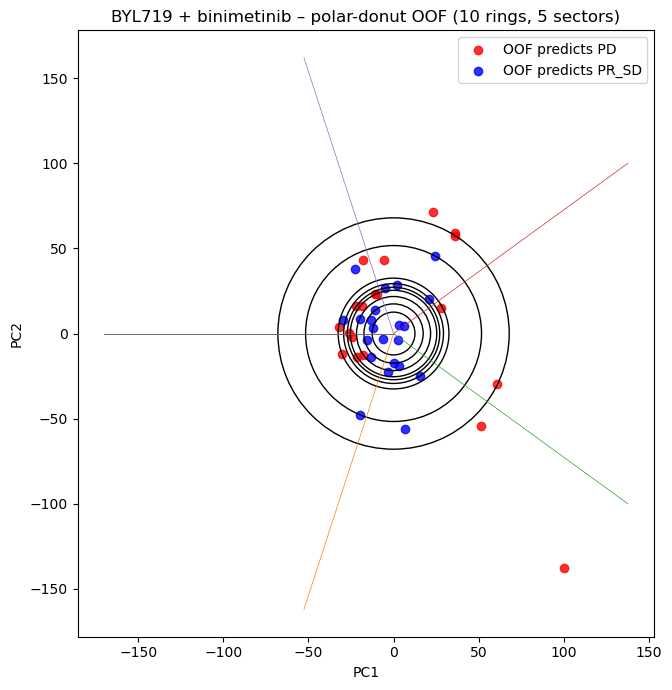

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# ================================================================
# CONFIG
# ================================================================
TREATMENT_NAME = "BYL719 + binimetinib"
CSV_PATH = "PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv"  # <-- change if needed

# df_treatment_response schema (you confirmed)
ID_COL_TR    = "ID_std"
TREAT_COL_TR = "Treatment"
RESP_COL_TR  = "Response"

VALID_4 = {"CR","PR","SD","PD"}
BINARY_LABELS = ["PD", "PR_SD"]

label2color = {"PD": "red", "PR_SD": "blue"}

# ================================================================
# 1) LOAD PCA + BUILD patient-id from 'label'
# ================================================================
df_plot = pd.read_csv(CSV_PATH)
df_plot.columns = df_plot.columns.astype(str).str.strip()

if "label" not in df_plot.columns:
    raise ValueError("Expected 'label' column in PCA CSV (this is your patient ID).")

df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

# need PC1/PC2 for polar donut
if "PC1" not in df_plot.columns or "PC2" not in df_plot.columns:
    raise ValueError("Polar-donut needs PC1 and PC2 in df_plot.")

# ================================================================
# 2) MERGE true responses from df_treatment_response filtered to treatment
# ================================================================
if "df_treatment_response" not in globals():
    raise RuntimeError("df_treatment_response not found in memory.")

dtr = df_treatment_response.copy()
dtr.columns = dtr.columns.astype(str).str.strip()

dtr["patient-id"] = (
    dtr[ID_COL_TR].astype(str).str.strip()
       .str.replace(r"^X-","", regex=True)
       .radd("X-")
)

# filter to treatment (case-insensitive exact match)
mask_treat = dtr[TREAT_COL_TR].astype(str).str.strip().str.casefold() == str(TREATMENT_NAME).strip().casefold()
dtr_t = dtr.loc[mask_treat, ["patient-id", RESP_COL_TR]].copy()

dtr_t["ResponseLegend"] = dtr_t[RESP_COL_TR].astype("string").str.strip().str.upper()
dtr_t = dtr_t[["patient-id", "ResponseLegend"]]

# if duplicates per patient, keep first non-empty (deterministic)
if dtr_t["patient-id"].duplicated().any():
    dtr_t = (dtr_t.sort_values("patient-id")
                  .groupby("patient-id", as_index=False)["ResponseLegend"]
                  .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), pd.NA)))

# left join: keep PCA rows
df_plot = df_plot.merge(dtr_t, on="patient-id", how="left")

# enforce valid labels else NA
df_plot["ResponseLegend"] = df_plot["ResponseLegend"].astype("string").str.strip().str.upper()
df_plot.loc[~df_plot["ResponseLegend"].isin(list(VALID_4)), "ResponseLegend"] = "NA"

print("\nResponseLegend counts (after merge):")
print(df_plot["ResponseLegend"].value_counts(dropna=False))

# keep only labeled
df_lab = df_plot[df_plot["ResponseLegend"].isin(list(VALID_4))].copy()

# ================================================================
# 3) BINARY LABEL: PD vs PR/SD/CR
# ================================================================
def map_to_binary(resp):
    return "PD" if resp == "PD" else "PR_SD"

df_lab["BinaryLabel"] = df_lab["ResponseLegend"].apply(map_to_binary)

pc1_vals = df_lab["PC1"].to_numpy()
pc2_vals = df_lab["PC2"].to_numpy()
y_bin    = df_lab["BinaryLabel"].astype(str).to_numpy()

print("\nBinary label counts:")
print(pd.Series(y_bin).value_counts())

# ================================================================
# 4) POLAR-DONUT model
# ================================================================
def fit_polar_donut(pc1, pc2, y, n_radial=3, n_angular=6):
    pc1 = np.asarray(pc1); pc2 = np.asarray(pc2); y = np.asarray(y)
    r = np.sqrt(pc1**2 + pc2**2)
    theta = np.arctan2(pc2, pc1)  # -pi..pi

    # radial bounds = quantiles
    if n_radial > 1:
        r_bounds = np.quantile(r, np.linspace(0, 1, n_radial + 1)[1:-1])
    else:
        r_bounds = np.array([])

    # angular bounds uniform
    theta_bounds = np.linspace(-np.pi, np.pi, n_angular + 1)[1:-1]

    r_idx = np.digitize(r, r_bounds, right=False)
    t_idx = np.digitize(theta, theta_bounds, right=False)

    sector_labels = np.empty((n_radial, n_angular), dtype=object)
    global_majority = pd.Series(y).mode()[0]

    for i in range(n_radial):
        for j in range(n_angular):
            mask = (r_idx == i) & (t_idx == j)
            if mask.sum() == 0:
                sector_labels[i, j] = global_majority
            else:
                sector_labels[i, j] = pd.Series(y[mask]).mode()[0]

    return r_bounds, theta_bounds, sector_labels

def polar_donut_predict(pc1, pc2, r_bounds, theta_bounds, sector_labels):
    pc1 = np.asarray(pc1); pc2 = np.asarray(pc2)
    r = np.sqrt(pc1**2 + pc2**2)
    theta = np.arctan2(pc2, pc1)
    r_idx = np.digitize(r, r_bounds, right=False)
    t_idx = np.digitize(theta, theta_bounds, right=False)
    return np.array([sector_labels[i, j] for i, j in zip(r_idx, t_idx)], dtype=object)

# ================================================================
# 5) OOF CV evaluation (proper)
# ================================================================
n_radial  = 10
n_angular = 5

counts_bin = pd.Series(y_bin).value_counts()
min_class = int(counts_bin.min())

X_dummy = np.column_stack([pc1_vals, pc2_vals])  # for splitting only

if min_class >= 2 and len(np.unique(y_bin)) > 1:
    splitter = StratifiedKFold(n_splits=min(5, min_class), shuffle=True, random_state=42)
    splits = list(splitter.split(X_dummy, y_bin))
else:
    splitter = KFold(n_splits=min(5, len(y_bin)), shuffle=True, random_state=42)
    splits = list(splitter.split(X_dummy))

y_oof = np.empty_like(y_bin, dtype=object)

for tr, te in splits:
    r_b, th_b, sec = fit_polar_donut(pc1_vals[tr], pc2_vals[tr], y_bin[tr],
                                     n_radial=n_radial, n_angular=n_angular)
    y_oof[te] = polar_donut_predict(pc1_vals[te], pc2_vals[te], r_b, th_b, sec)

acc = accuracy_score(y_bin, y_oof)
bal = balanced_accuracy_score(y_bin, y_oof)

print(f"\nPolar-donut OOF – accuracy: {acc:.3f} ({acc*100:.1f}%)")
print(f"Polar-donut OOF – balanced accuracy: {bal:.3f}")

cm = confusion_matrix(y_bin, y_oof, labels=BINARY_LABELS)
per_class_total = pd.Series(y_bin).value_counts().reindex(BINARY_LABELS, fill_value=0)
per_class_correct = pd.Series(np.diag(cm), index=BINARY_LABELS, name="correct")

per_class_report = pd.DataFrame({"total": per_class_total, "correct": per_class_correct})
per_class_report["accuracy_%"] = (per_class_report["correct"] / per_class_report["total"] * 100).round(1)

print("\nPer-class correct predictions (polar-donut OOF):")
print(per_class_report)

print("\nClassification report (polar-donut OOF):")
print(classification_report(y_bin, y_oof, digits=3))

# ================================================================
# 6) PLOT: PC1 vs PC2 colored by OOF predictions + LAST-FIT grid for visualization
# ================================================================
# Fit once on ALL data just to draw the grid (NOT for evaluation)
r_bounds_all, theta_bounds_all, sector_labels_all = fit_polar_donut(
    pc1_vals, pc2_vals, y_bin, n_radial=n_radial, n_angular=n_angular
)

r_all = np.sqrt(pc1_vals**2 + pc2_vals**2)

plt.figure(figsize=(7, 7))
for lab in BINARY_LABELS:
    mask = (y_oof == lab)
    plt.scatter(pc1_vals[mask], pc2_vals[mask],
                c=label2color[lab],
                label=f"OOF predicts {lab}",
                alpha=0.8)

ax = plt.gca()

# radial circles
for r_b in r_bounds_all:
    ax.add_patch(plt.Circle((0, 0), r_b, fill=False))

# angular spokes
for th in np.concatenate(([-np.pi], theta_bounds_all, [np.pi])):
    ax.plot([0, np.cos(th) * r_all.max()],
            [0, np.sin(th) * r_all.max()],
            linewidth=0.5)

ax.set_aspect("equal", "box")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"{TREATMENT_NAME} – polar-donut OOF ({n_radial} rings, {n_angular} sectors)")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
### one code for all of them

In [68]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ================================================================
# FILES TO SAVE (append across treatments)
# ================================================================
POLAR_MASTER_PATH = "POLAR_all_treatments_predictions.csv"   # optional per-patient
POLAR_PER_CLASS_PATH = "POLAR_per_class_results.csv"         # <-- for your bar chart


# ================================================================
# 1) BUILD ResponseLegend map for a treatment from df_treatment_response
# ================================================================
def build_response_map_for_treatment(df_treatment_response, treatment_name,
                                     id_col="ID_std", treat_col="Treatment", resp_col="Response"):
    """
    Returns df with columns: ['patient-id','ResponseLegend'] for ONLY the selected treatment.
    IDs standardized to X-####.
    If duplicates exist per patient: keep first non-empty deterministically.
    """
    dtr = df_treatment_response.copy()
    dtr.columns = dtr.columns.astype(str).str.strip()

    need = {id_col, treat_col, resp_col}
    if not need.issubset(set(dtr.columns)):
        raise ValueError(f"df_treatment_response missing columns. Need {need}, have {set(dtr.columns)}")

    dtr["patient-id"] = (
        dtr[id_col].astype(str).str.strip()
           .str.replace(r"^X-", "", regex=True)
           .radd("X-")
    )

    # exact match, case-insensitive
    tser = dtr[treat_col].astype(str).str.strip().str.casefold()
    target = str(treatment_name).strip().casefold()
    dtr_t = dtr[tser == target].copy()

    dtr_t["ResponseLegend"] = dtr_t[resp_col].astype("string").str.strip().str.upper()
    valid = {"CR", "PR", "SD", "PD"}
    dtr_t.loc[~dtr_t["ResponseLegend"].isin(list(valid)), "ResponseLegend"] = pd.NA

    dtr_t = dtr_t[["patient-id", "ResponseLegend"]].copy()

    # deduplicate: first non-empty else NA
    if dtr_t["patient-id"].duplicated().any():
        dtr_t = (dtr_t.sort_values("patient-id")
                      .groupby("patient-id", as_index=False)["ResponseLegend"]
                      .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), pd.NA)))
    return dtr_t


# ================================================================
# 2) POLAR-DONUT fit/predict
# ================================================================
def fit_polar_donut(pc1, pc2, y, n_radial=3, n_angular=6):
    pc1 = np.asarray(pc1)
    pc2 = np.asarray(pc2)
    y   = np.asarray(y)

    r = np.sqrt(pc1**2 + pc2**2)
    theta = np.arctan2(pc2, pc1)  # -pi..pi

    # radial bounds by quantiles
    if n_radial > 1:
        r_bounds = np.quantile(r, np.linspace(0, 1, n_radial + 1)[1:-1])
    else:
        r_bounds = np.array([])

    # angular bounds evenly spaced
    theta_bounds = np.linspace(-np.pi, np.pi, n_angular + 1)[1:-1]

    r_idx = np.digitize(r, r_bounds, right=False)          # 0..n_radial-1
    t_idx = np.digitize(theta, theta_bounds, right=False)  # 0..n_angular-1

    sector_labels = np.empty((n_radial, n_angular), dtype=object)
    global_majority = pd.Series(y).mode()[0]

    for i in range(n_radial):
        for j in range(n_angular):
            mask = (r_idx == i) & (t_idx == j)
            if mask.sum() == 0:
                majority = global_majority
            else:
                majority = pd.Series(y[mask]).mode()[0]
            sector_labels[i, j] = majority

    return r_bounds, theta_bounds, sector_labels


def polar_donut_predict(pc1, pc2, r_bounds, theta_bounds, sector_labels):
    pc1 = np.asarray(pc1)
    pc2 = np.asarray(pc2)

    r = np.sqrt(pc1**2 + pc2**2)
    theta = np.arctan2(pc2, pc1)

    r_idx = np.digitize(r, r_bounds, right=False)
    t_idx = np.digitize(theta, theta_bounds, right=False)

    y_pred = []
    for i, j in zip(r_idx, t_idx):
        y_pred.append(sector_labels[i, j])
    return np.array(y_pred, dtype=object)


# ================================================================
# 3) RUN ONE TREATMENT (ONLY CHANGE csv_path + treatment_name)
# ================================================================
def run_polar_treatment(csv_path, treatment_name,
                        n_radial=3, n_angular=6,
                        master_path=POLAR_MASTER_PATH,
                        per_class_path=POLAR_PER_CLASS_PATH):
    print("\n" + "="*80)
    print("POLAR-DONUT TREATMENT:", treatment_name)
    print("CSV:", csv_path)
    print(f"n_radial={n_radial}, n_angular={n_angular}")
    print("="*80)

    if "df_treatment_response" not in globals():
        raise RuntimeError("df_treatment_response not found. Load/create it first.")

    # ---- Load PCA CSV
    df_plot = pd.read_csv(csv_path)
    df_plot.columns = df_plot.columns.astype(str).str.strip()

    # your PCA IDs are in "label"
    if "label" not in df_plot.columns:
        raise ValueError(f"Expected 'label' column (patient IDs). Found: {df_plot.columns.tolist()}")

    df_plot["patient-id"] = df_plot["label"].astype(str).str.strip()

    # ---- merge treatment-specific true labels
    resp_map = build_response_map_for_treatment(df_treatment_response, treatment_name)
    before = len(df_plot)
    df_plot = df_plot.merge(resp_map, on="patient-id", how="left")
    after = len(df_plot)
    if after != before:
        raise RuntimeError(f"Row count changed after merge! before={before}, after={after}")

    # missing stays NA
    df_plot["ResponseLegend"] = df_plot["ResponseLegend"].astype("string").fillna("NA")

    # ---- keep only labeled pool
    valid = {"CR", "PR", "SD", "PD"}
    df_lab = df_plot[df_plot["ResponseLegend"].isin(list(valid))].copy()

    if df_lab.empty:
        raise ValueError(f"No labeled samples found for treatment={treatment_name}")

    # ---- needs PC1 + PC2
    for c in ["PC1", "PC2"]:
        if c not in df_lab.columns:
            raise ValueError(f"Missing {c} in PCA CSV. Found columns: {df_lab.columns.tolist()}")

    # ---- binary mapping PD vs PR/SD/CR
    def map_to_binary(resp):
        return "PD" if resp == "PD" else "PR_SD"

    df_lab["BinaryLabel"] = df_lab["ResponseLegend"].apply(map_to_binary)

    y_true = df_lab["BinaryLabel"].to_numpy()
    pc1 = df_lab["PC1"].to_numpy()
    pc2 = df_lab["PC2"].to_numpy()

    print("Samples (labeled only):", len(df_lab))
    print("Class counts:\n", pd.Series(y_true).value_counts())

    # ---- fit donut on all labeled data 
    r_bounds, theta_bounds, sector_labels = fit_polar_donut(
        pc1, pc2, y_true, n_radial=n_radial, n_angular=n_angular
    )

    y_pred = polar_donut_predict(pc1, pc2, r_bounds, theta_bounds, sector_labels)

    # ---- metrics
    labels = ["PD", "PR_SD"]
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    per_total = pd.Series(y_true).value_counts().reindex(labels, fill_value=0)
    per_correct = pd.Series(np.diag(cm), index=labels, name="correct")

    per_class = pd.DataFrame({"total": per_total, "correct": per_correct})
    per_class["accuracy_%"] = (per_class["correct"] / per_class["total"] * 100).round(1)

    print(f"\nAccuracy: {acc:.3f} ({acc*100:.1f}%)")
    print(f"Balanced Accuracy: {bal:.3f}")
    print("\nPer-class correct predictions:")
    print(per_class)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3))

    # ---- per-patient table 
    results = pd.DataFrame({
        "patient-id": df_lab["patient-id"].astype(str).to_numpy(),
        "actual": y_true,
        "predicted": y_pred,
        "treatment": treatment_name,
        "n_radial": n_radial,
        "n_angular": n_angular,
        "model": "polar_donut",
    })

    # ---- save/append per-patient 
    if master_path is not None:
        if os.path.exists(master_path):
            prev = pd.read_csv(master_path)
            combined = pd.concat([prev, results], ignore_index=True)
        else:
            combined = results
        combined.to_csv(master_path, index=False)
        print(f"\nSaved/appended per-patient predictions to: {master_path}")
        print("Total rows now:", combined.shape[0])

    # ---- save/append per-class (bar charts)
    per_class_to_save = per_class.reset_index().rename(columns={"index": "class"})
    per_class_to_save["treatment"] = treatment_name
    per_class_to_save["n_radial"] = n_radial
    per_class_to_save["n_angular"] = n_angular
    per_class_to_save["model"] = "polar_donut"
    per_class_to_save["accuracy_overall_%"] = round(acc * 100, 1)
    per_class_to_save["balanced_accuracy"] = round(bal, 3)

    per_class_to_save = per_class_to_save[
        ["treatment", "class", "total", "correct", "accuracy_%", "accuracy_overall_%", "balanced_accuracy",
         "n_radial", "n_angular", "model"]
    ]

    if os.path.exists(per_class_path):
        prev_pc = pd.read_csv(per_class_path)
        pc_combined = pd.concat([prev_pc, per_class_to_save], ignore_index=True)
    else:
        pc_combined = per_class_to_save

    pc_combined.to_csv(per_class_path, index=False)
    print(f"\nSaved/appended per-class summary to: {per_class_path}")
    print("Total rows now:", pc_combined.shape[0])

    return results, per_class_to_save


# ================================================================
# EXAMPLE USAGE (only change these two lines)
# ================================================================
# results, per_class_row = run_polar_treatment(
#     csv_path="PCA_batchcorrect_51plus16_BYL719_ENCORAFENIB_colored.csv",
#     treatment_name="BYL719 + encorafenib",
#     n_radial=3,
#     n_angular=6
# )

In [69]:
# 7) Binimetinib
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BINIMETINIB_colored.csv",
    treatment_name="Binimetinib",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: Binimetinib
CSV: PCA_batchcorrect_51plus16_BINIMETINIB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 41
Class counts:
 PD       33
PR_SD     8
Name: count, dtype: int64

Accuracy: 0.902 (90.2%)
Balanced Accuracy: 0.750

Per-class correct predictions:
       total  correct  accuracy_%
PD        33       33       100.0
PR_SD      8        4        50.0

Classification report:
              precision    recall  f1-score   support

          PD      0.892     1.000     0.943        33
       PR_SD      1.000     0.500     0.667         8

    accuracy                          0.902        41
   macro avg      0.946     0.750     0.805        41
weighted avg      0.913     0.902     0.889        41


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 4915

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 320


In [70]:
#5FU
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_5FU_colored.csv",
    treatment_name="5FU",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: 5FU
CSV: PCA_batchcorrect_51plus16_5FU_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 41
Class counts:
 PD       36
PR_SD     5
Name: count, dtype: int64

Accuracy: 0.951 (95.1%)
Balanced Accuracy: 0.800

Per-class correct predictions:
       total  correct  accuracy_%
PD        36       36       100.0
PR_SD      5        3        60.0

Classification report:
              precision    recall  f1-score   support

          PD      0.947     1.000     0.973        36
       PR_SD      1.000     0.600     0.750         5

    accuracy                          0.951        41
   macro avg      0.974     0.800     0.861        41
weighted avg      0.954     0.951     0.946        41


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 4956

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 322


In [71]:
# 1) BYL719
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BYL719_colored.csv",
    treatment_name="BYL719",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BYL719
CSV: PCA_batchcorrect_51plus16_BYL719_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 41
Class counts:
 PD       38
PR_SD     3
Name: count, dtype: int64

Accuracy: 0.927 (92.7%)
Balanced Accuracy: 0.500

Per-class correct predictions:
       total  correct  accuracy_%
PD        38       38       100.0
PR_SD      3        0         0.0

Classification report:
              precision    recall  f1-score   support

          PD      0.927     1.000     0.962        38
       PR_SD      0.000     0.000     0.000         3

    accuracy                          0.927        41
   macro avg      0.463     0.500     0.481        41
weighted avg      0.859     0.927     0.892        41


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 4997

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 324


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [72]:
# 2) BYL719 + Binimetinib
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv",
    treatment_name="BYL719 + Binimetinib",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BYL719 + Binimetinib
CSV: PCA_batchcorrect_51plus16_BYL719_BINIMETINIB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 41
Class counts:
 PR_SD    21
PD       20
Name: count, dtype: int64

Accuracy: 0.780 (78.0%)
Balanced Accuracy: 0.786

Per-class correct predictions:
       total  correct  accuracy_%
PD        20       20       100.0
PR_SD     21       12        57.1

Classification report:
              precision    recall  f1-score   support

          PD      0.690     1.000     0.816        20
       PR_SD      1.000     0.571     0.727        21

    accuracy                          0.780        41
   macro avg      0.845     0.786     0.772        41
weighted avg      0.849     0.780     0.771        41


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5038

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 326


In [73]:
# 3) BYL719 + Cetuximab
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BYL719_CETUXIMAB_colored.csv",
    treatment_name="BYL719 + Cetuximab",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BYL719 + Cetuximab
CSV: PCA_batchcorrect_51plus16_BYL719_CETUXIMAB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD       33
PR_SD     6
Name: count, dtype: int64

Accuracy: 0.923 (92.3%)
Balanced Accuracy: 0.750

Per-class correct predictions:
       total  correct  accuracy_%
PD        33       33       100.0
PR_SD      6        3        50.0

Classification report:
              precision    recall  f1-score   support

          PD      0.917     1.000     0.957        33
       PR_SD      1.000     0.500     0.667         6

    accuracy                          0.923        39
   macro avg      0.958     0.750     0.812        39
weighted avg      0.929     0.923     0.912        39


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5077

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 328


In [74]:
# 4) BYL719 + Cetuximab + Encorafenib
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BYL719_CETUXIMAB_ENCORAFENIB_colored.csv",
    treatment_name="BYL719 + Cetuximab + Encorafenib",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BYL719 + Cetuximab + Encorafenib
CSV: PCA_batchcorrect_51plus16_BYL719_CETUXIMAB_ENCORAFENIB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 40
Class counts:
 PD       31
PR_SD     9
Name: count, dtype: int64

Accuracy: 0.950 (95.0%)
Balanced Accuracy: 0.889

Per-class correct predictions:
       total  correct  accuracy_%
PD        31       31       100.0
PR_SD      9        7        77.8

Classification report:
              precision    recall  f1-score   support

          PD      0.939     1.000     0.969        31
       PR_SD      1.000     0.778     0.875         9

    accuracy                          0.950        40
   macro avg      0.970     0.889     0.922        40
weighted avg      0.953     0.950     0.948        40




Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5117

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 330


In [75]:
## 5) BYL719 + LJM716
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BYL719_LJM716_colored.csv",
    treatment_name="BYL719 + LJM716",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BYL719 + LJM716
CSV: PCA_batchcorrect_51plus16_BYL719_LJM716_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD       32
PR_SD     7
Name: count, dtype: int64

Accuracy: 0.897 (89.7%)
Balanced Accuracy: 0.714

Per-class correct predictions:
       total  correct  accuracy_%
PD        32       32       100.0
PR_SD      7        3        42.9

Classification report:
              precision    recall  f1-score   support

          PD      0.889     1.000     0.941        32
       PR_SD      1.000     0.429     0.600         7

    accuracy                          0.897        39
   macro avg      0.944     0.714     0.771        39
weighted avg      0.909     0.897     0.880        39


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5156

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 332


In [76]:
# 6) BYL719 + Encorafenib
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BYL719_ENCORAFENIB_colored.csv",
    treatment_name="BYL719 + Encorafenib",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BYL719 + Encorafenib
CSV: PCA_batchcorrect_51plus16_BYL719_ENCORAFENIB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD       33
PR_SD     6
Name: count, dtype: int64

Accuracy: 0.949 (94.9%)
Balanced Accuracy: 0.833

Per-class correct predictions:
       total  correct  accuracy_%
PD        33       33       100.0
PR_SD      6        4        66.7

Classification report:
              precision    recall  f1-score   support

          PD      0.943     1.000     0.971        33
       PR_SD      1.000     0.667     0.800         6

    accuracy                          0.949        39
   macro avg      0.971     0.833     0.885        39
weighted avg      0.952     0.949     0.944        39


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5195

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 334


In [77]:
# 8) BKM120
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BKM120_colored.csv",
    treatment_name="BKM120",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BKM120
CSV: PCA_batchcorrect_51plus16_BKM120_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD       36
PR_SD     3
Name: count, dtype: int64

Accuracy: 0.974 (97.4%)
Balanced Accuracy: 0.833

Per-class correct predictions:
       total  correct  accuracy_%
PD        36       36       100.0
PR_SD      3        2        66.7

Classification report:
              precision    recall  f1-score   support

          PD      0.973     1.000     0.986        36
       PR_SD      1.000     0.667     0.800         3

    accuracy                          0.974        39
   macro avg      0.986     0.833     0.893        39
weighted avg      0.975     0.974     0.972        39


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5234

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 336


In [78]:
# 9) BKM120 + LJC049
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_BKM120_LJC049_colored.csv",
    treatment_name="BKM120 + LJC049",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: BKM120 + LJC049
CSV: PCA_batchcorrect_51plus16_BKM120_LJC049_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD       32
PR_SD     7
Name: count, dtype: int64

Accuracy: 0.897 (89.7%)
Balanced Accuracy: 0.714

Per-class correct predictions:
       total  correct  accuracy_%
PD        32       32       100.0
PR_SD      7        3        42.9

Classification report:
              precision    recall  f1-score   support

          PD      0.889     1.000     0.941        32
       PR_SD      1.000     0.429     0.600         7

    accuracy                          0.897        39
   macro avg      0.944     0.714     0.771        39
weighted avg      0.909     0.897     0.880        39


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5273

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 338


In [79]:
# 10) CLR457
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_CLR457_colored.csv",
    treatment_name="CLR457",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: CLR457
CSV: PCA_batchcorrect_51plus16_CLR457_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 40
Class counts:
 PD       34
PR_SD     6
Name: count, dtype: int64

Accuracy: 0.975 (97.5%)
Balanced Accuracy: 0.917

Per-class correct predictions:
       total  correct  accuracy_%
PD        34       34       100.0
PR_SD      6        5        83.3

Classification report:
              precision    recall  f1-score   support

          PD      0.971     1.000     0.986        34
       PR_SD      1.000     0.833     0.909         6

    accuracy                          0.975        40
   macro avg      0.986     0.917     0.947        40
weighted avg      0.976     0.975     0.974        40


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5313

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 340


In [80]:
# 11) CKX620
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_CKX620_colored.csv",
    treatment_name="CKX620",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: CKX620
CSV: PCA_batchcorrect_51plus16_CKX620_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD       31
PR_SD     8
Name: count, dtype: int64

Accuracy: 0.897 (89.7%)
Balanced Accuracy: 0.750

Per-class correct predictions:
       total  correct  accuracy_%
PD        31       31       100.0
PR_SD      8        4        50.0

Classification report:
              precision    recall  f1-score   support

          PD      0.886     1.000     0.939        31
       PR_SD      1.000     0.500     0.667         8

    accuracy                          0.897        39
   macro avg      0.943     0.750     0.803        39
weighted avg      0.909     0.897     0.883        39


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5352

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 342


In [81]:
# 12) CGM097
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_CGM097_colored.csv",
    treatment_name="CGM097",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: CGM097
CSV: PCA_batchcorrect_51plus16_CGM097_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 37
Class counts:
 PD    37
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD        37       37       100.0
PR_SD      0        0         NaN

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000        37

    accuracy                          1.000        37
   macro avg      1.000     1.000     1.000        37
weighted avg      1.000     1.000     1.000        37


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5389

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 344


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [82]:
# 13) HDM201
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_HDM201_colored.csv",
    treatment_name="HDM201",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: HDM201
CSV: PCA_batchcorrect_51plus16_HDM201_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD    39
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD        39       39       100.0
PR_SD      0        0         NaN

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000        39

    accuracy                          1.000        39
   macro avg      1.000     1.000     1.000        39
weighted avg      1.000     1.000     1.000        39


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5428

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 346


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [83]:
# 14) LEE011
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_LEE011_colored.csv",
    treatment_name="LEE011",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: LEE011
CSV: PCA_batchcorrect_51plus16_LEE011_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 41
Class counts:
 PD       37
PR_SD     4
Name: count, dtype: int64

Accuracy: 0.976 (97.6%)
Balanced Accuracy: 0.875

Per-class correct predictions:
       total  correct  accuracy_%
PD        37       37       100.0
PR_SD      4        3        75.0

Classification report:
              precision    recall  f1-score   support

          PD      0.974     1.000     0.987        37
       PR_SD      1.000     0.750     0.857         4

    accuracy                          0.976        41
   macro avg      0.987     0.875     0.922        41
weighted avg      0.976     0.976     0.974        41


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5469

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 348


In [84]:
# 15) LFW527 + Binimetinib
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_LFW527_BINIMETINIB_colored.csv",
    treatment_name="LFW527 + Binimetinib",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: LFW527 + Binimetinib
CSV: PCA_batchcorrect_51plus16_LFW527_BINIMETINIB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 31
Class counts:
 PD       27
PR_SD     4
Name: count, dtype: int64

Accuracy: 0.968 (96.8%)
Balanced Accuracy: 0.981

Per-class correct predictions:
       total  correct  accuracy_%
PD        27       26        96.3
PR_SD      4        4       100.0

Classification report:


              precision    recall  f1-score   support

          PD      1.000     0.963     0.981        27
       PR_SD      0.800     1.000     0.889         4

    accuracy                          0.968        31
   macro avg      0.900     0.981     0.935        31
weighted avg      0.974     0.968     0.969        31


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5500

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 350


In [85]:
# 16) LKA136
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_LKA136_colored.csv",
    treatment_name="LKA136",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: LKA136
CSV: PCA_batchcorrect_51plus16_LKA136_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 39
Class counts:
 PD       38
PR_SD     1
Name: count, dtype: int64

Accuracy: 0.974 (97.4%)
Balanced Accuracy: 0.500

Per-class correct predictions:
       total  correct  accuracy_%
PD        38       38       100.0
PR_SD      1        0         0.0

Classification report:
              precision    recall  f1-score   support

          PD      0.974     1.000     0.987        38
       PR_SD      0.000     0.000     0.000         1

    accuracy                          0.974        39
   macro avg      0.487     0.500     0.494        39
weighted avg      0.949     0.974     0.962        39



/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5539

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 352


In [86]:
# 17) LJC049
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_LJC049_colored.csv",
    treatment_name="LJC049",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: LJC049
CSV: PCA_batchcorrect_51plus16_LJC049_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 40
Class counts:
 PD    40
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD        40       40       100.0
PR_SD      0        0         NaN

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000        40

    accuracy                          1.000        40
   macro avg      1.000     1.000     1.000        40
weighted avg      1.000     1.000     1.000        40


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5579

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 354


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [87]:
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_CETUXIMAB_ENCORAFENIB_colored.csv",
    treatment_name="cetuximab + encorafenib",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: cetuximab + encorafenib
CSV: PCA_batchcorrect_51plus16_CETUXIMAB_ENCORAFENIB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 40
Class counts:
 PD       32
PR_SD     8
Name: count, dtype: int64

Accuracy: 0.900 (90.0%)
Balanced Accuracy: 0.750

Per-class correct predictions:
       total  correct  accuracy_%
PD        32       32       100.0
PR_SD      8        4        50.0

Classification report:
              precision    recall  f1-score   support

          PD      0.889     1.000     0.941        32
       PR_SD      1.000     0.500     0.667         8

    accuracy                          0.900        40
   macro avg      0.944     0.750     0.804        40
weighted avg      0.911     0.900     0.886        40


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5619

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 356


In [88]:
### UKT PAteints 

In [89]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# ================================================================
# FILES TO SAVE (append across treatments)
# ================================================================
POLAR_MASTER_PATH = "POLAR_all_treatments_predictions.csv"   # optional per-patient
POLAR_PER_CLASS_PATH = "POLAR_per_class_results.csv"         # <-- for your bar chart


# ================================================================
# 0) ID NORMALIZATION (match your df_treatment_response pipeline)
# ================================================================
def norm_id(x) -> str:
    s = str(x).strip().upper()
    s = re.sub(r"[._ ]", "-", s)
    s = re.sub(r"-+", "-", s)
    s = re.sub(r"^X-", "", s)
    s = re.sub(r"^RNA", "", s)
    s = re.sub(r"^R-", "", s)
    return s


# ================================================================
# 1) BUILD ResponseLegend map for a treatment from df_treatment_response
#    - Uses ID_std directly
#    - Treatment matching supports:
#        * exact match (default)
#        * regex match when treatment_name starts with "re:"
#          (case-insensitive)
# ================================================================
def build_response_map_for_treatment(df_treatment_response, treatment_name,
                                     id_col="ID_std", treat_col="Treatment", resp_col="Response"):
    """
    Returns df with columns: ['ID_std','ResponseLegend'] for ONLY the selected treatment rows.
    Uses ID_std directly (assumes df_treatment_response already has normalized IDs).
    """
    dtr = df_treatment_response.copy()
    dtr.columns = dtr.columns.astype(str).str.strip()

    need = {id_col, treat_col, resp_col}
    if not need.issubset(set(dtr.columns)):
        raise ValueError(f"df_treatment_response missing columns. Need {need}, have {set(dtr.columns)}")

    # normalize IDs again (safe)
    dtr[id_col] = dtr[id_col].map(norm_id)

    # ---------------- TREATMENT MATCHING (ONLY PART YOU WANTED CHANGED) ----------------
    treat_series = dtr[treat_col].astype(str).str.strip()
    target_raw = str(treatment_name).strip()

    if target_raw.startswith("re:"):
        # regex match (case-insensitive)
        pattern = target_raw[3:]
        dtr_t = dtr[treat_series.str.contains(pattern, case=False, na=False, regex=True)].copy()
    else:
        # exact match (case-insensitive)
        dtr_t = dtr[treat_series.str.casefold() == target_raw.casefold()].copy()
    # -------------------------------------------------------------------------------

    # ---- ResponseLegend: keep only CR/PR/SD/PD
    dtr_t["ResponseLegend"] = dtr_t[resp_col].astype("string").str.strip().str.upper()
    valid = {"CR", "PR", "SD", "PD"}
    dtr_t.loc[~dtr_t["ResponseLegend"].isin(list(valid)), "ResponseLegend"] = pd.NA

    dtr_t = dtr_t[[id_col, "ResponseLegend"]].copy()

    # ---- deduplicate per patient: first non-empty else NA
    if dtr_t[id_col].duplicated().any():
        dtr_t = (dtr_t.sort_values(id_col)
                      .groupby(id_col, as_index=False)["ResponseLegend"]
                      .agg(lambda s: next((v for v in s if pd.notna(v) and str(v).strip() != ""), pd.NA)))
    return dtr_t


# ================================================================
# 2) POLAR-DONUT fit/predict
# ================================================================
def fit_polar_donut(pc1, pc2, y, n_radial=3, n_angular=6):
    pc1 = np.asarray(pc1)
    pc2 = np.asarray(pc2)
    y   = np.asarray(y)

    r = np.sqrt(pc1**2 + pc2**2)
    theta = np.arctan2(pc2, pc1)  # -pi..pi

    # radial bounds by quantiles
    if n_radial > 1:
        r_bounds = np.quantile(r, np.linspace(0, 1, n_radial + 1)[1:-1])
    else:
        r_bounds = np.array([])

    # angular bounds evenly spaced
    theta_bounds = np.linspace(-np.pi, np.pi, n_angular + 1)[1:-1]

    r_idx = np.digitize(r, r_bounds, right=False)          # 0..n_radial-1
    t_idx = np.digitize(theta, theta_bounds, right=False)  # 0..n_angular-1

    sector_labels = np.empty((n_radial, n_angular), dtype=object)
    global_majority = pd.Series(y).mode()[0]

    for i in range(n_radial):
        for j in range(n_angular):
            mask = (r_idx == i) & (t_idx == j)
            if mask.sum() == 0:
                majority = global_majority
            else:
                majority = pd.Series(y[mask]).mode()[0]
            sector_labels[i, j] = majority

    return r_bounds, theta_bounds, sector_labels


def polar_donut_predict(pc1, pc2, r_bounds, theta_bounds, sector_labels):
    pc1 = np.asarray(pc1)
    pc2 = np.asarray(pc2)

    r = np.sqrt(pc1**2 + pc2**2)
    theta = np.arctan2(pc2, pc1)

    r_idx = np.digitize(r, r_bounds, right=False)
    t_idx = np.digitize(theta, theta_bounds, right=False)

    y_pred = []
    for i, j in zip(r_idx, t_idx):
        y_pred.append(sector_labels[i, j])
    return np.array(y_pred, dtype=object)


# ================================================================
# 3) RUN ONE TREATMENT
#    - Loads PCA CSV
#    - Builds PCA ID_std using norm_id()
#    - Merges responses by ID_std
# ================================================================
def run_polar_treatment(csv_path, treatment_name,
                        n_radial=3, n_angular=6,
                        master_path=POLAR_MASTER_PATH,
                        per_class_path=POLAR_PER_CLASS_PATH):

    print("\n" + "="*80)
    print("POLAR-DONUT TREATMENT:", treatment_name)
    print("CSV:", csv_path)
    print(f"n_radial={n_radial}, n_angular={n_angular}")
    print("="*80)

    if "df_treatment_response" not in globals():
        raise RuntimeError("df_treatment_response not found. Load/create it first.")

    # ---- Load PCA CSV
    df_plot = pd.read_csv(csv_path)
    df_plot.columns = df_plot.columns.astype(str).str.strip()

    # ---- detect PCA ID column
    id_col = None
    for cand in ["label", "sample", "patient-id"]:
        if cand in df_plot.columns:
            id_col = cand
            break
    if id_col is None:
        raise ValueError(
            f"No ID column found. Expected one of label/sample/patient-id. "
            f"Columns: {df_plot.columns.tolist()}"
        )

    df_plot["patient-id"] = df_plot[id_col].astype(str).str.strip()
    df_plot["ID_std"] = df_plot["patient-id"].map(norm_id)

    # ---- merge treatment-specific true labels by ID_std
    resp_map = build_response_map_for_treatment(df_treatment_response, treatment_name)

    before = len(df_plot)
    df_plot = df_plot.merge(resp_map, on="ID_std", how="left")
    after = len(df_plot)
    if after != before:
        raise RuntimeError(f"Row count changed after merge! before={before}, after={after}")

    # ---- keep only labeled pool
    valid = {"CR", "PR", "SD", "PD"}
    df_lab = df_plot[df_plot["ResponseLegend"].isin(list(valid))].copy()

    if df_lab.empty:
        print("\nDEBUG: ResponseLegend counts after merge:")
        print(df_plot["ResponseLegend"].value_counts(dropna=False).head(30))
        print("\nDEBUG: How many rows in resp_map:", len(resp_map))
        print("DEBUG: resp_map ResponseLegend counts:")
        print(resp_map["ResponseLegend"].value_counts(dropna=False))
        raise ValueError(f"No labeled samples found for treatment={treatment_name}")

    # ---- needs PC1 + PC2
    for c in ["PC1", "PC2"]:
        if c not in df_lab.columns:
            raise ValueError(f"Missing {c} in PCA CSV. Found columns: {df_lab.columns.tolist()}")

    # ---- binary mapping PD vs PR/SD/CR
    df_lab["BinaryLabel"] = np.where(df_lab["ResponseLegend"] == "PD", "PD", "PR_SD")

    y_true = df_lab["BinaryLabel"].to_numpy()
    pc1 = df_lab["PC1"].to_numpy()
    pc2 = df_lab["PC2"].to_numpy()

    print("Samples (labeled only):", len(df_lab))
    print("Class counts:\n", pd.Series(y_true).value_counts())

    # ---- fit + predict
    r_bounds, theta_bounds, sector_labels = fit_polar_donut(
        pc1, pc2, y_true, n_radial=n_radial, n_angular=n_angular
    )
    y_pred = polar_donut_predict(pc1, pc2, r_bounds, theta_bounds, sector_labels)

    # ---- metrics
    labels = ["PD", "PR_SD"]
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    per_total = pd.Series(y_true).value_counts().reindex(labels, fill_value=0)
    per_correct = pd.Series(np.diag(cm), index=labels, name="correct")

    per_class = pd.DataFrame({"total": per_total, "correct": per_correct})
    per_class["accuracy_%"] = (per_class["correct"] / per_class["total"] * 100).round(1)

    print(f"\nAccuracy: {acc:.3f} ({acc*100:.1f}%)")
    print(f"Balanced Accuracy: {bal:.3f}")
    print("\nPer-class correct predictions:")
    print(per_class)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3))

    # ---- per-patient output
    results = pd.DataFrame({
        "patient-id": df_lab["patient-id"].astype(str).to_numpy(),
        "ID_std": df_lab["ID_std"].astype(str).to_numpy(),
        "actual": y_true,
        "predicted": y_pred,
        "treatment": treatment_name,
        "n_radial": n_radial,
        "n_angular": n_angular,
        "model": "polar_donut",
    })

    # ---- save/append per-patient
    if master_path is not None:
        if os.path.exists(master_path):
            prev = pd.read_csv(master_path)
            combined = pd.concat([prev, results], ignore_index=True)
        else:
            combined = results
        combined.to_csv(master_path, index=False)
        print(f"\nSaved/appended per-patient predictions to: {master_path}")
        print("Total rows now:", combined.shape[0])

    # ---- save/append per-class
    per_class_to_save = per_class.reset_index().rename(columns={"index": "class"})
    per_class_to_save["treatment"] = treatment_name
    per_class_to_save["n_radial"] = n_radial
    per_class_to_save["n_angular"] = n_angular
    per_class_to_save["model"] = "polar_donut"
    per_class_to_save["accuracy_overall_%"] = round(acc * 100, 1)
    per_class_to_save["balanced_accuracy"] = round(bal, 3)

    per_class_to_save = per_class_to_save[
        ["treatment", "class", "total", "correct", "accuracy_%", "accuracy_overall_%", "balanced_accuracy",
         "n_radial", "n_angular", "model"]
    ]

    if os.path.exists(per_class_path):
        prev_pc = pd.read_csv(per_class_path)
        pc_combined = pd.concat([prev_pc, per_class_to_save], ignore_index=True)
    else:
        pc_combined = per_class_to_save

    pc_combined.to_csv(per_class_path, index=False)
    print(f"\nSaved/appended per-class summary to: {per_class_path}")
    print("Total rows now:", pc_combined.shape[0])

    return results, per_class_to_save


# ================================================================
# EXAMPLE USAGE for YOUR case (FOLFIRI + Avastin)
# Matches BOTH:
#   - "FOLFIRI + Avastin"
#   - "FOFIRI + Avastin"  (typo)
# ================================================================
# csv_path = "PCA_batchcorrect_51plus16_FOLFIRI_AVASTIN_colored.csv"  # <-- use your real filename
# results, per_class_row = run_polar_treatment(
#     csv_path=csv_path,
#     treatment_name=r"re:\bFO?LFIRI\b\s*\+\s*AVASTIN\b",
#     n_radial=5,
#     n_angular=10
# )

In [90]:
# 21) FOLFIRI + Panitumumab
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_FOLFIRI_PANITUMUMAB_colored.csv",
    treatment_name="FOLFIRI + Panitumumab",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: FOLFIRI + Panitumumab
CSV: PCA_batchcorrect_51plus16_FOLFIRI_PANITUMUMAB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 2
Class counts:
 PD       1
PR_SD    1
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD         1        1       100.0
PR_SD      1        1       100.0

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000         1
       PR_SD      1.000     1.000     1.000         1

    accuracy                          1.000         2
   macro avg      1.000     1.000     1.000         2
weighted avg      1.000     1.000     1.000         2


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5621

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 358


In [91]:
# 22) FOLFOX + Avastin
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_FOLFOX_AVASTIN_colored.csv",
    treatment_name="FOLFOX + Avastin",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: FOLFOX + Avastin
CSV: PCA_batchcorrect_51plus16_FOLFOX_AVASTIN_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 4
Class counts:
 PD       3
PR_SD    1
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD         3        3       100.0
PR_SD      1        1       100.0

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000         3
       PR_SD      1.000     1.000     1.000         1

    accuracy                          1.000         4
   macro avg      1.000     1.000     1.000         4
weighted avg      1.000     1.000     1.000         4


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5625

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 360


In [92]:
# 23) FOLFOX + Panitumumab
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_FOLFOX_PANITUMUMAB_colored.csv",
    treatment_name="FOLFOX + Panitumumab",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: FOLFOX + Panitumumab
CSV: PCA_batchcorrect_51plus16_FOLFOX_PANITUMUMAB_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 1
Class counts:
 PD    1
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD         1        1       100.0
PR_SD      0        0         NaN

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000         1

    accuracy                          1.000         1
   macro avg      1.000     1.000     1.000         1
weighted avg      1.000     1.000     1.000         1


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5626

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 362


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [93]:
# XELOX + Avastin
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_XELOX_AVASTIN_colored.csv",
    treatment_name="XELOX + Avastin",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: XELOX + Avastin
CSV: PCA_batchcorrect_51plus16_XELOX_AVASTIN_colored.csv
n_radial=5, n_angular=10


Samples (labeled only): 1
Class counts:
 PD    1
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD         1        1       100.0
PR_SD      0        0         NaN

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000         1

    accuracy                          1.000         1
   macro avg      1.000     1.000     1.000         1
weighted avg      1.000     1.000     1.000         1


Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5627

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 364


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [94]:
# 25) FOLFOX (Exact 16UNI)
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_FOLFOX_EXACT_16UNI_colored.csv",
    treatment_name="FOLFOX",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: FOLFOX
CSV: PCA_batchcorrect_51plus16_FOLFOX_EXACT_16UNI_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 1
Class counts:
 PD    1
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD         1        1       100.0
PR_SD      0        0         NaN

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000         1

    accuracy                          1.000         1
   macro avg      1.000     1.000     1.000         1
weighted avg      1.000     1.000     1.000         1




Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5628

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 366


/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [95]:
# 26) Lonsurf (trifluridine/tipiracil)
results, per_class_row = run_polar_treatment(
    csv_path="PCA_batchcorrect_51plus16_LONSURF_TRIFLURIDINE_TIPIRACIL_colored.csv",
    treatment_name="Lonsurf",
    n_radial=5,
    n_angular=10
)


POLAR-DONUT TREATMENT: Lonsurf
CSV: PCA_batchcorrect_51plus16_LONSURF_TRIFLURIDINE_TIPIRACIL_colored.csv
n_radial=5, n_angular=10
Samples (labeled only): 2
Class counts:
 PD    2
Name: count, dtype: int64

Accuracy: 1.000 (100.0%)
Balanced Accuracy: 1.000

Per-class correct predictions:
       total  correct  accuracy_%
PD         2        2       100.0
PR_SD      0        0         NaN

Classification report:
              precision    recall  f1-score   support

          PD      1.000     1.000     1.000         2

    accuracy                          1.000         2
   macro avg      1.000     1.000     1.000         2
weighted avg      1.000     1.000     1.000         2



/mnt/lustre/groups/nahnsen/nahfo470/.conda/envs/r_deseq2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Saved/appended per-patient predictions to: POLAR_all_treatments_predictions.csv
Total rows now: 5630

Saved/appended per-class summary to: POLAR_per_class_results.csv
Total rows now: 368


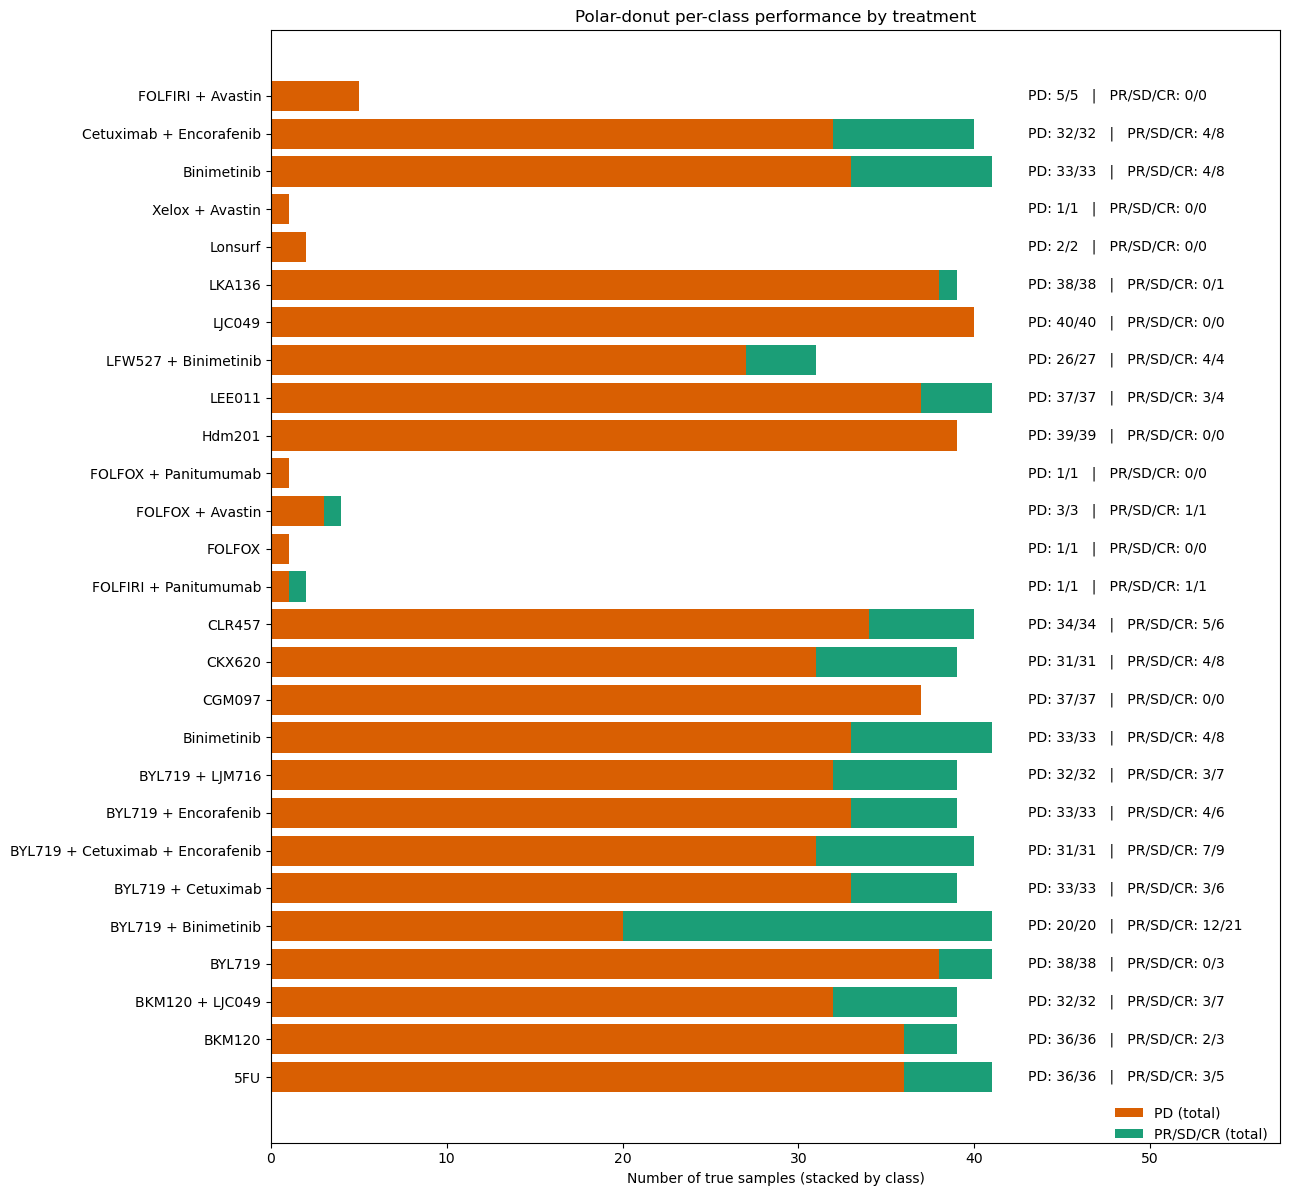

In [96]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PER_CLASS_PATH = "POLAR_per_class_results.csv"
MIN_TOTAL = 10

COLOR_PD = "#d95f02"
COLOR_PRSD = "#1b9e77"

df = pd.read_csv(PER_CLASS_PATH)

df = df[df["class"].isin(["PD", "PR_SD"])].copy()

# keep last run per treatment (2 rows)
df["_row"] = np.arange(len(df))
df = (df.sort_values("_row")
        .groupby("treatment", as_index=False, group_keys=False)
        .tail(2))

tot = df.pivot(index="treatment", columns="class", values="total").fillna(0).astype(int)
cor = df.pivot(index="treatment", columns="class", values="correct").fillna(0).astype(int)

for c in ["PD", "PR_SD"]:
    if c not in tot.columns:
        tot[c] = 0
        cor[c] = 0

plot_df = pd.DataFrame({
    "PD_total": tot["PD"],
    "PRSD_total": tot["PR_SD"],
    "PD_correct": cor["PD"],
    "PRSD_correct": cor["PR_SD"],
})
plot_df["TOTAL"] = plot_df["PD_total"] + plot_df["PRSD_total"]

plot_df = plot_df[plot_df["TOTAL"] > 0]

############################################################

import re
def pretty_treatment_name(s: str) -> str:
    s = str(s).strip()

    # --- 1) HARD MAP known regex patterns to real treatment names ---
    regex_map = {
        r"fo.?lfiri.*avastin": "FOLFIRI + Avastin",
        r"fo.?lfiri.*panitumumab": "FOLFIRI + Panitumumab",
        r"folfox.*avastin": "FOLFOX + Avastin",
        r"folfox.*panitumumab": "FOLFOX + Panitumumab",
        r"byl719.*binimetinib": "BYL719 + Binimetinib",
        r"byl719.*cetuximab.*encorafenib": "BYL719 + Cetuximab + Encorafenib",
    }

    s_low = s.lower()
    for pat, nice in regex_map.items():
        if re.search(pat, s_low):
            return nice

    # --- REMOVE REGEX TOKENS ---
    s = s.replace("\\", "")
    s = re.sub(r"\\b", "", s)        # remove \b
    s = re.sub(r"\\s\*", " ", s)     # replace \s* with space
    s = re.sub(r"\?", "", s)         # remove ?
    s = re.sub(r"\+", " + ", s)      # normalize +
    s = re.sub(r"\s+", " ", s)       # collapse spaces
    s = s.strip()

    # remove regex prefix if present
    if s.lower().startswith("re:"):
        s = s[3:]


    # --- 1) HARD MAP known regex patterns to real treatment names ---
    regex_map = {
        r"fo.?lfiri.*avastin": "FOLFIRI + Avastin",
        r"fo.?lfiri.*panitumumab": "FOLFIRI + Panitumumab",
        r"folfox.*avastin": "FOLFOX + Avastin",
        r"folfox.*panitumumab": "FOLFOX + Panitumumab",
        r"byl719.*binimetinib": "BYL719 + Binimetinib",
        r"byl719.*cetuximab.*encorafenib": "BYL719 + Cetuximab + Encorafenib",
    }
 

    # known acronyms / drugs
    replacements = {
        "5fu": "5FU",
        "folfox": "FOLFOX",
        "folfiri": "FOLFIRI",
        "folfoxiri": "FOLFOXIRI",
        "byl719": "BYL719",
        "bkm120": "BKM120",
        "lee011": "LEE011",
        "ckx620": "CKX620",
        "clr457": "CLR457",
        "cgm097": "CGM097",
        "lka136": "LKA136",
        "ljc049": "LJC049",
        "ljm716": "LJM716",
        "lfw527": "LFW527",
    }

    parts = [p.strip() for p in s.split("+")]
    nice_parts = []

    for p in parts:
        low = p.lower()
        if low in replacements:
            nice_parts.append(replacements[low])
        else:
            # normal drug names → Capitalized
            nice_parts.append(p.capitalize())

    return " + ".join(nice_parts)


############################################################
# --- plot ---
treatments = plot_df.index.tolist()
y = np.arange(len(treatments))

pd_tot = plot_df["PD_total"].to_numpy()
pr_tot = plot_df["PRSD_total"].to_numpy()
pd_cor = plot_df["PD_correct"].to_numpy()
pr_cor = plot_df["PRSD_correct"].to_numpy()

fig_h = max(6, 0.38 * len(treatments) + 1.8)
fig, ax = plt.subplots(figsize=(13, fig_h))

ax.barh(y, pd_tot, color=COLOR_PD, label="PD (total)")
ax.barh(y, pr_tot, left=pd_tot, color=COLOR_PRSD, label="PR/SD/CR (total)")

ax.set_yticks(y)
ax.set_yticklabels([pretty_treatment_name(t) for t in treatments])
ax.set_xlabel("Number of true samples (stacked by class)")
ax.set_title("Polar-donut per-class performance by treatment")

# ---- make space on the right for the label column ----
x_max = (pd_tot + pr_tot).max()
label_x = x_max * 1.05          # where labels start
ax.set_xlim(0, x_max * 1.40)    # room for labels

# ---- write two clean labels per treatment, always readable ----
for i in range(len(treatments)):
    ax.text(label_x, i,
            f"PD: {pd_cor[i]}/{pd_tot[i]}   |   PR/SD/CR: {pr_cor[i]}/{pr_tot[i]}",
            va="center", ha="left", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.9))

ax.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, -0.01),  # move legend slightly down
    frameon=False
)
plt.tight_layout()
plt.show()